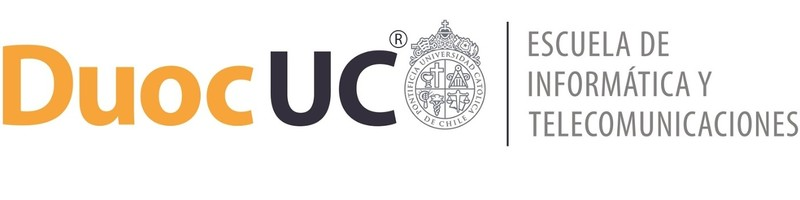


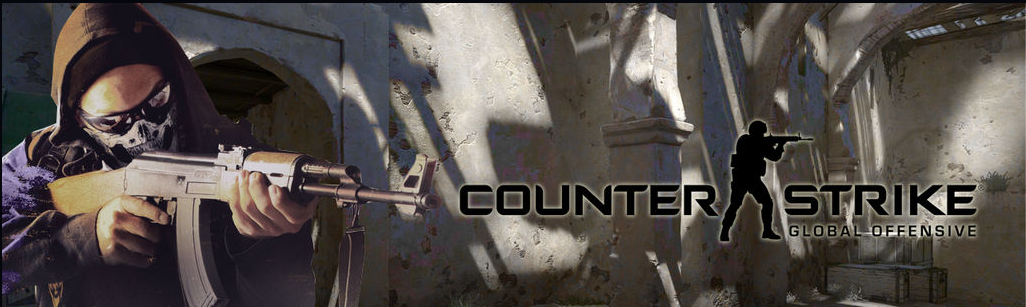


# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Flavio Henriquez
* Jose Parra
* Pedro Campos
* Fabian Molina

Docente: Marco Japke

Sección: MLY0100

Asignatura: Fundamentos de Machine learning


**Caso Fundamentos de Machine Learning**


## Fase 1: Business Understanding

### 1.1 Contexto del caso

Counter-Strike: Global Offensive es un juego competitivo por rondas en el que las decisiones economicas condicionan gran parte del resultado de cada ronda. Cada equipo inicia con un presupuesto limitado y debe decidir, al comienzo de cada ronda, si conviene comprar armamento y equipamiento completo, forzar una compra parcial o ahorrar para una ronda futura. Esta decision depende del ciclo economico de la partida, del mapa, del bando, del rival y del historial reciente de rondas.

### 1.2 Problema de negocio

El equipo no conoce el monto exacto que invertira el rival en la ronda actual. Una compra fuerte puede neutralizarse si el rival tambien compra fuerte, y una decision de ahorro puede ser correcta si el rival entra con ventaja economica clara. La diferencia entre ambas inversiones iniciales es la variable que sintetiza el desbalance economico esperado y, por lo tanto, el escenario tactico de la ronda.

### 1.3 Objetivo general

El objetivo principal de esta entrega (Parcial 4) es **predecir, antes de que comience la ronda, si el equipo la ganara o la perdera** mediante un modelo de **clasificacion supervisada**, para apoyar la decision de compra. Como iteracion previa (Parcial 3) se conserva la **estimacion de la ventaja economica inicial** del equipo respecto al rival mediante **regresion**. Ambas tareas usan unicamente informacion conocida antes de iniciar la ronda.

### 1.4 Objetivos especificos

- Transformar la base original de jugador-ronda a una vista equipo-ronda consistente con la decision de compra.
- Construir variables historicas de equipo desplazadas en el tiempo (`shift`) para evitar fuga de informacion futura.
- Entrenar al menos **tres modelos de clasificacion** (KNN, Random Forest y SVM) y seleccionar el mejor (tarea principal del Parcial 4).
- Conservar la tarea de **regresion** (Parcial 3) con tres modelos (Lineal, Random Forest y SVR) como iteracion previa.
- Evaluar con metricas de la **matriz de confusion** (accuracy, precision, recall, F1, ROC-AUC) en clasificacion y con MAE/MSE/RMSE/R2 en regresion, justificando el modelo final.
- Desplegar el modelo ganador en un **formulario interactivo** para predecir un registro nuevo.

### 1.5 Variables objetivo

El proyecto trabaja dos tareas supervisadas sobre la misma unidad de analisis (equipo-ronda):

**Tarea principal (Parcial 4) - Clasificacion**

Target: **`RoundWinnerNum`**, variable **binaria** que indica el resultado de la ronda para el equipo: `1` si gana, `0` si pierde. Responde directamente a la pregunta de negocio: dadas las condiciones previas a la ronda, ¿el equipo ganara? Su balance es cercano a 50/50, lo que favorece el aprendizaje sin sesgo de clase.

**Tarea complementaria (Parcial 3, iteracion previa) - Regresion**

Target: **`EquipmentAdvantage`**, variable **numerica continua** definida como:

`EquipmentAdvantage = TeamStartingEquipmentValue - OpponentEquipmentValue`

Es la diferencia, en unidades monetarias del juego, entre el equipamiento inicial del equipo y el del rival. Un valor positivo indica ventaja economica; cero, paridad; negativo, desventaja. Por construccion la media global es cero, por lo que lo informativo es su dispersion.

**Por que dos tareas:** la clasificacion responde *si* conviene la ronda (ganar/perder), mientras que la regresion cuantifica *cuanta* ventaja economica hay. Juntas dan una vision mas completa del escenario pre-ronda para la decision de compra.

### 1.6 Diccionario de datos del modelo

El diccionario resume las variables que efectivamente sostienen los modelos finales: los dos targets, las columnas usadas para construirlos y las predictoras disponibles **antes** de iniciar la ronda. La **clasificacion** usa el conjunto completo de predictoras (contexto, economia actual e historial); la **regresion** usa solo contexto e historial (excluye la economia/composicion de la ronda actual, que construyen su propio target).

| Variable | Tipo | Rol | Descripcion |
| :--- | :--- | :--- | :--- |
| `MatchId` | Numerica discreta | Identificador | Identifica la partida. Separa train/test por grupos (`GroupShuffleSplit`) para que una misma partida no quede en ambos conjuntos. |
| `InternalTeamId` | Numerica discreta | Control | Identifica al equipo dentro de la partida. Ordena el historial; no entra como predictora. |
| `RoundWinnerNum` | Binaria | **Variable objetivo (clasificacion)** | Resultado de la ronda para el equipo: `1` gana, `0` pierde. Target principal del Parcial 4. |
| `EquipmentAdvantage` | Numerica continua | **Variable objetivo (regresion)** | Diferencia entre la economia inicial del equipo y la del rival. Target de la iteracion previa (Parcial 3). |
| `TeamStartingEquipmentValue` | Numerica continua | Construccion del target | Economia inicial propia. Predictora valida en clasificacion (via `LogEquipmentRatio`), excluida en regresion (construye el target). |
| `OpponentEquipmentValue` | Numerica continua | Construccion del target | Economia inicial del rival. Mismo tratamiento que la anterior. |
| `TeamRoundKills` | Numerica discreta | Construccion de historial | Bajas del equipo en la ronda. Solo se usa **desplazada** (`PrevRoundKills`, `RollingKillsLast3`); nunca la de la ronda actual. |

**Predictoras de contexto y economia actual** (disponibles al inicio de la ronda):

| Variable | Tipo | Usada en | Descripcion |
| :--- | :--- | :--- | :--- |
| `Map` | Categorica nominal | clf y reg | Mapa jugado (contexto tactico). |
| `Team` | Categorica nominal | clf y reg | Bando del equipo: Terrorist o CounterTerrorist. |
| `InvestmentLevel` | Categorica ordinal | clf | Nivel de compra (baja / media / alta) derivado de `TeamStartingEquipmentValue`. |
| `RoundId` | Numerica discreta | clf y reg | Numero de ronda (momento del ciclo economico). |
| `LogEquipmentRatio` | Numerica continua | clf | Log-ratio entre economia propia y rival. |
| `EquipmentSpread` | Numerica continua | clf | Dispersion del equipamiento dentro del equipo. |
| `AssaultRifleShare`, `SniperRifleShare`, `HeavyShare`, `SMGShare`, `PistolShare` | Numerica continua | clf | Composicion de armamento del equipo en la ronda. |
| `RifleAdvantage`, `PistolDisadvantage` | Numerica continua | clf | Diferencia de composicion de armas frente al rival. |
| `EquipmentDeltaFromPrevRound`, `AdvantageDeltaFromPrevRound` | Numerica continua | clf | Cambio de economia/ventaja respecto a la ronda anterior. |

**Predictoras historicas** (construidas con `shift(1)`, sin fuga; usadas en clasificacion y regresion):

| Variable | Tipo | Descripcion |
| :--- | :--- | :--- |
| `HasPreviousRound` | Binaria | Indica si el equipo ya tiene historial previo en la partida. |
| `PrevRoundWin` | Binaria | Resultado de la ronda anterior del mismo equipo. |
| `PrevTeamEquipmentValue`, `PrevOpponentEquipmentValue` | Numerica continua | Economia propia y rival en la ronda anterior. |
| `PrevEquipmentAdvantage` | Numerica continua | Ventaja economica en la ronda anterior. |
| `RollingEquipmentAdvantageLast3` | Numerica continua | Media de la ventaja economica en las ultimas 3 rondas. |
| `RollingInvestmentLast3`, `RollingOpponentInvestmentLast3` | Numerica continua | Media de inversion propia y rival en las ultimas 3 rondas. |
| `RollingWinrateLast3` | Numerica continua | Winrate movil de las ultimas 3 rondas. |
| `PrevRoundKills`, `RollingKillsLast3` | Numerica | Bajas del equipo en la ronda anterior y su media movil. |

Todas las variables historicas se calculan despues de ordenar por `MatchId`, `InternalTeamId` y `RoundId`. Este orden asegura que el modelo use solo informacion disponible antes de la ronda que se desea predecir.

### 1.7 Alcance y restricciones

El alcance se limita al dataset historico disponible (rondas de CS:GO). No se incorporan variables externas como comunicacion del equipo o estrategia interna. La unidad minima de analisis y prediccion es el **equipo-ronda**. Los modelos describen el **resultado esperado de la ronda** (clasificacion, tarea principal) y la **ventaja economica inicial** (regresion) a partir de informacion pre-ronda; no pretenden anticipar las decisiones tacticas que ocurren durante la ronda.

### 1.8 Hipotesis de negocio

| # | Tarea | Hipotesis | Como se evalua |
| :- | :-- | :-- | :-- |
| **H1** | Clasificacion | El resultado de la ronda puede anticiparse, antes de que empiece, a partir de la economia inicial, la composicion de armas, el resultado de la ronda anterior y el historial reciente. | ROC-AUC y F1 del clasificador frente al baseline (Fases 4-5). |
| **H2** | Regresion | El desbalance economico de la ronda puede estimarse desde el ciclo economico reciente, el resultado previo y el contexto (mapa, fase). | R2 y MAE del regresor frente al baseline. |
| **H3** | Ambas | Los modelos no lineales (arboles, vecindad, margen) capturan mejor el caracter ciclico que un modelo lineal. | Comparacion de los modelos no lineales contra el lineal y el baseline. |

Estas hipotesis se retoman y validan con evidencia en la **Fase 5** (seccion 5.7).

### 1.9 Control de fuga de informacion

Para no contaminar la prediccion se prohibe usar como predictoras la informacion que ocurre **durante o despues** de la ronda que se quiere predecir:

- Resultado de la ronda actual (`RoundWinner`) y del partido (`MatchWinner`).
- Kills, asistencias, headshots, supervivencia y granadas **de la ronda actual**.

En cambio, la **economia y la composicion de compra del inicio de la ronda** (equipamiento, tipo de armas) **si** son informacion pre-ronda valida para la **clasificacion**, porque la compra se decide antes de que la ronda se juegue. Esa misma economia actual se **excluye solo en la regresion**, ya que alli construye directamente el target `EquipmentAdvantage`.

Todo el historial (resultado, economia y bajas de rondas anteriores) se usa desplazado con `shift(1)`, de modo que cada fila contiene unicamente datos conocidos antes de iniciar la ronda.

## Fase 2: Data Understanding


### 2.0 Imports y ruta del dataset


In [1]:
from datetime import datetime
from pathlib import Path
from matplotlib.patches import RegularPolygon
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MODEL_RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d %H:%M')

# Constantes de reproducibilidad (usadas en preparacion y modelado)
RANDOM_STATE = 42
TEST_SIZE = 0.20

url = 'https://raw.githubusercontent.com/FabianMolinaa/CSV/refs/heads/main/Anexo%20ET_demo_round_traces_2022.csv'
df = pd.read_csv(url, sep=';', low_memory=False)
print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")

Dataset cargado exitosamente. Dimensiones: (79157, 30)


### 2.1 KPIs preliminares del negocio y del dataset

Antes de entrar al detalle de estructura, tipos de variables y estadistica descriptiva, se calculan KPI generales para obtener una primera lectura del caso. Estos indicadores permiten evaluar si el dataset tiene volumen suficiente, si la variable objetivo esta balanceada y si existen diferencias iniciales por mapa, bando y economia.

Como la base original esta a nivel jugador-ronda, los KPI competitivos se calculan a nivel **equipo-ronda** agrupando por `MatchId`, `RoundId` y `Team`. Esto evita contar varias veces una misma decision de equipo solo porque aparecen varios jugadores registrados en la misma ronda.



In [2]:
# Calculo de KPI preliminares de negocio y calidad del dataset

# Se trabaja sobre una copia para no alterar el dataframe original usado en el resto del analisis.
df_kpi = df.copy()
original_cols_kpi = df.columns.tolist()

# Limpieza basica de la variable objetivo.
df_kpi['RoundWinner_KPI'] = (
    df_kpi['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
    .map({'True': True, 'False': False})
)

# Funcion auxiliar para transformar TimeAlive a segundos cuando sea posible.
def clean_time_kpi(x):
    try:
        if pd.isna(x) or x == '':
            return np.nan
        val = str(x).strip()
        if val.count('.') > 1:
            val = val.split('.')[0]
        if ':' in val:
            parts = val.split(':')
            return int(parts[0]) * 60 + int(parts[1])
        num_val = float(val)
        if num_val > 1000000:
            return (num_val / 1e9) % 115
        return num_val if num_val < 200 else 200
    except Exception:
        return np.nan

df_kpi['TimeAlive_Sec_KPI'] = df_kpi['TimeAlive'].apply(clean_time_kpi)

# Unidad de analisis para KPI de negocio: equipo-ronda.
valid_team_round_kpi = df_kpi.dropna(subset=['MatchId', 'RoundId', 'Team', 'RoundWinner_KPI']).copy()
team_round_kpi = (
    valid_team_round_kpi
    .groupby(['MatchId', 'RoundId', 'Team'], as_index=False, observed=False)
    .agg(
        Map=('Map', 'first'),
        RoundWinner=('RoundWinner_KPI', 'first'),
        TeamStartingEquipmentValue=('TeamStartingEquipmentValue', 'median'),
        AvgTimeAliveSec=('TimeAlive_Sec_KPI', 'mean')
    )
)

# Outliers preliminares en variables clave mediante criterio IQR.
key_outlier_cols = [
    'TeamStartingEquipmentValue', 'RoundStartingEquipmentValue', 'RoundKills', 'RoundAssists',
    'RoundHeadshots', 'RoundFlankKills', 'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown',
    'MatchKills', 'MatchAssists', 'MatchHeadshots', 'MatchFlankKills'
]
key_outlier_cols = [col for col in key_outlier_cols if col in df_kpi.columns]
num_key_kpi = df_kpi[key_outlier_cols].apply(pd.to_numeric, errors='coerce')
q1_kpi = num_key_kpi.quantile(0.25)
q3_kpi = num_key_kpi.quantile(0.75)
iqr_kpi = q3_kpi - q1_kpi
outlier_mask_kpi = (num_key_kpi < (q1_kpi - 1.5 * iqr_kpi)) | (num_key_kpi > (q3_kpi + 1.5 * iqr_kpi))

# Umbral operativo preliminar para baja inversion: primer cuartil del equipamiento de equipo.
low_investment_threshold = team_round_kpi['TeamStartingEquipmentValue'].quantile(0.25)
low_investment_rounds = team_round_kpi['TeamStartingEquipmentValue'] <= low_investment_threshold

# Tabla 1: KPI generales del dataset.
kpi_dataset = pd.DataFrame({
    'KPI': [
        'Registros originales',
        'Variables originales',
        'Partidas distintas',
        'Mapas distintos',
        'Rondas equipo validas',
        'Filas con algun valor nulo',
        'Celdas nulas totales',
        'Filas con outlier IQR en variables clave',
        'Umbral baja inversion equipo-ronda'
    ],
    'Valor': [
        df_kpi.shape[0],
        len(original_cols_kpi),
        df_kpi['MatchId'].nunique(),
        df_kpi['Map'].nunique(),
        team_round_kpi.shape[0],
        df_kpi[original_cols_kpi].isna().any(axis=1).sum(),
        df_kpi[original_cols_kpi].isna().sum().sum(),
        outlier_mask_kpi.any(axis=1).sum(),
        low_investment_threshold
    ],
    'Lectura': [
        'Volumen base disponible para el analisis.',
        'Dimension inicial del dataset.',
        'Cobertura de partidas historicas.',
        'Variedad de escenarios competitivos.',
        'Unidad recomendada para decisiones de compra.',
        'Indicador general de calidad de datos.',
        'Magnitud total de valores faltantes.',
        'Registros con comportamiento atipico en economia o desempeno.',
        'Corte preliminar para identificar rondas tipo eco o baja compra.'
    ]
})

# Tabla 2: KPI de resultado global a nivel equipo-ronda.
total_team_rounds = len(team_round_kpi)
wins_team_rounds = int(team_round_kpi['RoundWinner'].sum())
losses_team_rounds = int(total_team_rounds - wins_team_rounds)
kpi_resultado = pd.DataFrame({
    'KPI': ['Victorias', 'Derrotas', 'Winrate global', 'Rondas de baja inversion', 'Tasa de baja inversion'],
    'Valor': [
        wins_team_rounds,
        losses_team_rounds,
        round(wins_team_rounds / total_team_rounds * 100, 2),
        int(low_investment_rounds.sum()),
        round(low_investment_rounds.mean() * 100, 2)
    ],
    'Unidad': ['rondas equipo', 'rondas equipo', '%', 'rondas equipo', '%']
})

# Tabla 3: KPI por mapa.
kpi_mapa = (
    team_round_kpi
    .groupby('Map', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Victorias=('RoundWinner', 'sum'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_mapa['Derrotas'] = kpi_mapa['Rondas_equipo'] - kpi_mapa['Victorias']
kpi_mapa['Winrate_%'] = kpi_mapa['Victorias'] / kpi_mapa['Rondas_equipo'] * 100
kpi_mapa = kpi_mapa[[
    'Map', 'Rondas_equipo', 'Victorias', 'Derrotas', 'Winrate_%',
    'Equipamiento_promedio', 'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

# Tabla 4: KPI por bando.
kpi_bando = (
    team_round_kpi
    .groupby('Team', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Victorias=('RoundWinner', 'sum'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_bando['Derrotas'] = kpi_bando['Rondas_equipo'] - kpi_bando['Victorias']
kpi_bando['Winrate_%'] = kpi_bando['Victorias'] / kpi_bando['Rondas_equipo'] * 100
kpi_bando = kpi_bando[[
    'Team', 'Rondas_equipo', 'Victorias', 'Derrotas', 'Winrate_%',
    'Equipamiento_promedio', 'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

# Tabla 5: KPI por resultado de ronda.
kpi_por_resultado = (
    team_round_kpi
    .groupby('RoundWinner', observed=False)
    .agg(
        Rondas_equipo=('RoundWinner', 'size'),
        Equipamiento_promedio=('TeamStartingEquipmentValue', 'mean'),
        Equipamiento_mediana=('TeamStartingEquipmentValue', 'median'),
        Tiempo_vivo_promedio_seg=('AvgTimeAliveSec', 'mean')
    )
    .reset_index()
)
kpi_por_resultado['Resultado'] = kpi_por_resultado['RoundWinner'].map({False: 'Derrota', True: 'Victoria'})
kpi_por_resultado = kpi_por_resultado[[
    'Resultado', 'Rondas_equipo', 'Equipamiento_promedio',
    'Equipamiento_mediana', 'Tiempo_vivo_promedio_seg'
]].round(2)

print('KPI generales del dataset')
display(kpi_dataset)

print('KPI globales de resultado competitivo')
display(kpi_resultado)

print('KPI por mapa')
display(kpi_mapa)

print('KPI por bando')
display(kpi_bando)

print('KPI por resultado de ronda')
display(kpi_por_resultado)

KPI generales del dataset


,KPI,Valor,Lectura
0,Registros originales,79157.0,Volumen base disponible para el analisis.
1,Variables originales,30.0,Dimension inicial del dataset.
2,Partidas distintas,333.0,Cobertura de partidas historicas.
3,Mapas distintos,4.0,Variedad de escenarios competitivos.
4,Rondas equipo validas,15832.0,Unidad recomendada para decisiones de compra.
5,Filas con algun valor nulo,3.0,Indicador general de calidad de datos.
6,Celdas nulas totales,3.0,Magnitud total de valores faltantes.
7,Filas con outlier IQR en variables clave,32165.0,Registros con comportamiento atipico en econom...
8,Umbral baja inversion equipo-ronda,10887.5,Corte preliminar para identificar rondas tipo ...


KPI globales de resultado competitivo


,KPI,Valor,Unidad
0,Victorias,7925.00,rondas equipo
1,Derrotas,7907.00,rondas equipo
2,Winrate global,50.06,%
3,Rondas de baja inversion,3958.00,rondas equipo
4,Tasa de baja inversion,25.00,%


KPI por mapa


,Map,Rondas_equipo,Victorias,Derrotas,Winrate_%,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,de_dust2,3824,1912,1912,50.00,18888.98,22475.0,31.26
1,de_inferno,5774,2886,2888,49.98,19054.64,22575.0,28.52
2,de_mirage,3804,1905,1899,50.08,18793.24,22650.0,31.23
3,de_nuke,2430,1222,1208,50.29,18650.78,22425.0,29.18


KPI por bando


,Team,Rondas_equipo,Victorias,Derrotas,Winrate_%,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,CounterTerrorist,7916,3356,4560,42.40,20866.93,25150.0,30.44
1,Terrorist,7916,4569,3347,57.72,16912.74,20850.0,29.42


KPI por resultado de ronda


,Resultado,Rondas_equipo,Equipamiento_promedio,Equipamiento_mediana,Tiempo_vivo_promedio_seg
0,Derrota,7907,22105.33,23900.0,29.80
1,Victoria,7925,15681.64,19700.0,30.07


**Analisis de KPIs preliminares**

Los KPI muestran que el dataset tiene una base suficiente para continuar con el analisis: contiene **79.157 registros**, **30 variables**, **333 partidas** y **4 mapas**. Al agrupar la informacion a nivel equipo-ronda se obtienen **15.832 rondas equipo validas**, que es una unidad mas coherente para estudiar decisiones de compra y resultado competitivo.

La variable objetivo esta muy balanceada: existen **7.925 victorias** y **7.907 derrotas** a nivel equipo-ronda, con un **winrate global de 50,06%**. Esto es positivo para una futura tarea de clasificacion, porque no se observa un sesgo fuerte hacia una clase dominante.

Por mapa, `de_inferno` concentra la mayor cantidad de rondas equipo (**5.774**), mientras que `de_nuke` tiene la menor presencia (**2.430**). Los winrates por mapa se mantienen muy cerca del 50%, por lo que el mapa por si solo no parece determinar el resultado; aun asi, sigue siendo importante porque puede modificar la relacion entre economia, bando, armas y desempeno.

Por bando aparece una diferencia relevante: `Terrorist` alcanza un **57,72%** de winrate, mientras que `CounterTerrorist` llega a **42,40%**. Esto indica que el bando debe considerarse una variable predictora importante y tambien debe revisarse por mapa, ya que la ventaja no necesariamente se distribuye igual en todos los escenarios.

El KPI economico mas interesante es contraintuitivo: las rondas ganadas tienen un equipamiento promedio menor (**15.681,64**) que las rondas perdidas (**22.105,33**). Esto refuerza la idea de que invertir mas no garantiza ganar; la economia debe analizarse junto con mapa, bando, armas, utilidad y desempeno. Tambien se define un umbral preliminar de baja inversion en **10.887,5**, correspondiente al primer cuartil del equipamiento de equipo-ronda.

En calidad de datos, solo aparecen **3 filas con algun valor nulo** y **3 celdas nulas totales**, por lo que los valores faltantes no representan un problema critico. En cambio, el criterio IQR detecta **32.165 registros atipicos** en variables clave, equivalentes al **40,63%** de los registros originales. Esto no debe interpretarse automaticamente como error, porque en CS:GO muchas rondas atipicas pueden representar eco rounds, desempenos excepcionales o compras no estandar.



### 2.2 Estructura del dataset
En esta sección se revisa la estructura general del archivo, considerando tipos de variables, cantidad de observaciones, dimensiones y diccionario de datos.


In [3]:
df.head(10)

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0
5,605,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,850,3750,0,0,0,0
6,606,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,400,3750,0,0,0,0
7,607,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,1,0,0,800,3750,0,0,1,0
8,608,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,3,0,1,1,850,3750,3,1,0,1
9,609,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,2,0,2,0,850,3750,2,0,0,2


**Estructura de los datos.** Las primeras filas confirman que la unidad original del dataset es el **jugador-ronda**: cada registro es la actuacion de un jugador en una ronda concreta de una partida (identificada por `MatchId` y `RoundId`). Esto ya anticipa una decision clave: como la compra es una decision **del equipo**, en la Fase 3 habra que **agregar la base a nivel equipo-ronda**.

In [4]:
df.tail(10)

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
79147,123770,de_mirage,Terrorist,1,511,5,True,True,False,False,...,2,0,1,0,4200,14700,5,1,0,2
79148,123771,de_mirage,Terrorist,1,511,5,True,True,False,False,...,0,0,0,0,2300,14700,0,0,1,0
79149,123772,de_mirage,Terrorist,1,511,5,True,True,False,False,...,1,0,1,0,2900,14700,5,2,1,3
79150,123773,de_mirage,Terrorist,1,511,5,True,True,False,False,...,0,0,0,0,2750,14700,0,0,0,0
79151,123774,de_mirage,Terrorist,1,511,5,True,True,False,False,...,1,0,0,0,2550,14700,2,0,0,1
79152,123775,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,5600,27100,4,0,2,2
79153,123776,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,1,0,1,0,5500,27100,8,5,1,3
79154,123777,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,5,0,2,3
79155,123778,de_mirage,CounterTerrorist,2,511,5,False,False,False,False,...,0,0,0,0,4950,27100,1,0,1,0
79156,123779,de_mirage,CounterTerrorist,2,511,5,False,False,True,False,...,4,0,2,0,6100,27100,5,1,1,2


**Consistencia al final del archivo.** Las ultimas filas mantienen la misma estructura, columnas y rangos que las primeras: no hay columnas corridas ni registros degenerados al final del archivo, por lo que el dataset se lee integro de principio a fin.

#### 2.2.1 Tipos de variables Númericas y Categóricas

Aquí se ve el tipo de variables de todas las columnas


Se revisan los tipos de cada columna, porque determinan el tratamiento posterior: las **numericas** necesitaran imputacion y escalado, y las **categoricas** necesitaran codificacion (Fase 3).

In [5]:
df.dtypes

Unnamed: 0                       int64
Map                                str
Team                               str
InternalTeamId                   int64
MatchId                          int64
RoundId                          int64
RoundWinner                        str
MatchWinner                     object
Survived                          bool
AbnormalMatch                     bool
TimeAlive                          str
TravelledDistance                  str
RLethalGrenadesThrown            int64
RNonLethalGrenadesThrown         int64
PrimaryAssaultRifle            float64
PrimarySniperRifle             float64
PrimaryHeavy                   float64
PrimarySMG                     float64
PrimaryPistol                    int64
FirstKillTime                      str
RoundKills                       int64
RoundAssists                     int64
RoundHeadshots                   int64
RoundFlankKills                  int64
RoundStartingEquipmentValue      int64
TeamStartingEquipmentValu

El dataset combina cuatro familias de tipos: **enteras** (conteos como kills, asistencias o numero de ronda), **flotantes** (economia y tiempos), **texto/categoricas** (`Map`, `Team`, `RoundWinner`) y **booleanas** (indicadores de tipo de arma). Esta mezcla obliga a un preprocesamiento **diferenciado por tipo**: imputacion + escalado para numericas y One-Hot Encoding para categoricas, que es justamente lo que arma el `ColumnTransformer` de la Fase 3.

In [6]:
for x in df.columns:
    if("Id" in x or "Unnamed" in x):
        df[x] = df[x].astype("category")
df.select_dtypes(include=["object","category"]).dtypes

C:\Users\Amnesia\AppData\Local\Temp\ipykernel_30660\3065038794.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=["object","category"]).dtypes


Unnamed: 0           category
Map                       str
Team                      str
InternalTeamId       category
MatchId              category
RoundId              category
RoundWinner               str
MatchWinner            object
TimeAlive                 str
TravelledDistance         str
FirstKillTime             str
dtype: object

Se convierten las categoricas ordinales de `Int64` a `category` para que el analisis y el encoding posterior las traten como categorias y no como numeros con orden aritmetico (evitando que el modelo asuma distancias falsas entre niveles).

#### 2.2.2 Número de observaciones y dimensiones


In [7]:
print(f"Hay {df.shape[0]} filas")
print(f"Hay {df.shape[1]} columnas")

Hay 79157 filas
Hay 30 columnas


Con **79.157 filas** a nivel jugador-ronda y **30 variables**, el dataset tiene volumen mas que suficiente para modelar. Tras agregar a equipo-ronda en la Fase 3 quedaran ~15.800 observaciones, una cifra comoda para entrenar y validar con separacion por partidas (`GroupShuffleSplit`).

### 2.3 Estadística Descriptiva

#### 2.3.1 Variables numéricas

Aquí veremos las métricas de las variables tipo numéricas


In [8]:
dfNum = df.select_dtypes(include=[np.number])
# 1. Obtener estadísticas base (incluyendo percentiles) y trasponer
numeric_desc = df.describe(include=[np.number], percentiles=[.25, .5, .75]).T

# 2. Agregar la mediana y únicos manualmente
numeric_desc['median'] = dfNum.median()
numeric_desc['unique'] = dfNum.nunique()

# 3. Calcular el rango (Max - Min)
numeric_desc['range'] = numeric_desc['max'] - numeric_desc['min']

# 4. Agregar el tipo de dato y nulos
numeric_desc['nulls'] = dfNum.isna().sum()
numeric_desc['nulls%'] = round((dfNum.isna().sum() / dfNum.shape[0]) * 100, 2)
numeric_desc['dtype'] = df[numeric_desc.index].dtypes

for i in dfNum:
    numeric_desc.loc[i,'duplicated'] = df[i].duplicated().sum()
    numeric_desc.loc[i,'duplicated%'] = round((df[i].duplicated().sum()/df[i].shape[0])*100, 2)

numeric_desc['IQR'] = numeric_desc['75%'] - numeric_desc['25%']

lower_bound = numeric_desc['25%'] - 1.5 * numeric_desc['IQR']
upper_bound = numeric_desc['75%'] + 1.5 * numeric_desc['IQR']

numeric_desc['outliers'] = ((dfNum < lower_bound) | (dfNum > upper_bound)).sum()
numeric_desc['outliers%'] = round((numeric_desc['outliers']/df.shape[0])*100, 2)

# 5. Organizar las columnas: dtype primero, luego el resto solicitado
column_order = ['dtype',
                'count',
                'std',
                'mean',
                'median',
                'unique',
                'min',
                'max',
                'range',
                'outliers',
                'outliers%',
                'nulls',
                'nulls%',
                'duplicated',
                'duplicated%',
                '25%',
                '50%',
                '75%',
                'IQR'
                ]
# Redondear todo el dataframe a 2 decimales antes de organizar
numeric_desc = numeric_desc.round(2)
numeric_desc = numeric_desc[column_order]

# Mostramos el resultado
display(numeric_desc)

,dtype,count,std,mean,median,unique,min,max,range,outliers,outliers%,nulls,nulls%,duplicated,duplicated%,25%,50%,75%,IQR
RLethalGrenadesThrown,int64,79157.0,0.60,0.50,0.0,5,0.0,4.0,4.0,98,0.12,0,0.0,79152.0,99.99,0.0,0.0,1.0,1.0
RNonLethalGrenadesThrown,int64,79157.0,1.18,1.26,1.0,7,0.0,6.0,6.0,15,0.02,0,0.0,79150.0,99.99,0.0,1.0,2.0,2.0
PrimaryAssaultRifle,float64,79157.0,0.46,0.68,1.0,4324,0.0,1.0,1.0,0,0.00,0,0.0,74833.0,94.54,0.0,1.0,1.0,1.0
PrimarySniperRifle,float64,79157.0,0.28,0.09,0.0,4049,0.0,1.0,1.0,9570,12.09,0,0.0,75108.0,94.88,0.0,0.0,0.0,0.0
PrimaryHeavy,float64,79157.0,0.08,0.01,0.0,187,0.0,1.0,1.0,561,0.71,0,0.0,78970.0,99.76,0.0,0.0,0.0,0.0
PrimarySMG,float64,79157.0,0.08,0.01,0.0,160,0.0,1.0,1.0,656,0.83,0,0.0,78997.0,99.80,0.0,0.0,0.0,0.0
PrimaryPistol,int64,79157.0,0.42,0.22,0.0,2,0.0,1.0,1.0,17556,22.18,0,0.0,79155.0,100.00,0.0,0.0,0.0,0.0
RoundKills,int64,79157.0,0.88,0.67,0.0,6,0.0,5.0,5.0,3505,4.43,0,0.0,79151.0,99.99,0.0,0.0,1.0,1.0
RoundAssists,int64,79157.0,0.39,0.15,0.0,5,0.0,4.0,4.0,10692,13.51,0,0.0,79152.0,99.99,0.0,0.0,0.0,0.0
RoundHeadshots,int64,79157.0,0.58,0.30,0.0,6,0.0,5.0,5.0,19582,24.74,0,0.0,79151.0,99.99,0.0,0.0,0.0,0.0


**Análisis de métricas de variables numéricas:**

Al examinar las variables numéricas, emerge un conjunto de patrones que revelan tanto la estructura del juego como los comportamientos de los jugadores.

* **Presencia de outliers y distribución del desempeño**: Variables como `RoundKills` (media 0.67, máximo 5) y `RoundAssists` (media 0.15, máximo 4) presentan distribuciones fuertemente sesgadas a la derecha, con medianas iguales a 0, esto refleja que la mayoría de los jugadores no registra bajas ni asistencias en una ronda específica, mientras que un pequeño grupo concentra los valores altos, estos *outliers* son inherentes a la naturaleza competitiva del juego y no representan errores de datos, por lo que no deben eliminarse automáticamente, sin embargo, su presencia señala la necesidad de aplicar métricas robustas o escalamiento adecuado durante la preparación de datos para evitar que estos valores dominen el aprendizaje del modelo.

* **Variabilidad económica y sesgo en la distribución**: `TeamStartingEquipmentValue` muestra una alta dispersión (desviación estándar ≈ 9.743), con una diferencia notable entre *media* (18.890) y *mediana* (22.550), evidenciando un sesgo hacia la izquierda, este comportamiento se explica por las rondas eco, donde el equipamiento es mínimo y arrastra el promedio hacia abajo, en este contexto, la mediana resulta ser una medida más representativa del comportamiento típico de inversión, este hallazgo será relevante en la fase de preparación, donde se deberá considerar imputación mediante mediana y técnicas de normalización para manejar la alta variabilidad de escala.

* **Uso de armas y concentración del meta**: Las variables de armamento muestran una clara dominancia de rifles de asalto (`PrimaryAssaultRifle`, promedio 0.68), contrastando marcadamente con otras categorías como `francotiradores` (0.09) o `SMG` (0.01), esta baja diversidad refleja un meta definido en el juego, desde la perspectiva del modelado, esta concentración puede reducir la capacidad explicativa de estas variables, por lo que será necesario evaluar su relevancia real o considerar su agrupación para evitar redundancia.

* **Naturaleza discreta y repetición de valores**: El alto porcentaje de valores repetidos en `RoundKills`, `RoundAssists` y `RoundHeadshots` es coherente con su naturaleza discreta y acotada, aunque esto no representa un problema de calidad de datos, sí implica que estas variables tienen baja variabilidad en ciertos rangos, lo que podría limitar su poder predictivo individual y requerir combinación con otras variables para capturar mejor el desempeño.

* **Desempeño individual vs. grupal**: La comparación entre `MatchKills` (media 8.51) y `RoundKills` (media 0.67) evidencia que el desempeño se acumula a lo largo de múltiples rondas, mostrando mayor variabilidad a nivel de partida completa (desviación estándar 6.20), esto sugiere que variables agregadas podrían ser más informativas que métricas por ronda aisladas.

* **rol de granadas y jugadas tácticas:** Las variables `RLethalGrenadesThrown` (media 0.50) y `RNonLethalGrenadesThrown` (media 1.26) evidencian un mayor uso de granadas no letales, reforzando la importancia del componente táctico, este tipo de variables podría tener un impacto indirecto en el resultado de la ronda, influyendo en posicionamiento, control de zonas y generación de ventajas estratégicas, por lo que su inclusión en el modelo aportaría valor explicativo adicional.

En conjunto, el análisis de variables numéricas revela aspectos clave del juego, la presencia de outliers en `RoundKills` y `RoundAssists` es completamente esperada en métricas de desempeño individual, la economía del juego muestra una alta variabilidad, donde las rondas eco desplazan el promedio hacia abajo, haciendo que la mediana sea una métrica más representativa del comportamiento típico, los **rifles de asalto** dominan de manera clara en el meta actual, reflejando una baja diversidad en el uso de armas, las variables de conteo presentan una alta repetición de valores, coherente con su naturaleza discreta y acotada, por su parte, el desempeño acumulado a lo largo de una partida completa muestra una variabilidad considerablemente mayor que el rendimiento por ronda individual y finalmente, el uso frecuente de granadas no letales subraya la importancia del componente táctico en el juego, donde herramientas como smokes y flashes prevalecen sobre el daño directo.

Estos hallazgos no solo permiten comprender mejor los datos, sino que también orientan decisiones clave para la fase de preparación, el uso de imputación robusta, normalización de variables y selección de características relevantes, de este modo, se establece una base sólida para construir modelos más precisos y generalizables.

#### 2.3.2 Variables categóricas
Aquí veremos las métricas de las variables tipo categóricas


In [9]:
cat_cols = df.select_dtypes(include=['object','category']).columns
categorical_desc = df[cat_cols].describe().T
categorical_desc['dtype'] = df[cat_cols].dtypes
categorical_desc['nulls'] = df[cat_cols].isna().sum()
categorical_desc['relfreq'] = categorical_desc['freq']/df.shape[0]
categorical_desc['freq%'] =  categorical_desc['relfreq']*100
categorical_desc['relfreq'] = categorical_desc['relfreq'].apply(lambda x: round(x, 2))
categorical_desc['freq%'] = categorical_desc['freq%'].apply(lambda x: round(x, 2))

# Calculate nulls% and add it to the dataframe before reordering
categorical_desc['nulls%'] = round((df[cat_cols].isna().sum()/df[cat_cols].shape[0])*100,2)

# Reorder the columns correctly
categorical_desc = categorical_desc[['dtype',
                                     'count',
                                     'unique',
                                     'top',
                                     'relfreq',
                                     'freq',
                                     'freq%',
                                     'nulls',
                                     'nulls%'
                                     ]]
display(categorical_desc)

C:\Users\Amnesia\AppData\Local\Temp\ipykernel_30660\752122993.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns


,dtype,count,unique,top,relfreq,freq,freq%,nulls,nulls%
Unnamed: 0,category,79157,79157,600,0.00,1,0.00,0,0.0
Map,str,79157,4,de_inferno,0.36,28869,36.47,0,0.0
Team,str,79155,2,Terrorist,0.50,39591,50.02,2,0.0
InternalTeamId,category,79157,2,2,0.50,39579,50.00,0,0.0
MatchId,category,79157,333,29,0.00,360,0.45,0,0.0
RoundId,category,79157,36,1,0.04,3330,4.21,0,0.0
RoundWinner,str,79157,3,False,0.50,39588,50.01,0,0.0
MatchWinner,object,79156,2,False,0.53,42017,53.08,1,0.0
TimeAlive,str,79157,51627,0.0,0.00,68,0.09,0,0.0
TravelledDistance,str,79157,78001,0.0,0.00,272,0.34,0,0.0


**Análisis de Variables Categóricas:**

Al revisar las variables categóricas se pueden identificar varios puntos importantes sobre la calidad y estructura del dataset:

* **Equilibrio de Equipos**:  El dataset presenta un balance prácticamente perfecto entre **Terroristas** (50.02%) y **Contra-Terroristas** (49.98%), lo que es altamente favorable para modelos de clasificación, este equilibrio evita sesgos hacia una clase dominante y permite un aprendizaje más balanceado, se detecto únicamente 2 valores faltantes en la variable Team, los cuales no representan un problema significativo, pero seran tratados en la fase de preparación para garantizar consistencia en los datos

* **Concentración en mapas**: El mapa **de_inferno** concentra un **36.47**% de las observaciones, lo que implica que una proporción considerable del dataset proviene de un solo entorno, esto puede inducir al modelo a aprender patrones específicos de este mapa, reduciendo su capacidad de generalización a otros escenarios, por esta razón, será importante **evaluar el desempeño del modelo de manera segmentada por mapa.**

* **Resultados de Ronda**: La variable `RoundWinner` se encuentra correctamente balanceada, lo que es fundamental en problemas de clasificación, este equilibrio permite que el modelo aprenda patrones reales a partir de las variables explicativas, en lugar de inclinarse por predecir una clase mayoritaria.

* **Consistencia de udentificadores**: La alta diversidad en variables como `MatchId` y `RoundId` indica que el dataset incluye una amplia variedad de partidas, lo que contribuye a reducir el riesgo de sobreajuste y mejora la representatividad de los datos, sin embargo,** estas variables no aportan valor predictivo directo, por lo que deberán ser excluidas en la fase de modelado.**

En resumen, las variables categóricas presentan una estructura adecuada para el análisis y modelado, destacando por su equilibrio y representatividad, el dataset es estructuralmente sólido y bien balanceado para tareas de clasificación, sin embargo, existen desafíos clave que requieren atención, la concentración de observaciones en ciertos mapas, particularmente `de_inferno`, podría afectar la capacidad del modelo para generalizar patrones a escenarios menos frecuentes, además, la presencia de variables sin valor predictivo directo, como identificadores, y la alta cardinalidad de algunas variables requieren una transformación previa al modelado.

Para asegurar que el modelo resultante sea robusto y capaz de generalizar correctamente, será necesario abordar estos aspectos en la fase de preparación mediante técnicas de validación segmentada por mapa, exclusión de identificadores y transformación adecuada de variables categóricas de alta cardinalidad.

### 2.4 Identificación de Patrones y Anomalías


#### 2.4.1 Outliers

Los **outliers** son registros que presentan un comportamiento poco común en comparación con el resto de los datos. En este caso, pueden corresponder a rondas con valores de equipamiento inusualmente altos o bajos, desempeños excepcionales, combinaciones raras de armas y utilidad, o situaciones particulares de un mapa.

Analizarlos es importante porque pueden afectar la lectura estadística y el entrenamiento de modelos predictivos. Sin embargo, no siempre representan errores: en un contexto competitivo como CS:GO, algunos outliers pueden reflejar jugadas reales, rondas atípicas o desempeños destacados. Por eso, en esta sección se identifican primero mediante una tabla de distribución por mapa y luego se revisa cada mapa de forma individual con su gráfico y análisis correspondiente.


In [10]:
# 1. Preparación de datos y detección de outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
data_for_outliers = df[numeric_cols].fillna(0)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_preds = iso_forest.fit_predict(data_for_outliers)
outlier_scores = -iso_forest.decision_function(data_for_outliers)

# Creamos una copia para conservar el dataframe original sin modificar.
df_outliers = df.copy()
df_outliers['is_outlier'] = outlier_preds == -1
df_outliers['outlier_label'] = np.where(df_outliers['is_outlier'], 'Outlier', 'Normal')
df_outliers['anomaly_score'] = outlier_scores
df_outliers['RoundWinner_clean'] = (
    df_outliers['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
)
df_outliers['RoundWinner_num'] = df_outliers['RoundWinner_clean'].map({'False': 0, 'True': 1})

# 2. Tabla de distribución de outliers por mapa
outlier_rows = df_outliers[df_outliers['is_outlier']].copy()
map_totals = df_outliers.groupby('Map', observed=False).size().rename('Registros')
map_outliers = outlier_rows.groupby('Map', observed=False).agg(
    Outliers=('is_outlier', 'size'),
    Puntaje_promedio_anomalia=('anomaly_score', 'mean'),
    Mediana_equipamiento_outliers=('TeamStartingEquipmentValue', 'median'),
    Promedio_kills_outliers=('RoundKills', 'mean'),
    Tasa_victoria_outliers=('RoundWinner_num', 'mean')
)

outlier_summary_by_map = pd.concat([map_totals, map_outliers], axis=1).fillna(0).reset_index()
outlier_summary_by_map['% outliers del mapa'] = (
    outlier_summary_by_map['Outliers'] / outlier_summary_by_map['Registros'] * 100
)
outlier_summary_by_map['% del total de outliers'] = (
    outlier_summary_by_map['Outliers'] / outlier_summary_by_map['Outliers'].sum() * 100
)
outlier_summary_by_map['Tasa_victoria_outliers'] *= 100

outlier_summary_by_map = outlier_summary_by_map.sort_values('Outliers', ascending=False)
outlier_summary_display = outlier_summary_by_map.rename(columns={
    'Map': 'Mapa',
    'Puntaje_promedio_anomalia': 'Puntaje promedio de anomalía',
    'Mediana_equipamiento_outliers': 'Mediana equipamiento outliers',
    'Promedio_kills_outliers': 'Promedio kills outliers',
    'Tasa_victoria_outliers': '% victoria en outliers'
})[[
    'Mapa',
    'Registros',
    'Outliers',
    '% outliers del mapa',
    '% del total de outliers',
    'Puntaje promedio de anomalía',
    'Mediana equipamiento outliers',
    'Promedio kills outliers',
    '% victoria en outliers'
]].round(2)

display(outlier_summary_display)

,Mapa,Registros,Outliers,% outliers del mapa,% del total de outliers,Puntaje promedio de anomalía,Mediana equipamiento outliers,Promedio kills outliers,% victoria en outliers
1,de_inferno,28869,1305,4.52,32.97,0.03,21600.0,1.95,37.78
0,de_dust2,19120,1056,5.52,26.68,0.03,21700.0,1.84,36.84
2,de_mirage,19019,1000,5.26,25.27,0.03,22925.0,1.82,36.60
3,de_nuke,12149,597,4.91,15.08,0.03,22500.0,1.89,35.34


**Análisis general de outliers por mapa**

El algoritmo `IsolationForest` permitió identificar **3.958** registros atípicos, equivalentes al **5%** del dataset, este método resulta particularmente adecuado para datasets complejos, ya que no asume distribuciones específicas y permite identificar combinaciones inusuales de variables sin imponer restricciones previas.

El análisis revela dos dimensiones relevantes, la concentración absoluta de outliers y su proporción interna por mapa, en términos absolutos, `de_inferno` concentra la mayor cantidad de registros atípicos con **1.305** casos (**32,97%** del total), lo cual se explica principalmente por su mayor volumen de datos, sin embargo, al examinar la proporción interna, `de_dust2` presenta la mayor intensidad de anomalías, con un **5,52%** de sus registros clasificados como outliers, este contraste evidencia que la cantidad total de outliers no es suficiente para evaluar el comportamiento atípico, es necesario considerar también la proporción relativa dentro de cada grupo.

A continuación, se presenta el análisis específico para cada mapa, comparando la distribución de valores normales frente a los registros atípicos, utilizando el valor de equipamiento inicial del equipo como referencia visual.

In [11]:

def graficar_outliers_mapa(map_name):
    """Grafica, para un mapa especifico, la distribucion normal y los outliers detectados."""
    map_data = df_outliers[df_outliers['Map'] == map_name].copy()
    if map_data.empty:
        raise ValueError(f'No hay datos disponibles para el mapa {map_name}')

    summary_row = outlier_summary_by_map.set_index('Map').loc[map_name]
    order = ['Normal', 'Outlier']
    palette = {'Normal': '#5d79ae', 'Outlier': '#ff4d4d'}

    normal_data = map_data[~map_data['is_outlier']]
    outlier_data = map_data[map_data['is_outlier']]
    normal_sample = normal_data.sample(n=min(2500, len(normal_data)), random_state=42)
    plot_points = pd.concat([normal_sample, outlier_data], ignore_index=True)

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    sns.boxplot(
        data=map_data,
        x='outlier_label',
        y='TeamStartingEquipmentValue',
        order=order,
        hue='outlier_label',
        palette=palette,
        showfliers=False,
        linewidth=1.5,
        legend=False,
        boxprops={'edgecolor': 'white'},
        medianprops={'color': '#f1c40f', 'linewidth': 2},
        whiskerprops={'color': 'white'},
        capprops={'color': 'white'},
        ax=ax
    )

    sns.stripplot(
        data=plot_points,
        x='outlier_label',
        y='TeamStartingEquipmentValue',
        order=order,
        hue='outlier_label',
        palette=palette,
        jitter=0.28,
        size=3.2,
        alpha=0.35,
        linewidth=0,
        legend=False,
        ax=ax
    )

    stats_text = (
        f"Outliers: {int(summary_row['Outliers'])}\n"
        f"% dentro del mapa: {summary_row['% outliers del mapa']:.2f}%\n"
        f"% del total: {summary_row['% del total de outliers']:.2f}%\n"
        f"Mediana outliers: ${summary_row['Mediana_equipamiento_outliers']:,.0f}\n"
        f"Kills prom. outliers: {summary_row['Promedio_kills_outliers']:.2f}"
    )
    ax.text(
        0.98, 0.96, stats_text,
        transform=ax.transAxes,
        ha='right',
        va='top',
        color='white',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#1e1e1e', edgecolor='#444444', alpha=0.9)
    )

    ax.set_title(f'OUTLIERS EN {map_name.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=18)
    ax.set_xlabel('Tipo de registro', color='white', fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor de equipamiento inicial del equipo ($)', color='white', fontsize=11)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(['Normal', 'Outlier'], color='white', fontweight='bold')
    ax.tick_params(axis='y', colors='white')
    ax.grid(axis='y', linestyle='--', alpha=0.12, color='white')

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

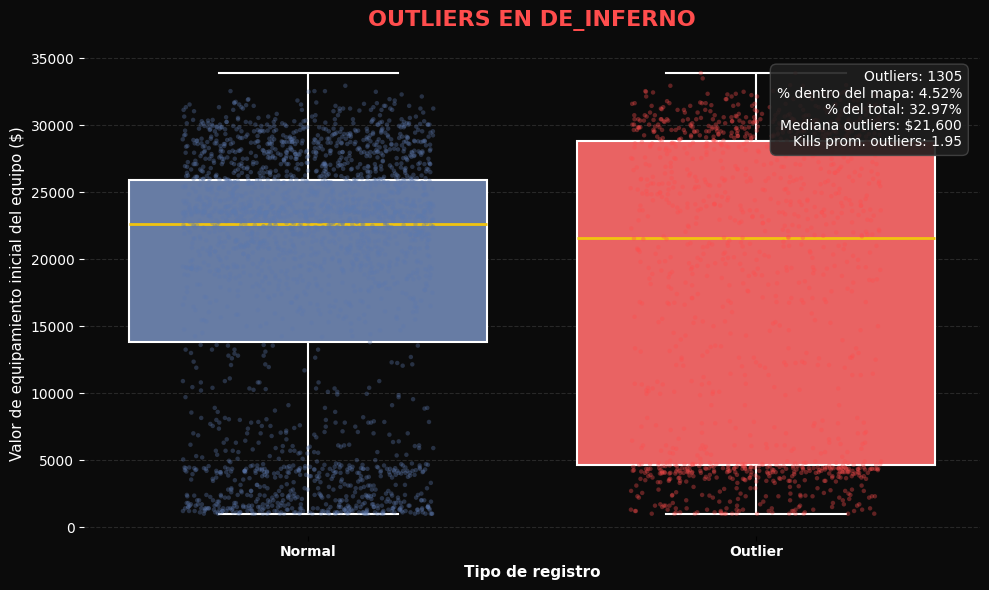

In [12]:
graficar_outliers_mapa('de_inferno')

**Análisis de `de_inferno`**

El mapa `de_inferno` concentra la mayor cantidad absoluta de outliers (**1.305**, equivalente al **32,97%** del total), sin embargo, su tasa interna es la más baja (4,52%), lo que indica que su alta cantidad se explica principalmente por el mayor volumen de datos, los outliers se distribuyen en rangos económicos normales, con una mediana cercana a **$21.600**, lo que sugiere que no corresponden a valores extremos, sino a combinaciones poco frecuentes de variables como equipamiento, desempeño y resultado.

Desde el punto de vista del modelado, estos registros deben ser conservados, ya que representan situaciones reales del juego y aportan variabilidad al modelo.

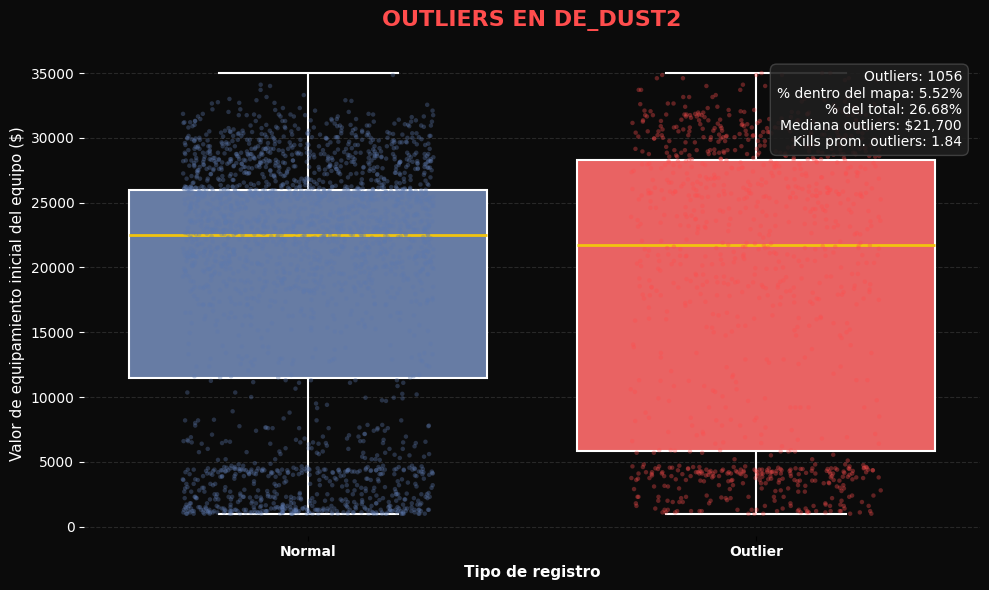

In [13]:
graficar_outliers_mapa('de_dust2')

**Análisis de `de_dust2`**

El mapa `de_dust2` presenta **1.056** outliers (**26,68%**), con la mayor proporción interna (**5,52%**), lo que lo convierte en el mapa con mayor intensidad de comportamiento atípico, los outliers aparecen tanto en rangos bajos como medios de equipamiento, indicando que el resultado de la ronda no siempre sigue la lógica económica esperada.

Esto sugiere que en este mapa existen dinámicas menos predecibles, por lo que el modelo podría tener mayor dificultad para capturar patrones consistentes, siendo recomendable evaluar su desempeño de forma segmentada.

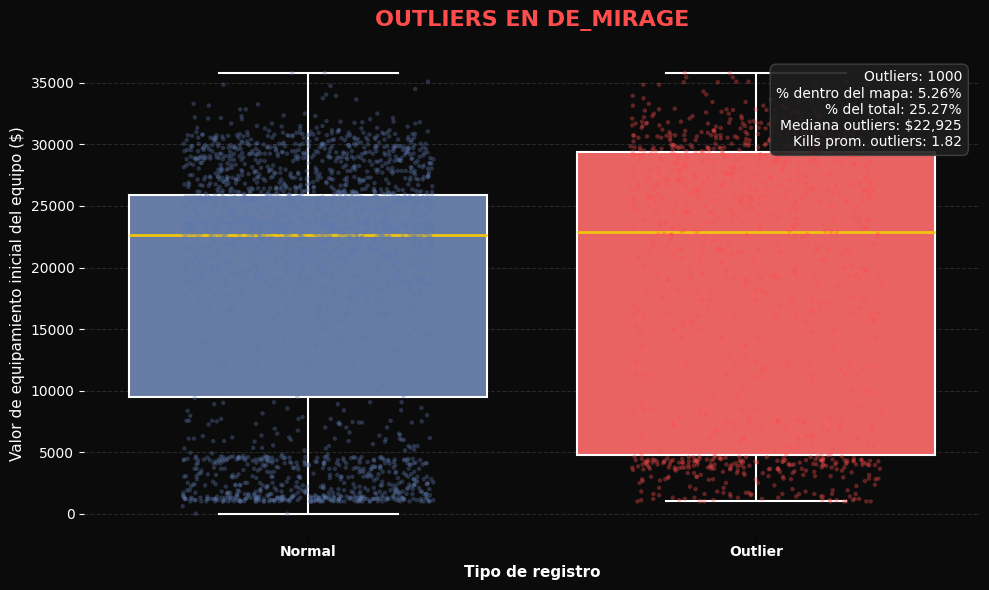

In [14]:
graficar_outliers_mapa('de_mirage')

**Análisis de `de_mirage`**

En `de_mirage` se identifican **1.000** outliers (**25,27%**), con una tasa interna de **5,26%**, la mediana de equipamiento de estos registros (**$22.925**) es relativamente alta, lo que indica que muchas anomalías ocurren en rondas con buena inversión económica.

Esto refuerza la idea de que el resultado no depende únicamente del dinero, por lo que variables de desempeño y estrategia tendrán un peso relevante en el modelo.

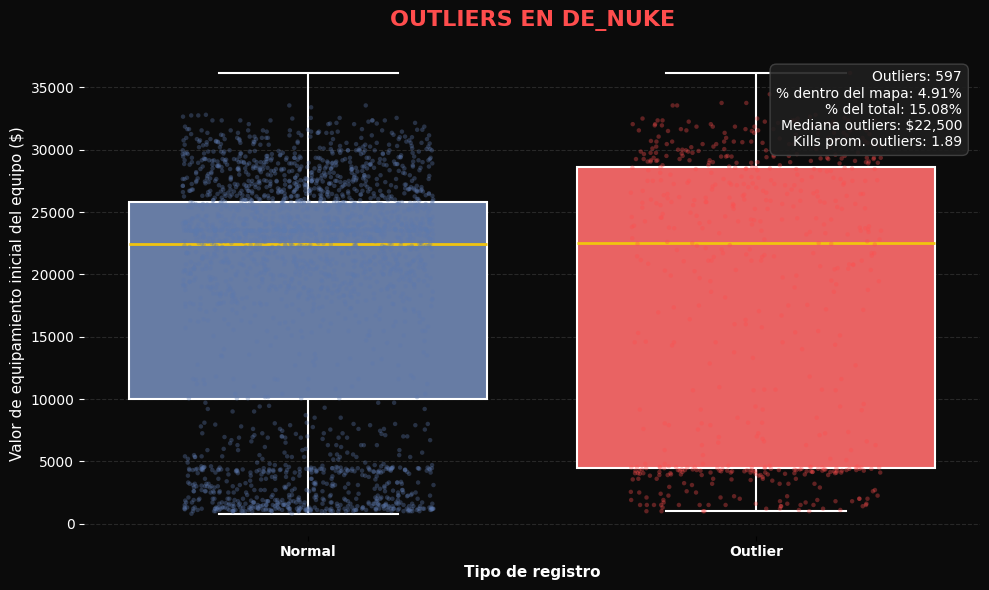

In [15]:
graficar_outliers_mapa('de_nuke')

**Análisis de `de_nuke`**

El mapa `de_nuke` presenta la menor cantidad de 597 outliers la menor cantidad absoluta, equivalente al **15,08%** del total de anomalías, con una tasa interna de **4,91%**, la mediana de equipamiento de los outliers bordea los **$22.500** no muestran desviaciones extremas.

Esto sugiere un comportamiento más estable, lo que podría facilitar el aprendizaje del modelo en este entorno.

**Analisis de outliers**

Desde la perspectiva del modelado, los outliers identificados no corresponden a errores de medición, sino a situaciones reales del juego caracterizadas por combinaciones poco frecuentes de variables, por esta razón, su eliminación no es recomendable, ya que representan información valiosa para el modelo.

Sin embargo, su distribución desigual entre mapas indica que la complejidad del problema varía según el entorno, esta heterogeneidad hace necesario evaluar el desempeño del modelo de manera segmentada por mapa para capturar adecuadamente estas variaciones, además, la presencia de estos valores refuerza la necesidad de aplicar técnicas de escalamiento robusto en la fase de preparación, garantizando que no influyan de manera desproporcionada en el aprendizaje del modelo, de esta forma, se preserva la información valiosa contenida en los outliers mientras se mitigan sus efectos potencialmente distorsionadores en el proceso de entrenamiento.

#### 2.4.2 Valores nulos (NaN)


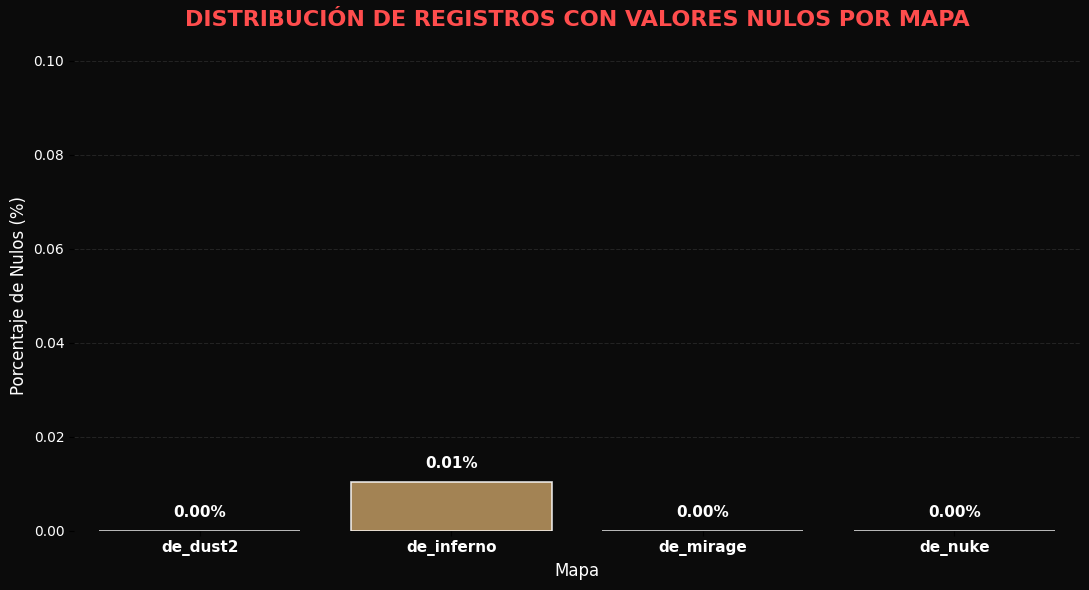

--- RESUMEN NUMÉRICO DE NULOS POR MAPA ---
   ▶ DE_DUST2     : 0.0000% (0 registros)
   ▶ DE_INFERNO   : 0.0104% (3 registros)
   ▶ DE_MIRAGE    : 0.0000% (0 registros)
   ▶ DE_NUKE      : 0.0000% (0 registros)


In [16]:
# Calcular el porcentaje y la cantidad de nulos por mapa
# Primero identificamos si la fila tiene al menos un nulo
df['has_nulls'] = df.isna().any(axis=1)

# Agrupamos por mapa para obtener estadísticas
null_stats = df.groupby('Map')['has_nulls'].agg(['mean', 'sum']).reset_index()
null_stats.columns = ['Map', 'NullPercentage', 'NullCount']
null_stats['NullPercentage'] *= 100

# Configuración de estilo del gráfico (Gamer/Dark)
plt.figure(figsize=(11, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Configuración de colores por mapa
map_colors = {
    'de_inferno': '#cf9c52',
    'de_dust2': '#e1b305',
    'de_mirage': '#9a8167',
    'de_nuke': '#4169e1'
}

# Crear el gráfico de barras con los colores específicos
ax = sns.barplot(
    x='Map',
    y='NullPercentage',
    data=null_stats,
    hue='Map',
    palette=map_colors,
    legend=False,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

# Añadir etiquetas de porcentaje sobre las barras con estilo
for p in ax.patches:
    height = p.get_height()
    # Solo mostrar etiqueta si el valor es mayor a 0 para no saturar si todo es 0
    label = f'{height:.2f}%'
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                color='white')

# Personalización de títulos y ejes
plt.title('DISTRIBUCIÓN DE REGISTROS CON VALORES NULOS POR MAPA', fontsize=16, fontweight='bold', color='#ff4d4d', pad=25)
plt.ylabel('Porcentaje de Nulos (%)', color='white', fontsize=12)
plt.xlabel('Mapa', color='white', fontsize=12)

# Estilo de ticks y límites
plt.xticks(color='white', fontsize=11, fontweight='bold')
plt.yticks(color='white')

# Ajuste de escala automático para ver valores pequeños o 0-1
plt.ylim(0, max(null_stats['NullPercentage'].max() * 2, 0.1))

# Rejilla sutil y limpieza
plt.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Mostrar resumen con formato elegante en consola
print("\033[1;36m--- RESUMEN NUMÉRICO DE NULOS POR MAPA ---\033[0m")
for _, row in null_stats.iterrows():
    print(f"   ▶ {row['Map'].upper():<12} : {row['NullPercentage']:.4f}% ({int(row['NullCount'])} registros)")

# Limpiamos la columna temporal
df.drop(columns=['has_nulls'], inplace=True)

El dataset presenta únicamente 3 valores nulos, lo que representa una proporción insignificante, por lo tanto, no afectan el análisis y pueden ser eliminados sin impacto en los resultados.


#### 2.4.3 Duplicados

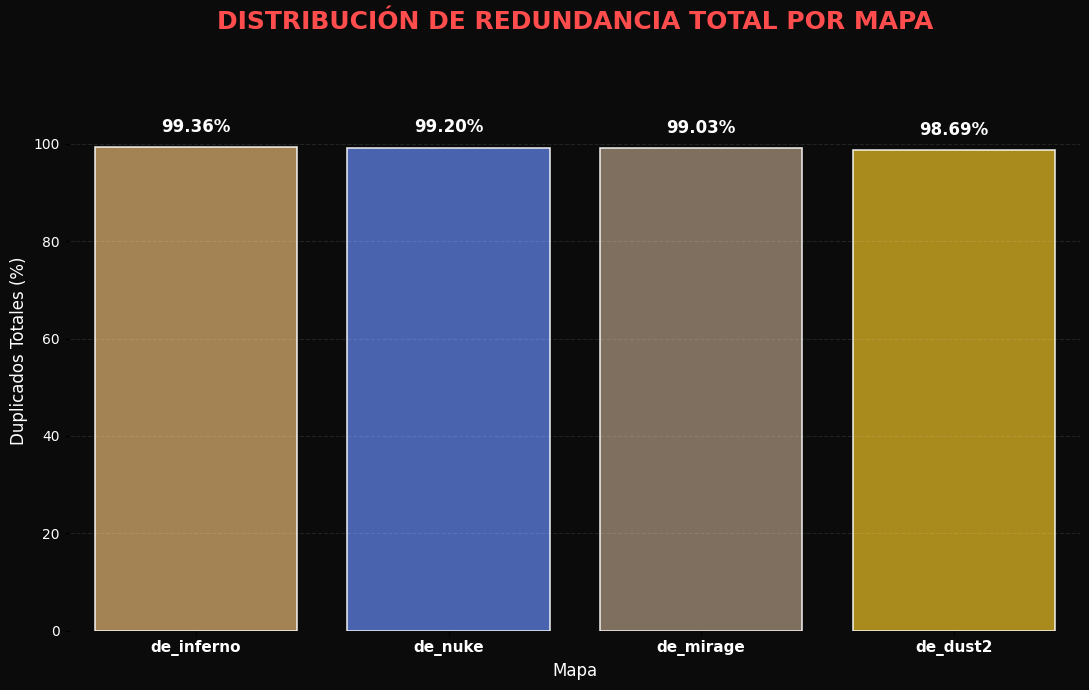

--- RESUMEN DE DUPLICADOS POR MAPA ---
   ▶ DE_INFERNO   : 99.36% (487,633 celdas duplicadas)
   ▶ DE_NUKE      : 99.20% (204,889 celdas duplicadas)
   ▶ DE_MIRAGE    : 99.03% (320,179 celdas duplicadas)
   ▶ DE_DUST2     : 98.69% (320,789 celdas duplicadas)


In [17]:
# 1. Preparación de datos: Calcular el porcentaje global de duplicados por mapa
map_results = []
numeric_vars = df.select_dtypes(include=[np.number]).columns

for mapa in df['Map'].unique():
    df_mapa = df[df['Map'] == mapa]
    total_registros_mapa = len(df_mapa) * len(numeric_vars)

    # Sumamos todos los duplicados de todas las variables en este mapa
    total_dups_mapa = sum(df_mapa[var].duplicated().sum() for var in numeric_vars)

    # Porcentaje global del mapa
    pct_global = (total_dups_mapa / total_registros_mapa) * 100 if total_registros_mapa > 0 else 0

    map_results.append({
        'Mapa': mapa,
        'Porcentaje_Total_Duplicados': pct_global,
        'Total_Duplicados': total_dups_mapa
    })

df_map_pct = pd.DataFrame(map_results)

# 2. Configuración visual mejorada (Estética Gamer/Dark)
plt.figure(figsize=(11, 7), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

map_colors = {
    'de_inferno': '#cf9c52',
    'de_dust2': '#e1b305',
    'de_mirage': '#9a8167',
    'de_nuke': '#4169e1'
}

# Crear el gráfico de barras
ax = sns.barplot(
    data=df_map_pct,
    x='Mapa',
    y='Porcentaje_Total_Duplicados',
    palette=map_colors,
    hue='Mapa',
    legend=False,
    edgecolor='white',
    linewidth=1.2,
    alpha=0.85
)

# Añadir etiquetas de valor sobre las barras con estilo
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='white',
                xytext=(0, 8), textcoords='offset points')

# Personalización de títulos y ejes
plt.title('DISTRIBUCIÓN DE REDUNDANCIA TOTAL POR MAPA', fontsize=18, fontweight='bold', color='#ff4d4d', pad=30)
plt.ylabel('Duplicados Totales (%)', color='white', fontsize=12)
plt.xlabel('Mapa', color='white', fontsize=12)

# Estilo de ticks y límites
plt.xticks(color='white', fontsize=11, fontweight='bold')
plt.yticks(color='white')
plt.ylim(0, 115)

# Rejilla sutil y limpieza
plt.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

# Resumen numérico con formato elegante
print("\033[1;33m--- RESUMEN DE DUPLICADOS POR MAPA ---\033[0m")
for _, row in df_map_pct.iterrows():
    print(f"   ▶ {row['Mapa'].upper():<12} : {row['Porcentaje_Total_Duplicados']:.2f}% ({int(row['Total_Duplicados']):,} celdas duplicadas)")

El análisis de duplicidad por mapa revela porcentajes superiores al ***98***% en todos los casos, sin embargo, estos valores corresponden a celdas individuales con datos repetidos, no a registros completos duplicados, este patrón es completamente esperado dado que muchas variables del dataset tienen un rango limitado de valores posibles, en consecuencia, no se trata de un problema de calidad de datos y no requiere intervención adicional.


### 2.5 Gráficos


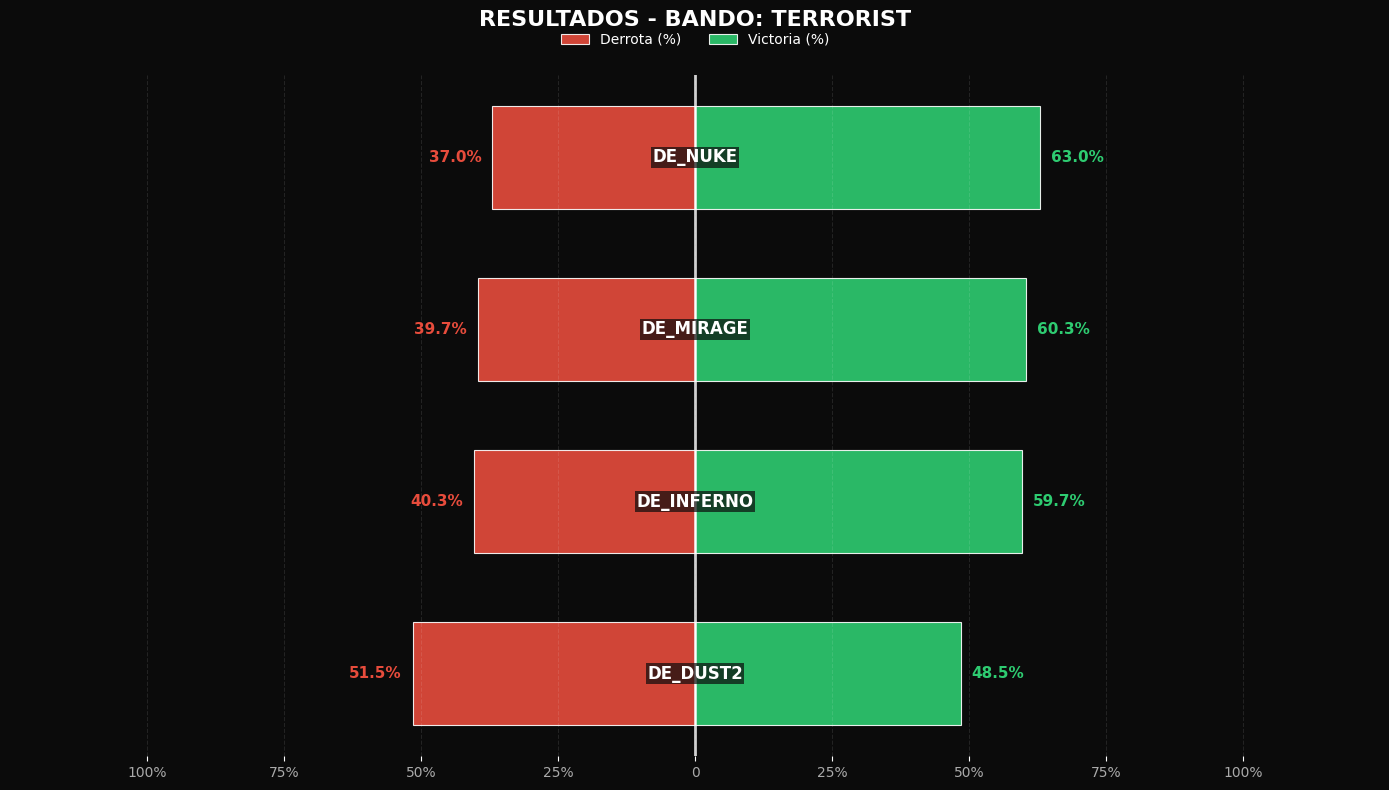

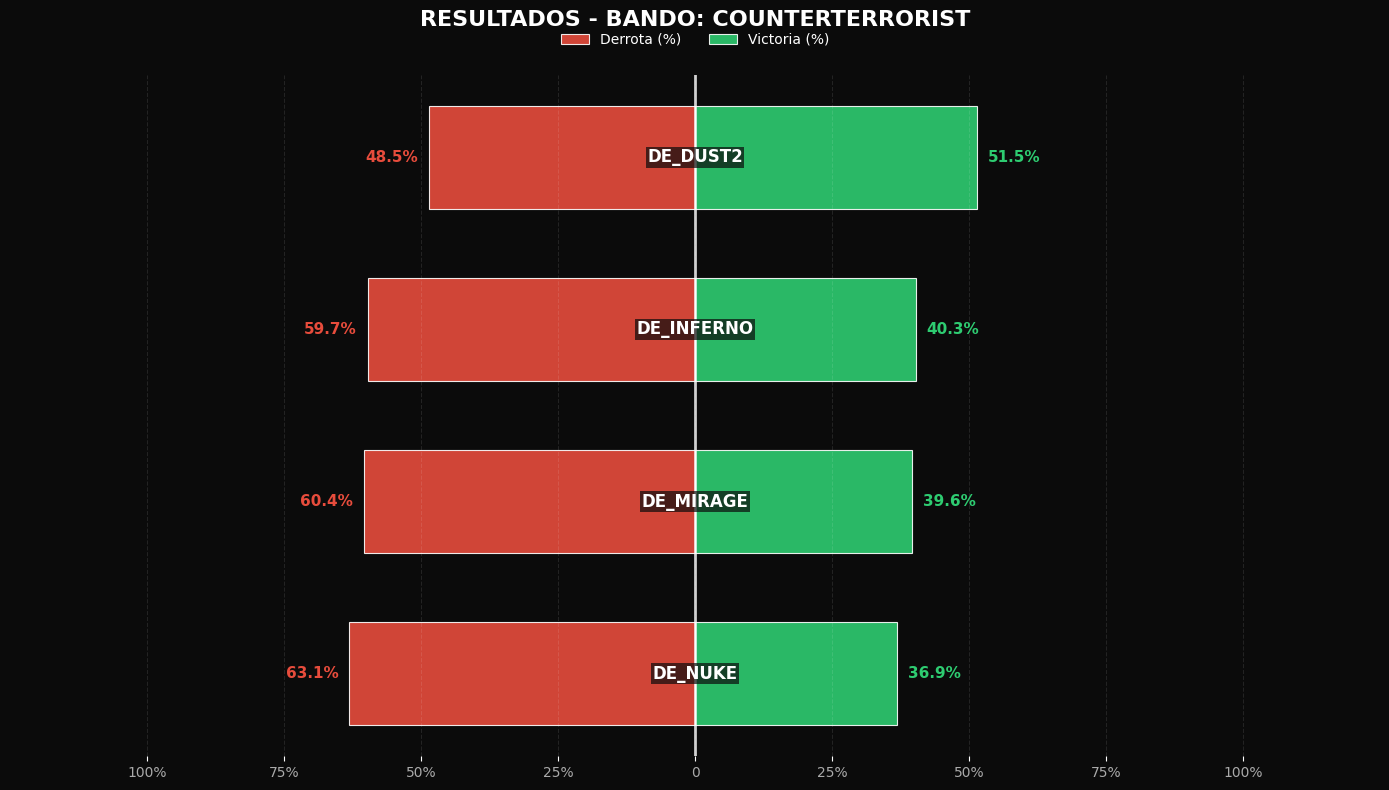

In [18]:
# 1. Preparación de datos: Calcular porcentajes por Mapa y Bando
df['RoundWinner_Bool'] = df['RoundWinner'].astype(str).str.lower().str.strip().map({
    'true': True,
    'false': False,
    'false4': False
})

# Agrupación por Mapa y Bando
stats_map_team = df.groupby(['Map', 'Team'])['RoundWinner_Bool'].value_counts(normalize=True).unstack() * 100
stats_map_team.columns = ['Loss %', 'Win %']
stats_map_team = stats_map_team.reset_index()

# 2. Configuración de la visualización (Gráficos separados)
plt.style.use('dark_background')
teams = ['Terrorist', 'CounterTerrorist']
color_win = '#2ecc71'
color_loss = '#e74c3c'

for team in teams:
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    # Filtrar datos por bando y ordenar para consistencia visual
    subset = stats_map_team[stats_map_team['Team'] == team].sort_values('Win %', ascending=True)

    # Barras espejo
    ax.barh(subset['Map'], -subset['Loss %'], color=color_loss, label='Derrota (%)', height=0.6, alpha=0.9, edgecolor='white', linewidth=0.8)
    ax.barh(subset['Map'], subset['Win %'], color=color_win, label='Victoria (%)', height=0.6, alpha=0.9, edgecolor='white', linewidth=0.8)

    # Etiquetas de porcentaje y nombre del mapa
    for idx, row in enumerate(subset.itertuples()):
        ax.text(-row._3 - 2, idx, f"{row._3:.1f}%", va='center', ha='right', color=color_loss, fontweight='bold', fontsize=11)
        ax.text(row._4 + 2, idx, f"{row._4:.1f}%", va='center', ha='left', color=color_win, fontweight='bold', fontsize=11)
        ax.text(0, idx, row.Map.upper(), va='center', ha='center', color='white',
                fontweight='black', fontsize=12, bbox=dict(facecolor='#0b0b0b', alpha=0.7, edgecolor='none', pad=1))

    ax.axvline(0, color='white', linewidth=2, alpha=0.8)
    ax.set_xlim(-125, 125)
    ax.set_xticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
    ax.set_xticklabels(['100%', '75%', '50%', '25%', '0', '25%', '50%', '75%', '100%'], color='#aaaaaa')
    ax.set_yticks([])
    ax.set_title(f'RESULTADOS - BANDO: {team.upper()}', color='white', size=16, fontweight='bold', pad=35)

    # Ajuste de posición de leyenda para evitar solapamiento
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False, labelcolor='white', fontsize=10)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.1, color='white')

    plt.tight_layout()
    plt.show()

**Análisis de distribución competitiva por mapa y bando**

El análisis de la distribución de victorias y derrotas por mapa y bando revela patrones estructurales que influyen directamente en el resultado de la ronda, la interpretación debe realizarse considerando la interacción entre ambas variables, ya que la ventaja competitiva no se distribuye de manera homogénea según el entorno.

- Mapa `DE_NUKE`: El bando **Terrorist** presenta una tasa de victoria superior a **CounterTerrorist**, sugiriendo una inclinación del mapa hacia el ataque, este comportamiento indica que, bajo ciertas condiciones, las estrategias ofensivas tienen mayor probabilidad de éxito, lo que convierte al bando en una variable explicativa relevante dentro del modelo.

- Mapa `DE_MIRAGE`: Se observa una ventaja consistente para **Terrorist**, posiblemente asociada a la estructura del mapa, que favorece duelos iniciales y control temprano del espacio, este patrón refuerza la importancia de considerar la interacción entre mapa y bando, en lugar de analizarlos de forma independiente.

- Mapa `DE_INFERNO`: Nuevamente se identifica una ventaja para **Terrorist**, sin embargo, este resultado debe interpretarse con cautela, dado que `de_inferno` concentra una alta proporción de los datos y de outliers, lo que podría amplificar patrones específicos y afectar la representatividad del análisis.

- Mapa `DE_DUST2`: Presenta un comportamiento más equilibrado, con una ligera ventaja para **CounterTerrorist**, esto sugiere que este mapa ofrece condiciones más simétricas, lo que podría facilitar el aprendizaje del modelo al reducir sesgos estructurales.

En conjunto, el análisis evidencia que tanto el mapa como el bando influyen significativamente en la probabilidad de victoria, incluso bajo condiciones económicas similares, esto implica que ambas variables deben ser incorporadas en el modelo, idealmente considerando su interacción mediante variables combinadas o encoding adecuado que capture estas dinámicas, además, la existencia de mapas con comportamientos más equilibrados y otros más sesgados sugiere la necesidad de evaluar el desempeño del modelo de forma segmentada, esta evaluación permitirá verificar su capacidad de generalización en distintos escenarios y detectar posibles limitaciones en mapas con mayor desequilibrio competitivo.

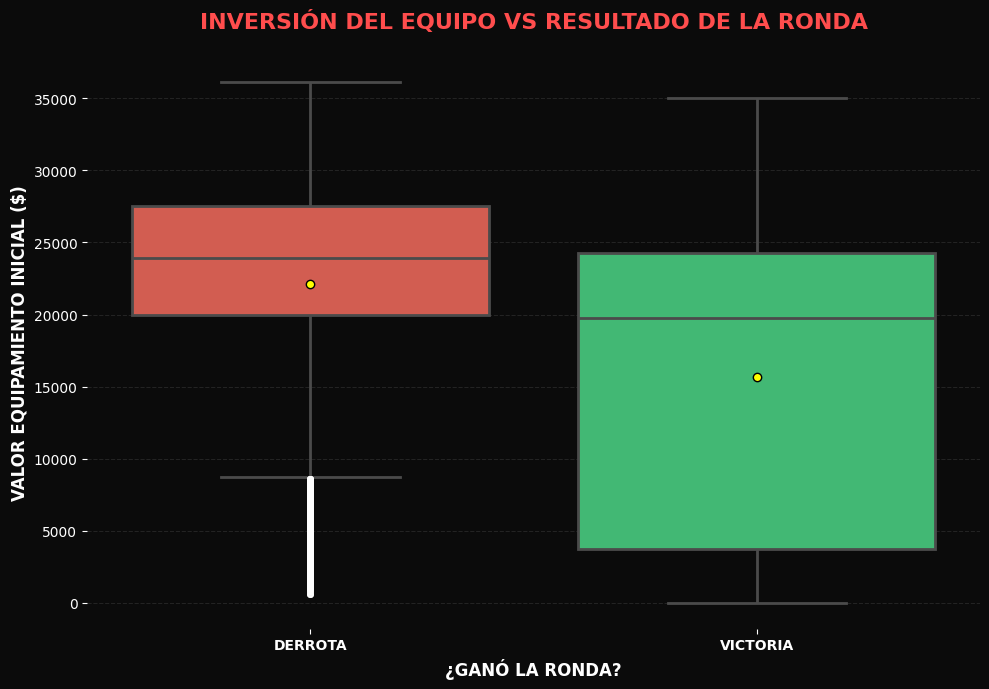

In [19]:
# Asegurar limpieza y formato de RoundWinner
df['RoundWinner'] = df['RoundWinner'].astype(str).replace({'False4': 'False', 'True': 'True', 'False': 'False'})

# Definir orden y colores
order = ['False', 'True']
colors_palette = {'False': '#e74c3c', 'True': '#2ecc71'}

# Estilo dark
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0b0b0b')
ax.set_facecolor('#0b0b0b')

# Generar Boxplot
sns.boxplot(
    x='RoundWinner',
    y='TeamStartingEquipmentValue',
    hue='RoundWinner',
    data=df,
    order=order,
    palette=colors_palette,
    linewidth=2,
    showfliers=True,
    fliersize=4,
    legend=False,
    flierprops={
        'markerfacecolor': 'white',
        'markeredgecolor': 'white',
        'alpha': 0.5
    },
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "yellow",
        "markeredgecolor": "black",
        "markersize": 6
    }
)

# Personalización de etiquetas y títulos
plt.title('INVERSIÓN DEL EQUIPO VS RESULTADO DE LA RONDA', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('¿GANÓ LA RONDA?', fontsize=12, color='white', fontweight='bold')
plt.ylabel('VALOR EQUIPAMIENTO INICIAL ($)', fontsize=12, color='white', fontweight='bold')
plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white', fontweight='bold')
plt.yticks(color='white')

# Grid y bordes
ax.grid(axis='y', linestyle='--', alpha=0.1, color='white')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

**Análisis del gráfico inversión vs. resultado**

Al examinar la relación entre el valor del equipamiento inicial y el resultado de las rondas, emergen patrones relevantes tanto desde el punto de vista estratégico como del modelado predictivo.

* **Distribución de medias:** La media del equipamiento en rondas ganadas es inferior a la de rondas perdidas, evidenciando que una mayor inversión no garantiza el éxito, este hallazgo sugiere que la eficiencia en el uso de recursos es más determinante que el gasto absoluto, por lo que variables económicas deben analizarse en conjunto con métricas de desempeño y contexto.

* **Rondas de compra completa (Full buy):** Se observa una alta concentración de derrotas en niveles elevados de inversión ($25.000+), lo que indica que incluso con equipamiento óptimo, el resultado depende de factores adicionales como posicionamiento, coordinación y ejecución, desde la perspectiva del modelo, esto refuerza que el equipamiento por sí solo es insuficiente para explicar la variable objetivo.

* **Eficacia de las rondas Eco/semi-Eco:** La baja mediana en rondas ganadas confirma que es posible obtener victorias con inversión limitada, esto introduce variabilidad en la relación entre economía y resultado, lo que puede dificultar la capacidad del modelo para capturar patrones lineales, sugiriendo la necesidad de considerar interacciones entre variables.

* **No linealidad en la relación inversión-resultado** El comportamiento observado indica la existencia de un punto de saturación, donde aumentos en la inversión no se traducen en mayores probabilidades de victoria, este patrón sugiere una relación no lineal, lo que implica que modelos lineales simples podrían no capturar completamente la dinámica del problema.

* **Gestión del riesgo:** La presencia de victorias con baja inversión demuestra que existen escenarios de alta incertidumbre donde el resultado no sigue la tendencia general, estos casos deben ser preservados, ya que aportan información relevante sobre situaciones reales del juego y contribuyen a la capacidad del modelo para generalizar.

En conclusión, el análisis evidencia que la relación entre inversión y resultado es compleja y no lineal, estando influenciada por múltiples factores adicionales, esto implica que las variables económicas deben ser utilizadas en combinación con otras métricas, y que el modelo deberá ser capaz de capturar interacciones y comportamientos no lineales para lograr una predicción precisa.


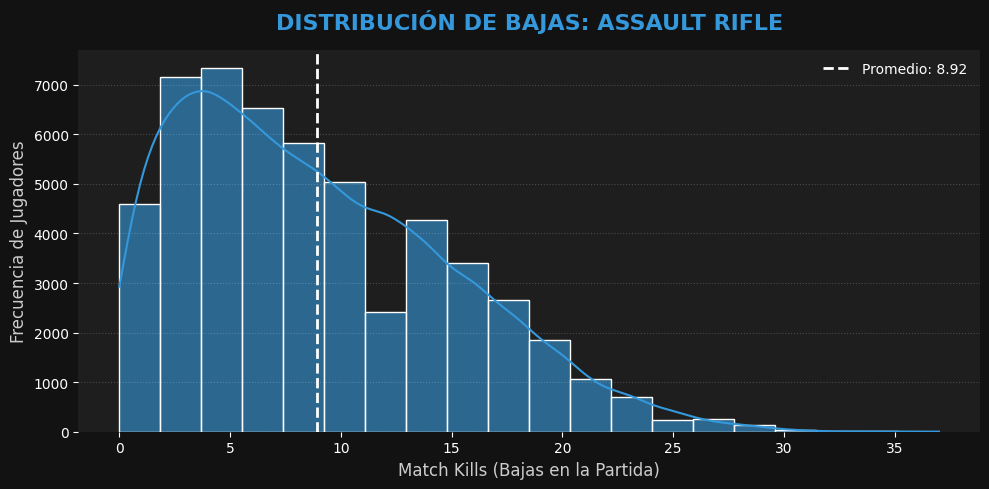

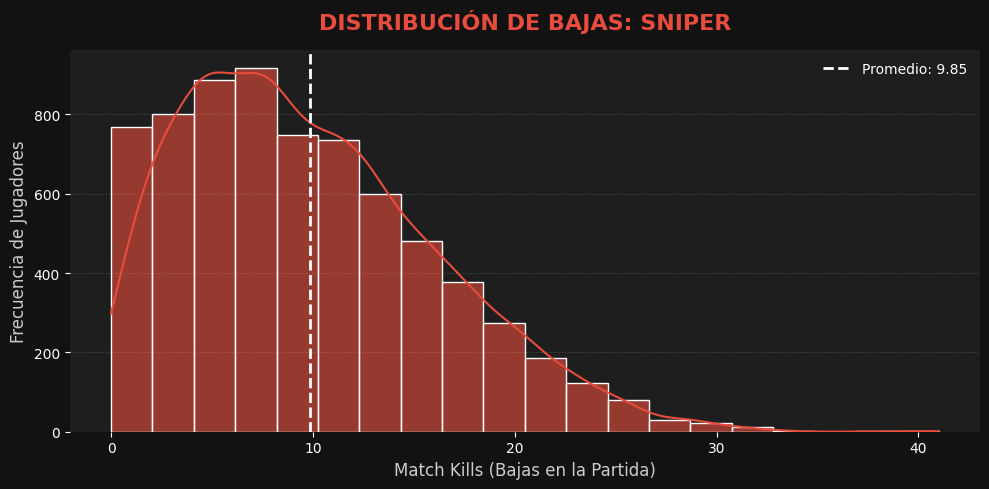

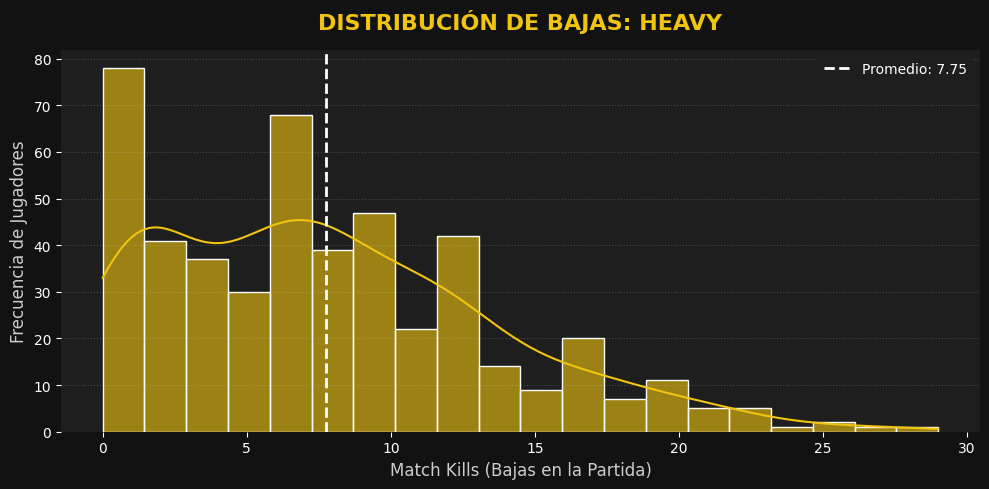

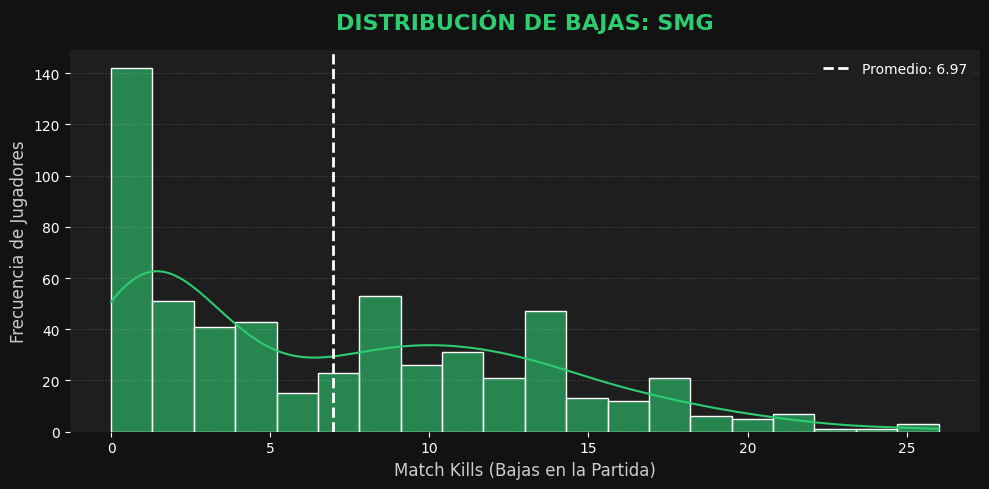

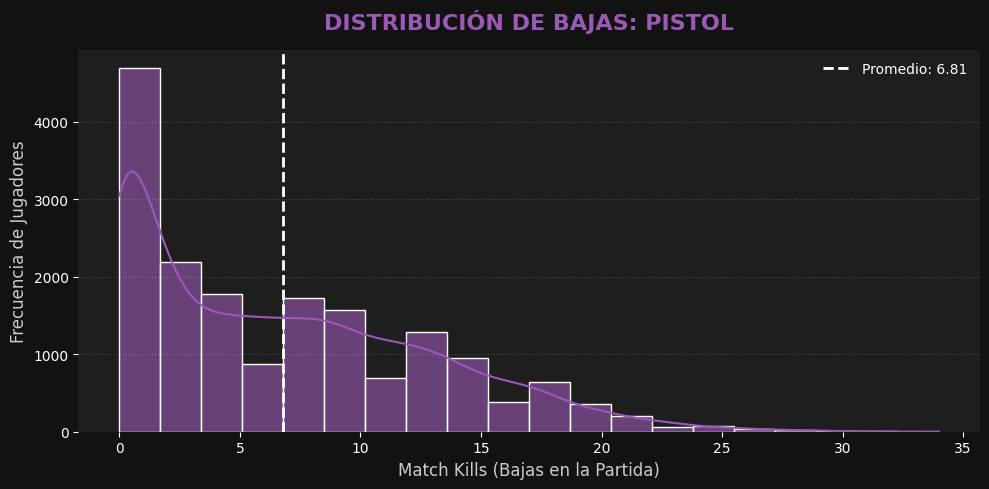

In [20]:
# Definir las categorías de armas y colores personalizados
weapon_cols = ['PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol']
weapon_labels = ['Assault Rifle', 'Sniper', 'Heavy', 'SMG', 'Pistol']
colors = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71', '#9b59b6']

# Configuración de estilo estético
plt.style.use('dark_background')

for i, col in enumerate(weapon_cols):
    # Crear una figura independiente para cada arma
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#121212')
    ax.set_facecolor('#1e1e1e')

    # Filtrar datos: Jugadores que usaron predominantemente esta arma
    data_subset = df[df[col] > 0.5]['MatchKills']
    mean_val = data_subset.mean()

    # Crear el histograma con diseño mejorado
    sns.histplot(data_subset, bins=20, kde=True, ax=ax, color=colors[i], alpha=0.6, edgecolor='white', linewidth=1)

    # Línea de promedio
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=2, label=f'Promedio: {mean_val:.2f}')

    # Personalización del gráfico
    ax.set_title(f'DISTRIBUCIÓN DE BAJAS: {weapon_labels[i].upper()}', fontsize=16, fontweight='bold', color=colors[i], pad=15)
    ax.set_xlabel('Match Kills (Bajas en la Partida)', fontsize=12, color='#cccccc')
    ax.set_ylabel('Frecuencia de Jugadores', fontsize=12, color='#cccccc')
    ax.legend(facecolor='#1e1e1e', edgecolor='none')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.2)

    plt.tight_layout()
    plt.show()

**Análisis gráfico de distribución de bajas por Arma**

El análisis de la distribución de bajas según el tipo de arma permite identificar patrones relevantes en el desempeño y su posible impacto en el modelado predictivo.

* **Rifles de asalto:** Presentan la mayor frecuencia de uso y una distribución relativamente estable de bajas, lo que indica un desempeño consistente en distintas rondas, esto sugiere que son una variable representativa del estado estándar del juego, especialmente en rondas de inversión completa, desde la perspectiva del modelo, su alta frecuencia puede aportar estabilidad, aunque su baja variabilidad podría limitar su capacidad discriminativa individual.

* **Snipers:** Muestran una mayor dispersión en la cantidad de bajas, reflejando una alta variabilidad en el rendimiento, esto indica que su impacto depende de condiciones específicas, como el contexto de la ronda o el desempeño individual, para el modelado, esta variabilidad puede aportar poder explicativo, pero también introducir ruido si no se combina adecuadamente con otras variables relevantes.

* **Pistolas y SMGs:** Sus distribuciones se concentran en valores bajos, coherente con su uso en rondas eco o semi-eco, estas variables, más que reflejar capacidad ofensiva, actúan como indicadores del estado económico del equipo, por lo tanto, su valor predictivo está más asociado al contexto de la ronda que al desempeño directo.

* **Heavy (armas pesadas):** Presentan una baja frecuencia de uso y distribuciones limitadas, lo que indica que aparecen en situaciones específicas, debido a su baja representatividad, es probable que tengan un impacto reducido en el modelo y podrían ser evaluadas para simplificación o agrupación.

 En resumen, el tipo de arma principal refleja tanto el estado económico como el potencial ofensivo del equipo, pero su capacidad predictiva no es uniforme, mientras algunas categorías aportan estabilidad (rifles), otras introducen variabilidad (snipers) o contexto (pistolas y SMG), por esta razón, será necesario evaluar su relevancia dentro del modelo, considerando posibles transformaciones como agrupación de categorías o combinación con variables económicas para capturar mejor su impacto en el resultado.

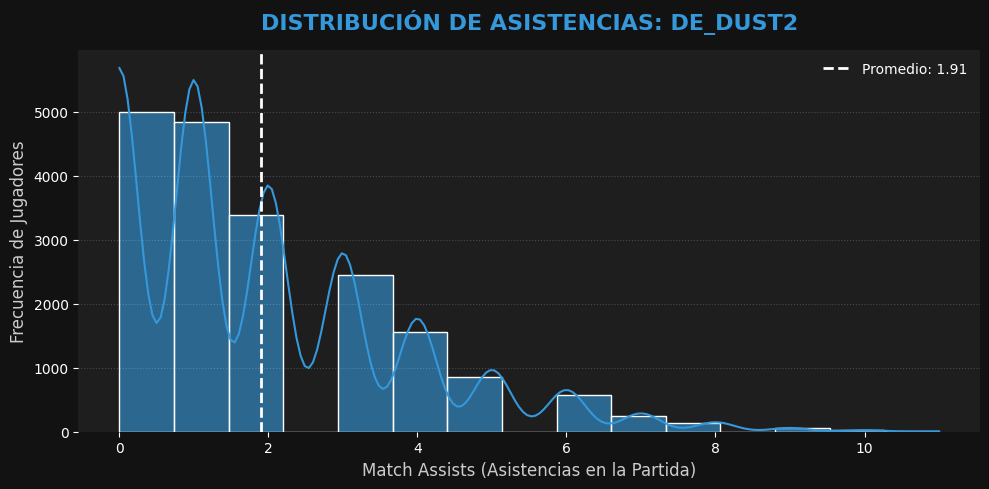

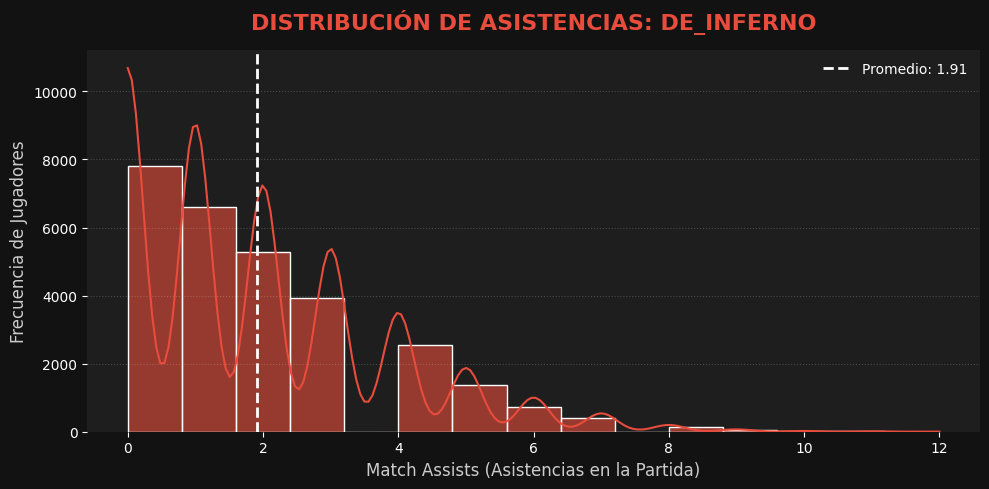

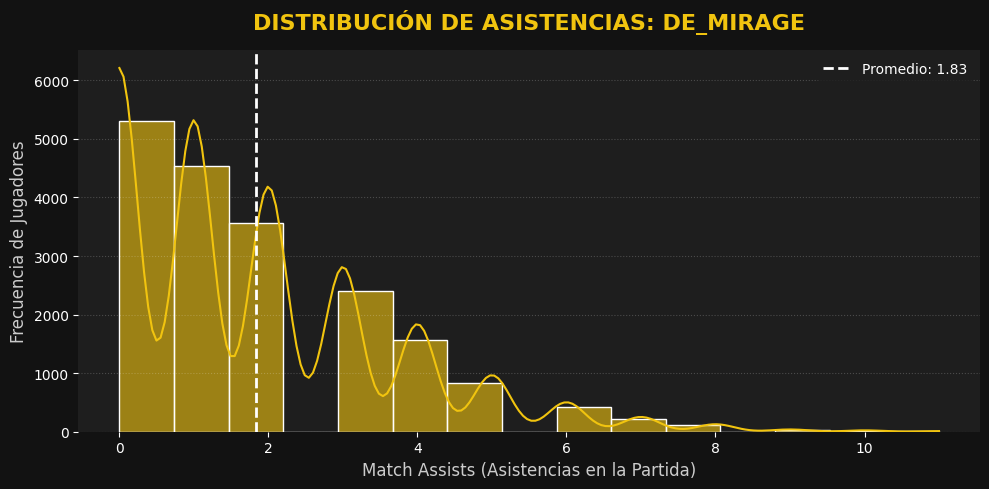

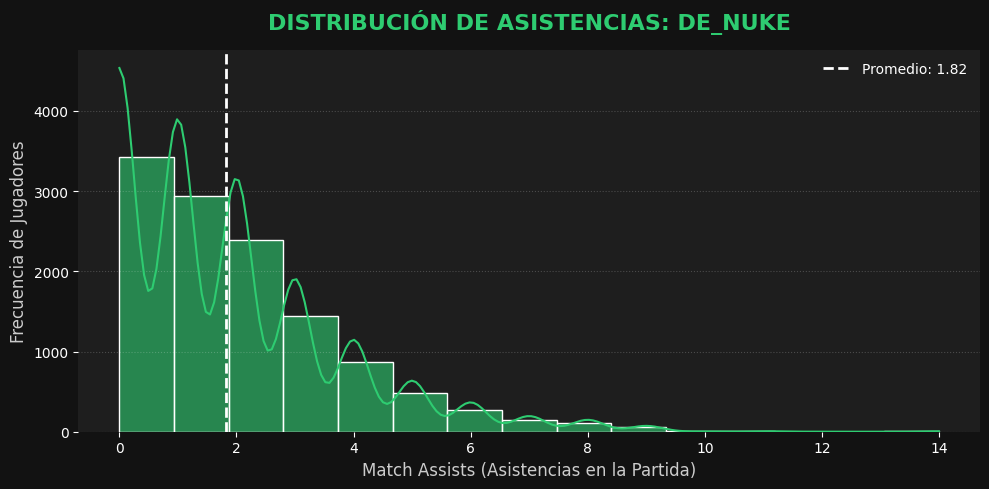

In [21]:
# Mapas y sus colores temáticos
maps = sorted(df['Map'].unique())
map_colors_list = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71']

# Configuración de estilo estético
plt.style.use('dark_background')

for i, map_name in enumerate(maps):
    # Crear una figura independiente para cada mapa con el estilo solicitado
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#121212')
    ax.set_facecolor('#1e1e1e')

    # Filtrar datos por mapa
    data_subset = df[df['Map'] == map_name]['MatchAssists']
    mean_val = data_subset.mean()

    # Crear el histograma con diseño mejorado
    sns.histplot(data_subset, bins=15, kde=True, ax=ax, color=map_colors_list[i % len(map_colors_list)], alpha=0.6, edgecolor='white', linewidth=1)

    # Línea de promedio
    ax.axvline(mean_val, color='white', linestyle='--', linewidth=2, label=f'Promedio: {mean_val:.2f}')

    # Personalización del gráfico
    ax.set_title(f'DISTRIBUCIÓN DE ASISTENCIAS: {map_name.upper()}', fontsize=16, fontweight='bold', color=map_colors_list[i % len(map_colors_list)], pad=15)
    ax.set_xlabel('Match Assists (Asistencias en la Partida)', fontsize=12, color='#cccccc')
    ax.set_ylabel('Frecuencia de Jugadores', fontsize=12, color='#cccccc')
    ax.legend(facecolor='#1e1e1e', edgecolor='none')

    # Eliminar bordes innecesarios
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.2)

    plt.tight_layout()
    plt.show()

**Análisis gráfico de Distribución de Asistencias por Mapa**

El análisis de la distribución de asistencias acumuladas por partida `MatchAssists` permite evaluar el rol del soporte en el desempeño del jugador y su posible impacto en el modelado.

* **El grueso se agrupa abajo**: En todos los mapas, la mayor parte de los jugadores se concentra en un rango de 0 a 5 asistencias, lo que indica que las asistencias son eventos menos frecuentes en comparación con las eliminaciones directas, esto sugiere que, de forma individual, esta variable podría tener menor poder predictivo en comparación con métricas como kills.

* **El promedio es estable**: El promedio de asistencias se mantiene cercano a 2 en todos los mapas, evidenciando un comportamiento consistente independiente del entorno, esta baja variabilidad indica que la variable tiene limitada capacidad para diferenciar escenarios, lo que podría reducir su relevancia como predictor principal.

* **Los outliers**: Se observan casos con más de 10 asistencias por partida, asociados a jugadores con alta participación en soporte o a partidas más extensas, estos valores, aunque poco frecuentes, reflejan situaciones reales y deben ser conservados, ya que pueden aportar información sobre dinámicas de juego específicas.

* **Variaciones según mapa:** Se identifican diferencias leves en la dispersión de asistencias entre mapas, `De_inferno` presenta distribuciones más concentradas, mientras que `de_dust2` muestra mayor dispersión, posiblemente asociada a interacciones a mayor distancia o uso de utilidad, sin embargo, estas diferencias no son lo suficientemente marcadas como para generar una segmentación clara por mapa.

En conclusión, `MatchAssists` actúa como un indicador complementario del desempeño, reflejando el nivel de soporte dentro del equipo, no obstante, su baja variabilidad y concentración en valores bajos sugieren que su capacidad predictiva individual es limitada, por ello, su mayor valor se obtiene al combinarla con otras métricas de desempeño, como kills o daño, permitiendo capturar de mejor forma la contribución total del jugador en el resultado de la ronda.

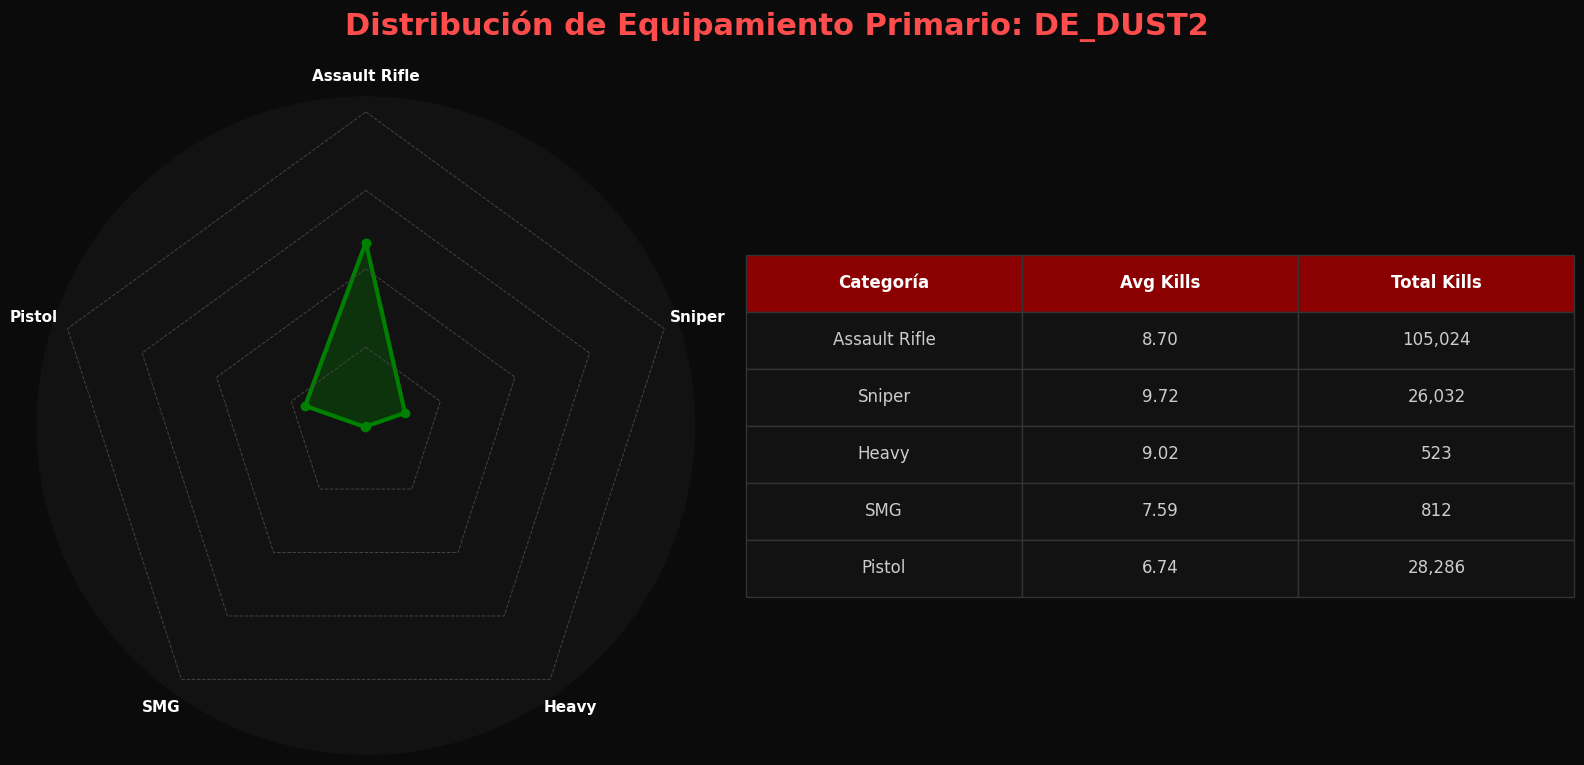

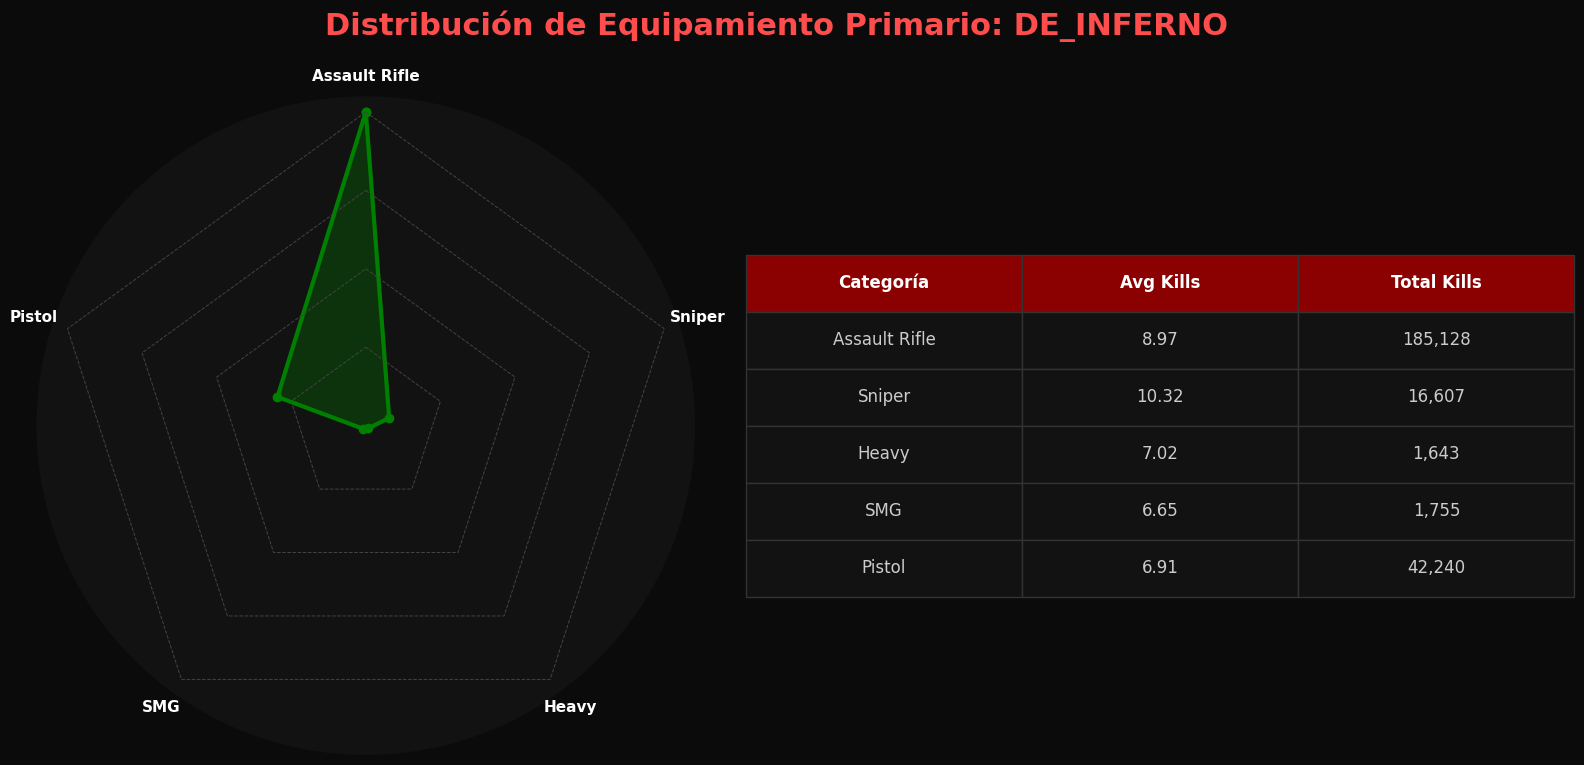

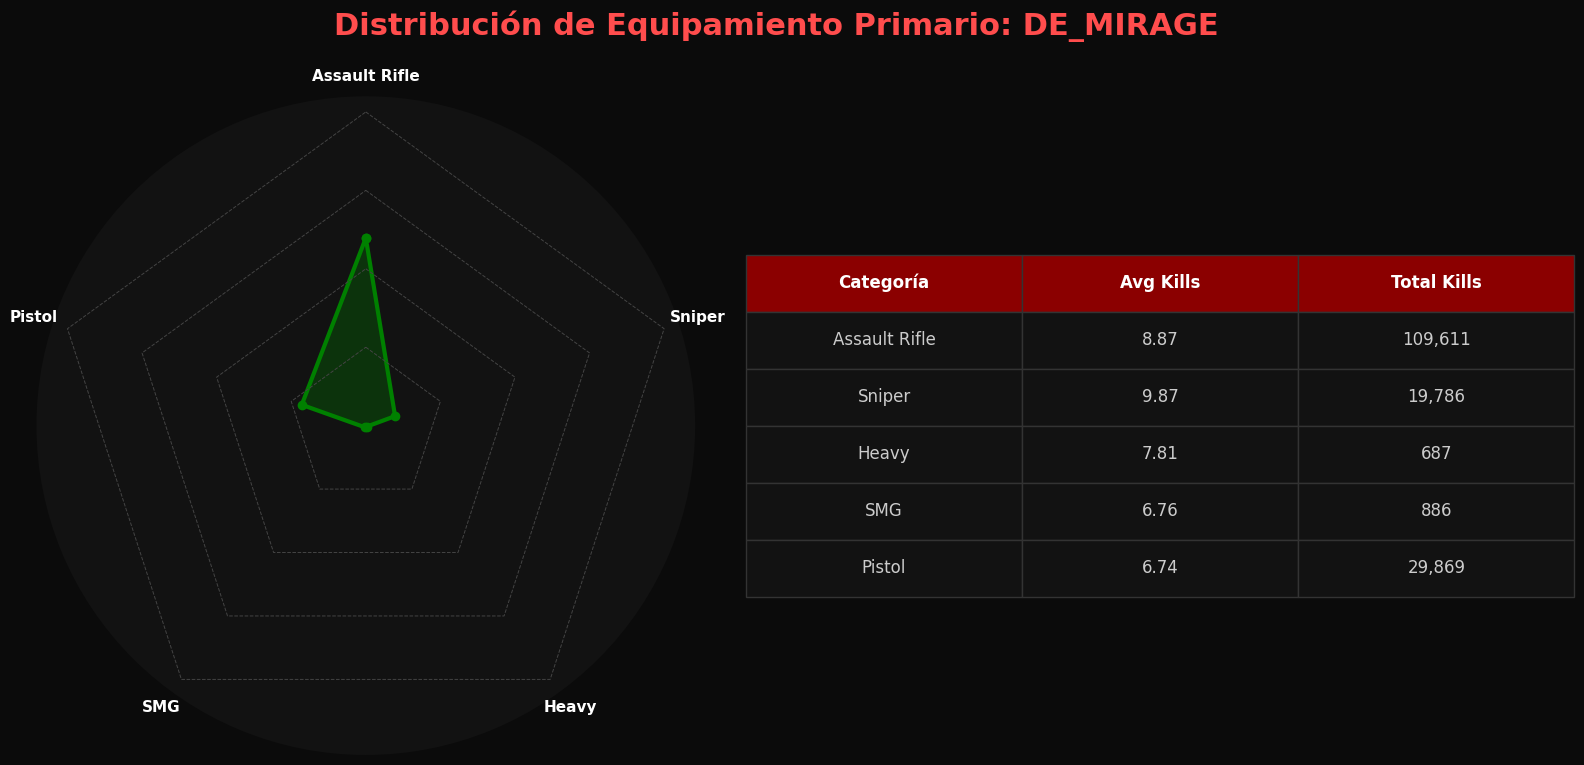

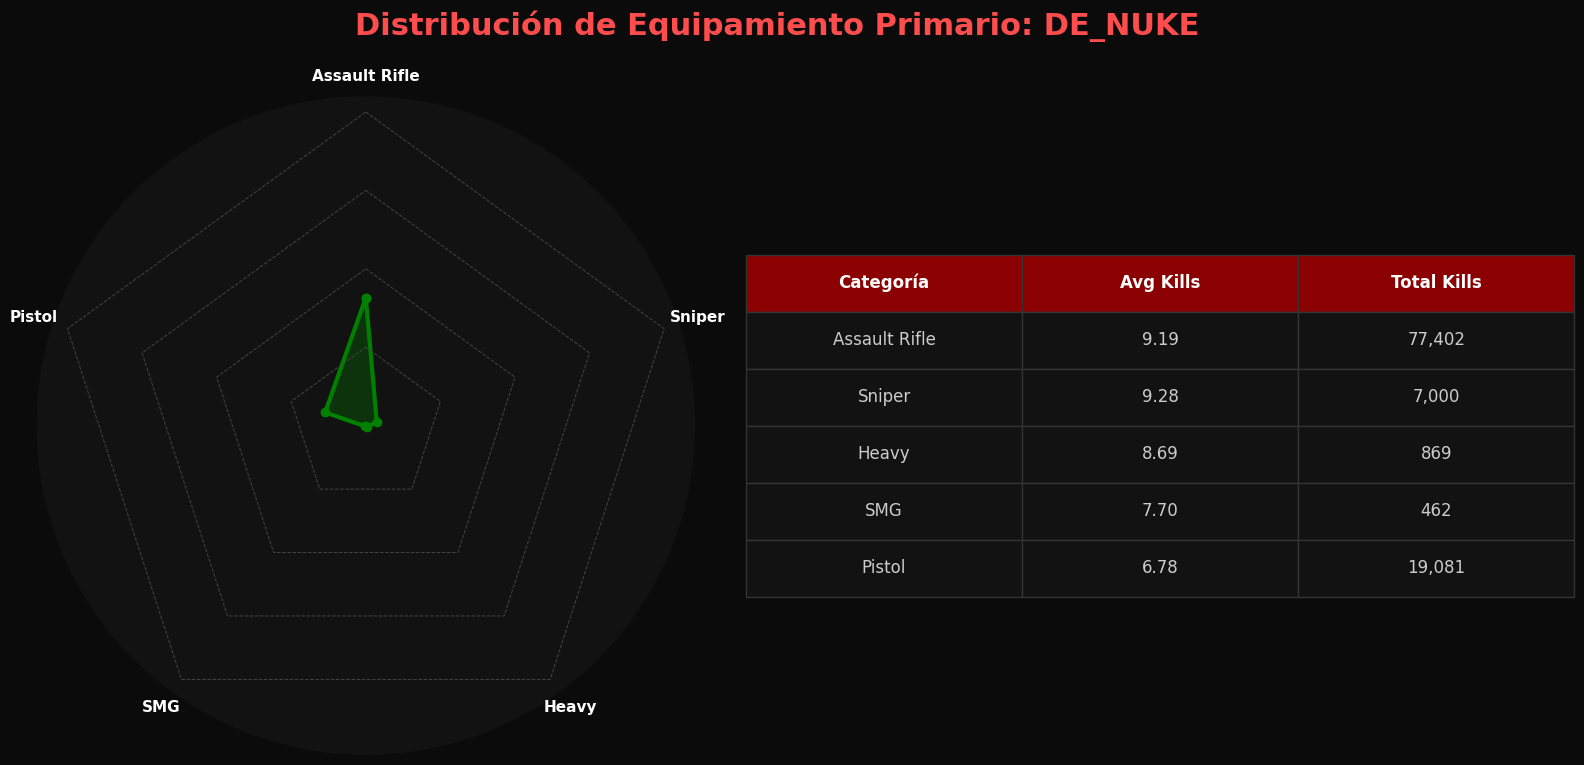

In [22]:
# Configuración de estilo oscuro
plt.style.use('dark_background')

# 1. Configuración de datos
weapon_cols = ['PrimaryAssaultRifle', 'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol']
weapon_labels = ['Assault Rifle', 'Sniper', 'Heavy', 'SMG', 'Pistol']

# MODIFICACIÓN: Ahora calculamos la SUMA (total acumulado) por mapa para el radar
map_weapon_usage_sum = df.groupby('Map')[weapon_cols].sum()

# 2. Estadísticas de desempeño (Kills) - Se mantienen igual para la tabla
map_weapon_stats = {}
for map_name in df['Map'].unique():
    stats_list = []
    for col in weapon_cols:
        mask = (df['Map'] == map_name) & (df[col] > 0.5)
        subset = df[mask]
        avg_k = subset['MatchKills'].mean() if not subset.empty else 0
        sum_k = subset['MatchKills'].sum() if not subset.empty else 0
        stats_list.append({'avg': round(avg_k, 2), 'sum': int(sum_k)})
    map_weapon_stats[map_name] = stats_list

# 3. Generar gráficos con forma de telaraña (poligonal)
maps = sorted(df['Map'].unique())
num_vars = len(weapon_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for map_name in maps:
    fig = plt.figure(figsize=(16, 8), facecolor='#0b0b0b')
    ax_radar = fig.add_subplot(121, polar=True, facecolor='#121212')
    ax_table = fig.add_subplot(122, facecolor='#0b0b0b')

    # Datos de SUMA del arma para el radar
    values = map_weapon_usage_sum.loc[map_name].values.flatten().tolist()
    values += values[:1]

    ax_radar.fill(angles, values, color='green', alpha=0.3)
    ax_radar.plot(angles, values, color='green', linewidth=3, marker='o')

    ax_radar.set_theta_offset(np.pi / 2)
    ax_radar.set_theta_direction(-1)
    ax_radar.set_rlabel_position(0)

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(weapon_labels, size=11, fontweight='bold', color='white')

    # Ajuste dinámico del grid basado en el máximo valor de la suma
    max_val = map_weapon_usage_sum.max().max()
    grid_values = np.linspace(0, max_val, 5)
    for g in grid_values:
        ax_radar.plot(angles, [g]*len(angles), color='#444444', linestyle='--', linewidth=0.7)

    ax_radar.grid(False)
    ax_radar.set_yticklabels([])
    ax_radar.spines['polar'].set_visible(False)

    # --- Tabla de Desempeño (Kills) ---
    ax_table.axis('off')
    weapon_perf = map_weapon_stats[map_name]
    table_data = [[label, f"{s['avg']:.2f}", f"{s['sum']:,}"] for label, s in zip(weapon_labels, weapon_perf)]

    the_table = ax_table.table(cellText=table_data, colLabels=['Categoría', 'Avg Kills', 'Total Kills'], loc='center', cellLoc='center')
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
    the_table.scale(1.2, 3.2)

    for (row, col), cell in the_table.get_celld().items():
        cell.set_edgecolor('#333333')
        if row == 0:
            cell.set_text_props(weight='bold', color='white')
            cell.set_facecolor('#8b0000')
        else:
            cell.set_facecolor('#121212')
            cell.set_text_props(color='#cccccc')

    plt.suptitle(f'Distribución de Equipamiento Primario: {map_name.upper()}', size=22, color='#ff4d4d', fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Análisis del gráfico Uso de Armamento y Efectividad Táctica**

Basado en las visualizaciones de radar y las métricas de desempeño, podemos extraer las siguientes conclusiones estratégicas:

* **Eficiencia y dominancia de los rifles de asalto:** Los rifles de asalto dominan tanto en frecuencia de uso como en efectividad, promediando unas ***9*** bajas por partida, esta consistencia los posiciona como la opción más eficiente, ofreciendo un rendimiento estable en diversos escenarios, en comparación de armas más situacionales, su versatilidad los convierte en la mejor alternativa en términos de costo-beneficio y fiabilidad a largo plazo.

* **Eficiencia condicionada de los Snipers:** Los francotiradores se utilizan con menor frecuencia, pero cuando se emplean, alcanzan niveles de letalidad comparables o incluso superiores a otras armas en ciertos contextos, esto refleja una **alta eficiencia relativa**, aunque fuertemente condicionada por la habilidad del jugador y el diseño del mapa, en escenarios con líneas de visión amplias, su rendimiento se maximiza, lo que evidencia que su impacto depende en gran medida del contexto táctico en lugar de ser consistente en todos los escenarios.

* **Función estratégica de las pistolas en la economía del juego:** Las pistolas se utilizan con frecuencia, pero registran un promedio menor de bajas (6.7 por partida), lo que refleja su función estratégica dentro de la economía del juego, su uso se concentra principalmente en rondas de bajo presupuesto (ronda eco), donde el objetivo no es maximizar eliminaciones, sino **mantener competitividad con recursos limitados**, su efectividad debe evaluarse en el contexto económico más que por su capacidad ofensiva directa.

* **Influencia del entorno en la selección de armamento:** El análisis demuestra que la estructura de los mapas influye directamente en la efectividad de las armas, los espacios abiertos favorecen el uso de *snipers* y *rifles* de largo alcance, mientras que los entornos cerrados potencian armas de corto alcance, esto confirma que la selección de armamento responde a **una adaptación táctica al entorno**, más que a una preferencia fija.

- **Proyección para Modelos Predictivos:** Los resultados sugieren que variables como el tipo de arma, el mapa y el contexto económico no actúan de forma aislada, sino que interactúan entre sí, esta integración conjunta es clave para explicar el desempeño del jugador y puede mejorar significativamente la capacidad predictiva de futuros modelos.

En resumen, se demuestra que el desempeño en Counter-Strike no depende de un único factor, sino de la interacción estratégica entre equipamiento, diseño del mapa y gestión económica, los rifles de asalto ofrecen la mejor relación costo-beneficio por su versatilidad, pero su efectividad se potencia o limita según el contexto táctico del mapa y los recursos disponibles, para desarrollar modelos predictivos precisos y herramientas de apoyo a la toma de decisiones, es esencial considerar estas variables de forma integrada, reconociendo que cada decisión de equipamiento es una adaptación táctica al entorno específico de juego, no una preferencia fija.


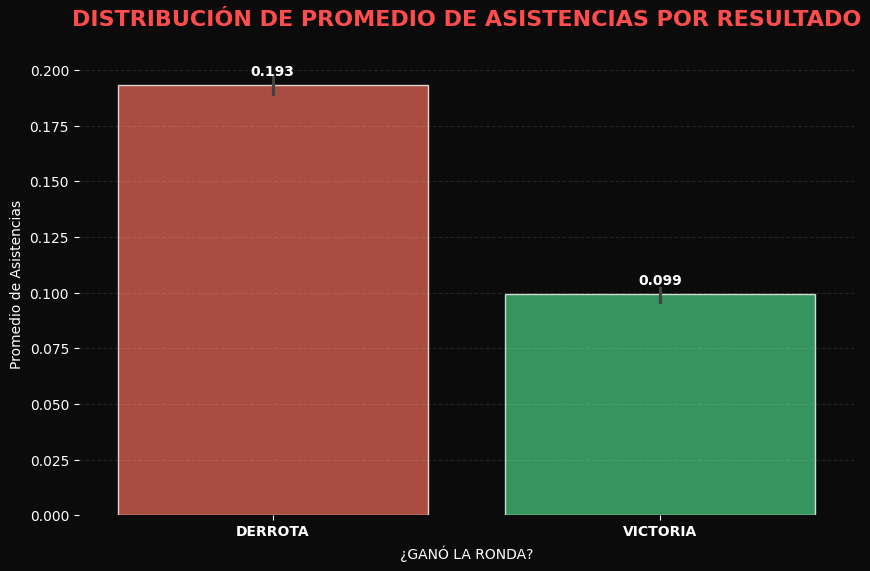

In [23]:
plt.figure(figsize=(10, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Corregimos el FutureWarning asignando hue=x y legend=False
sns.barplot(
    data=df,
    x='RoundWinner',
    y='RoundAssists',
    hue='RoundWinner',
    order=['False', 'True'],
    palette={'False': '#e74c3c', 'True': '#2ecc71'},
    legend=False,
    edgecolor='white',
    alpha=0.8
)

# Añadimos etiquetas de datos sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                color='white', fontweight='bold',
                xytext=(0, 5), textcoords='offset points')

plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white', fontweight='bold')
plt.yticks(color='white')
plt.title('DISTRIBUCIÓN DE PROMEDIO DE ASISTENCIAS POR RESULTADO', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('¿GANÓ LA RONDA?', color='white')
plt.ylabel('Promedio de Asistencias', color='white')

# Estética final
for spine in ax.spines.values():
    spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.show()

**Análisis del gráfico distribución del promedio de asistencias por el resultado de la ronda**

El análisis de la relación entre el promedio de asistencias por ronda `RoundAssists` y el resultado revela un patrón relevante que aporta información sobre la dinámica de combate.

* **Mayor promedio en rondas perdidas:** Se observa que las rondas perdidas presentan un promedio de asistencias superior (0.193) en comparación con las rondas ganadas (0.099), este comportamiento sugiere que, en escenarios de derrota, los jugadores tienden a infligir daño parcial a múltiples oponentes sin concretar las eliminaciones.

* **Eficiencia en la Victoria:** El bajo promedio de asistencias en victorias indica que las eliminaciones suelen ser más directas, reduciendo la necesidad de intervención de múltiples jugadores sobre un mismo objetivo, esto refleja una mayor eficiencia en la ejecución de los enfrentamientos.

* **Interpretación del fenómeno:** Este patrón no implica necesariamente que las asistencias causen la derrota, sino que actúan como un indicador del tipo de enfrentamientos que se están produciendo, un mayor número de asistencias puede estar asociado a situaciones donde el equipo no logra capitalizar el daño infligido.

En conclusión, `RoundAssists` puede considerarse un indicador complementario del desempeño, aportando información sobre la eficiencia en los enfrentamientos, sin embargo, su valor predictivo debe evaluarse en conjunto con otras variables como `RoundKills`, ya que por sí sola no explica completamente el resultado de la ronda, este comportamiento sugiere la existencia de relaciones entre variables que podrían ser relevantes para el modelado, especialmente al considerar interacciones o combinaciones de características.

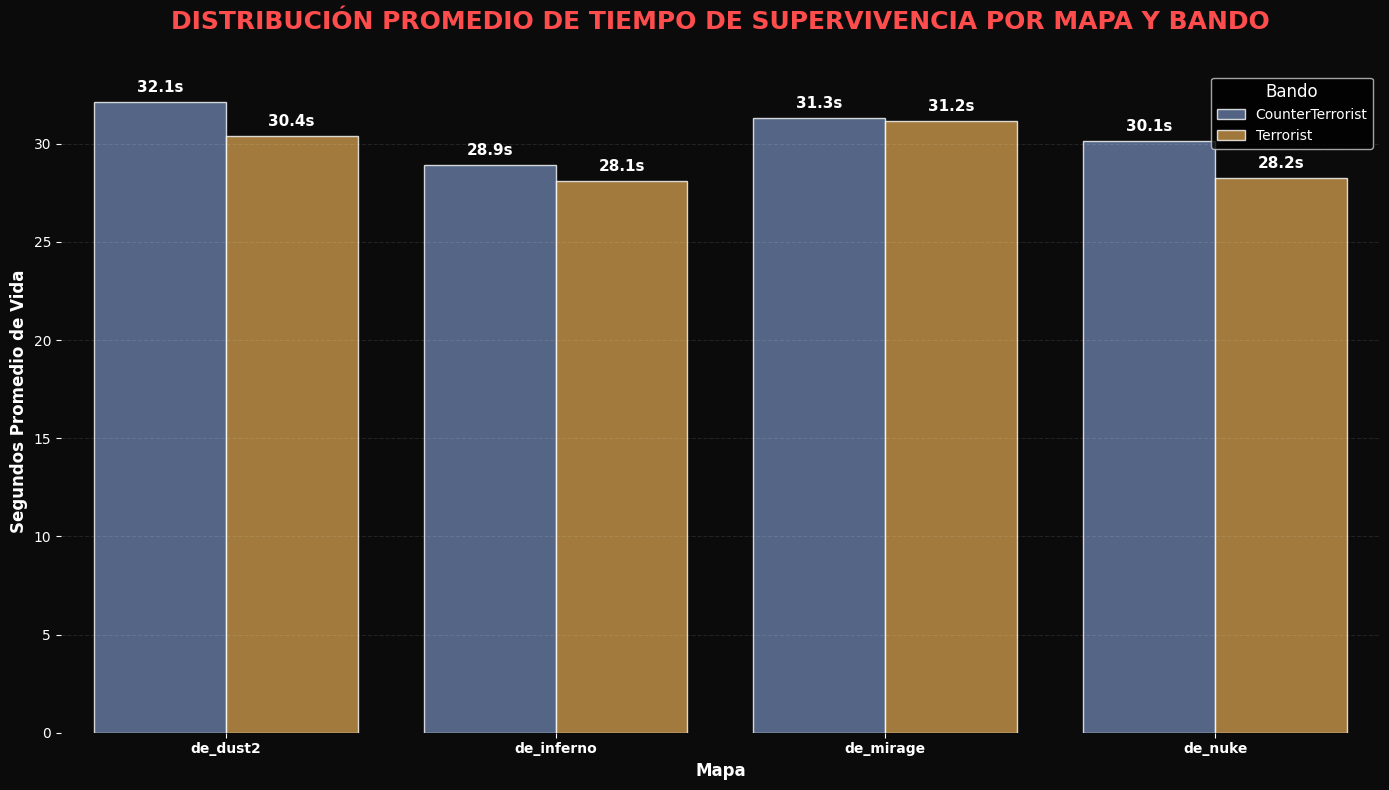

In [24]:
def clean_time(x):
    try:
        if pd.isna(x) or x == '': return 0
        val = str(x).strip()
        # Manejar formato con mùltiples puntos (extraer parte significativa)
        if val.count('.') > 1: val = val.split('.')[0]
        # Formato MM:SS
        if ':' in val:
            parts = val.split(':')
            return int(parts[0]) * 60 + int(parts[1])
        num_val = float(val)
        # Escalar valores de nanosegundos o muy altos
        if num_val > 1000000: return (num_val / 1e9) % 115
        return num_val if num_val < 200 else 200
    except:
        return 0

df['TimeAlive_Sec'] = df['TimeAlive'].apply(clean_time)
# Agrupamos por Mapa y Bando (Team)
map_team_survival = df.groupby(['Map', 'Team'])['TimeAlive_Sec'].mean().reset_index()

plt.style.use('dark_background')
plt.figure(figsize=(14, 8), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Colores temáticos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

sns.barplot(data=map_team_survival, x='Map', y='TimeAlive_Sec', hue='Team', palette=team_colors, edgecolor='white', alpha=0.8)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}s', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', color='white', fontweight='bold', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.title('DISTRIBUCIÓN PROMEDIO DE TIEMPO DE SUPERVIVENCIA POR MAPA Y BANDO', fontsize=18, fontweight='bold', color='#ff4d4d', pad=30)
plt.xlabel('Mapa', fontsize=12, color='white', fontweight='bold')
plt.ylabel('Segundos Promedio de Vida', fontsize=12, color='white', fontweight='bold')
plt.xticks(color='white', fontweight='bold')
plt.yticks(color='white')
plt.legend(title='Bando', title_fontsize='12', loc='upper right')

for spine in ax.spines.values(): spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()

**Análisis del gráfico distribución de supervivencia por bando de cada mapa**

El análisis del tiempo de supervivencia `TimeAlive` por bando y mapa permite identificar patrones relevantes asociados a la dinámica del juego y su posible impacto en el modelado.

* **Diferencias por bando:** En mapas como `de_dust2` y `de_nuke`, el bando **CounterTerrorist** presenta mayores tiempos de supervivencia que **Terrorist**, este comportamiento es consistente con el rol defensivo, donde los **CT** mantienen posiciones más estables, mientras que los **Terroristas** deben exponerse al avanzar, esto sugiere que la variable `Team` influye directamente en la distribución de `TimeAlive`, por lo que ambas deben analizarse de forma conjunta en el modelo.

* **Variación según el mapa:** En `de_inferno`, los tiempos de supervivencia son menores y más homogéneos entre bandos, lo que indica enfrentamientos más tempranos, en contraste, `de_mirage` presenta distribuciones más equilibradas, sugiriendo un entorno más simétrico, estas diferencias evidencian que el mapa condiciona la dinámica de supervivencia, por lo que su inclusión en el modelo resulta relevante.

* **Relación con la duración de la ronda:** Los valores promedio de `TimeAlive` se sitúan significativamente por debajo de la duración máxima de una ronda, lo que indica que la mayoría de los eventos críticos ocurre en etapas tempranas, esto sugiere que la variable captura información temporal relevante sobre el desarrollo de la ronda.

En conclusión, `TimeAlive` refleja patrones asociados al rol del equipo, el mapa y el momento en que ocurren los enfrentamientos, por ello, se considera una variable con potencial valor predictivo, especialmente cuando se combina con variables como `Team`, `Map` y **métricas** de desempeño, su inclusión en el modelo permitiría capturar dinámicas temporales que influyen en el resultado de la ronda.

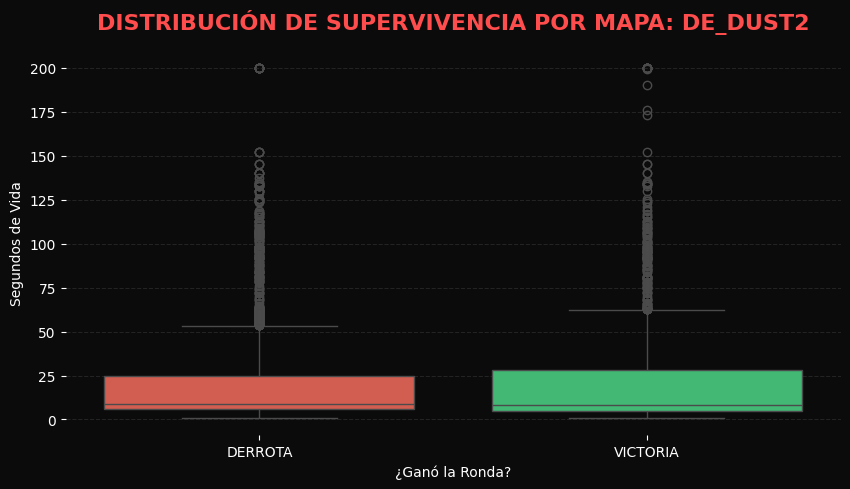

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_dust2 ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,9560.0,31.96,56.58,1.0,6.0,9.0,25.0,200.0
True,9560.0,30.55,54.60,1.0,5.0,8.0,28.0,200.0


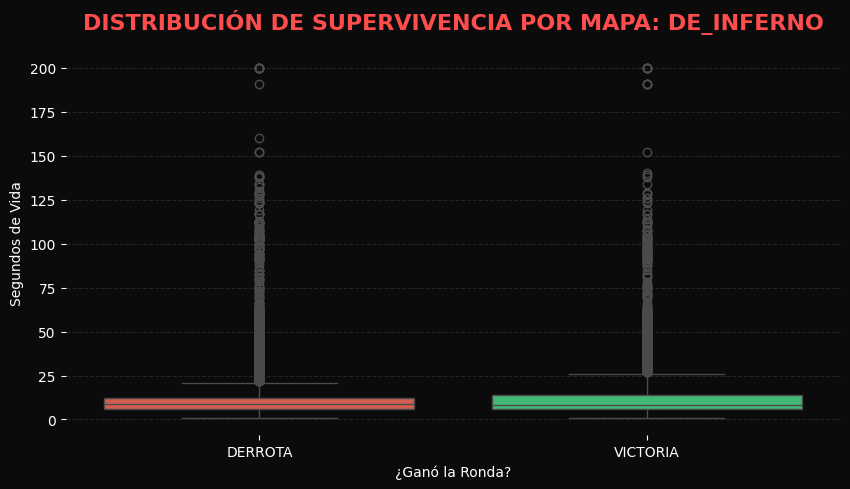

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_inferno ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,14440.0,28.18,52.81,1.0,6.0,9.0,12.0,200.0
True,14429.0,28.86,53.33,1.0,6.0,8.0,14.0,200.0


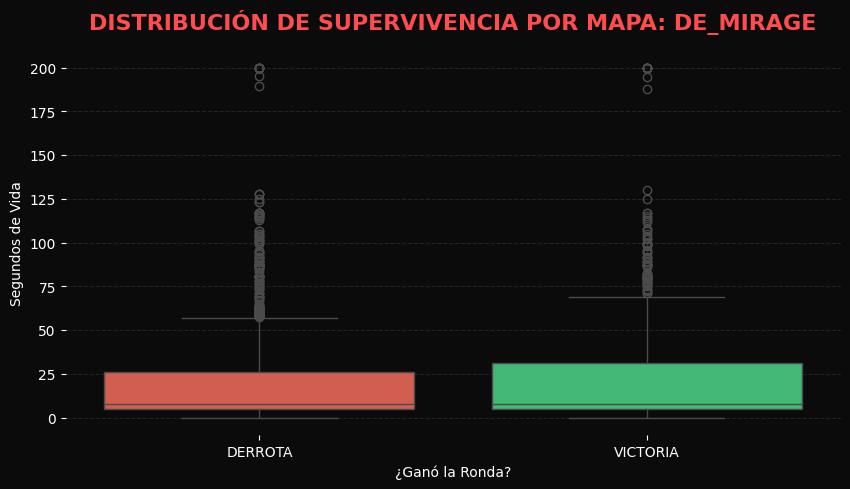

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_mirage ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,9515.0,30.56,54.84,0.0,5.0,8.0,26.00,200.0
True,9504.0,31.91,55.76,0.0,5.0,8.0,31.25,200.0


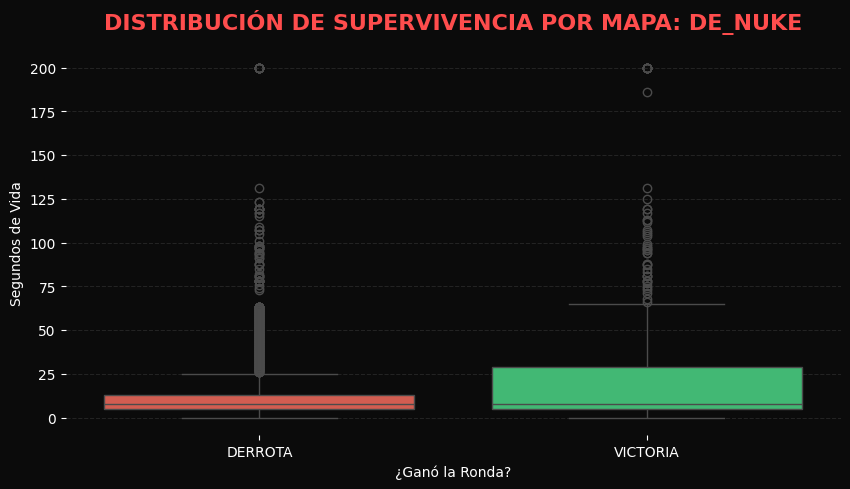

--- RESUMEN DE SUPERVIVENCIA POR MAPA de_nuke ---


,count,mean,std,min,25%,50%,75%,max
RoundWinner,,,,,,,,
False,6074.0,28.94,53.11,0.0,5.0,8.0,13.0,200.0
True,6075.0,29.41,53.15,0.0,5.0,8.0,29.0,200.0


In [25]:
# Análisis de supervivencia detallado por cada mapa en el dataset
maps_list = sorted(df['Map'].unique())

for mapa in maps_list:
    df_mapa = df[df['Map'] == mapa]

    # Crear figura para el mapa actual
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 5), facecolor='#0b0b0b')
    ax = plt.gca()
    ax.set_facecolor('#0b0b0b')

    sns.boxplot(
        data=df_mapa,
        x='RoundWinner',
        y='TimeAlive_Sec',
        hue='RoundWinner',
        palette={'False': '#e74c3c', 'True': '#2ecc71'},
        order=['False', 'True'],
        legend=False
    )

    plt.title(f'DISTRIBUCIÓN DE SUPERVIVENCIA POR MAPA: {mapa.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=15)
    plt.xlabel('¿Ganó la Ronda?', color='white')
    plt.ylabel('Segundos de Vida', color='white')
    plt.xticks([0, 1], ['DERROTA', 'VICTORIA'], color='white')
    plt.yticks(color='white')

    for spine in ax.spines.values(): spine.set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.1)

    plt.show()

    print(f"\033[1;33m--- RESUMEN DE SUPERVIVENCIA POR MAPA {mapa} ---\033[0m")
    # Aplicamos redondeo a 2 decimales para mejorar la legibilidad
    display(df_mapa.groupby('RoundWinner')['TimeAlive_Sec'].describe().round(2))
    print("\n" + "="*80 + "\n")

**Análisis del gráfico distribución de supervivencia**

El análisis de la distribución del tiempo de supervivencia `TimeAlive` permite identificar patrones relevantes en relación con el resultado de la ronda.

* **Diferencias en percentiles superiores:** En mapas como `de_dust2` y `de_mirage`, los jugadores en rondas ganadas tienden a presentar valores más altos en el percentil 75 (alrededor de 29 segundos), mientras que en rondas perdidas estos valores se sitúan por debajo (aproximadamente 26 segundos), esta diferencia sugiere que una mayor permanencia en la ronda se asocia con una mayor probabilidad de victoria, especialmente en etapas posteriores del enfrentamiento.

* **Similitud en la mediana:** La mediana del tiempo de supervivencia se mantiene baja y similar entre rondas ganadas y perdidas (alrededor de 8–9 segundos), lo que indica que los enfrentamientos iniciales afectan de manera transversal a ambos resultados, esto sugiere que la diferencia entre ganar o perder no está en evitar el contacto inicial, sino en el desempeño posterior.

* **Alta variabilidad:** La desviación estándar elevada (54 segundos) refleja una alta dispersión en los datos, indicando la coexistencia de eliminaciones tempranas y supervivencias prolongadas, este comportamiento evidencia que la variable presenta una distribución amplia, lo que puede aportar información relevante al modelo, pero también requerir escalamiento adecuado.

* **Influencia del mapa:** Se observan diferencias leves en la distribución según el mapa, donde escenarios más abiertos como `de_dust2` tienden a mostrar tiempos de supervivencia ligeramente mayores, mientras que mapas más cerrados como `de_inferno` presentan distribuciones más comprimidas, esto refuerza la idea de que el contexto del mapa influye en la dinámica temporal de la ronda.

En resumen, el tiempo de supervivencia muestra una relación positiva con el resultado de la ronda, especialmente en los percentiles superiores, lo que sugiere que su valor predictivo se concentra en etapas avanzadas del enfrentamiento, sin embargo, su alta variabilidad e similitud en etapas iniciales indican que debe analizarse en conjunto con otras variables, por ello, `TimeAlive` se posiciona como una variable relevante que podría capturar dinámicas temporales del juego, especialmente al combinarse con variables como `Team`, `Map` o **métricas** de desempeño.


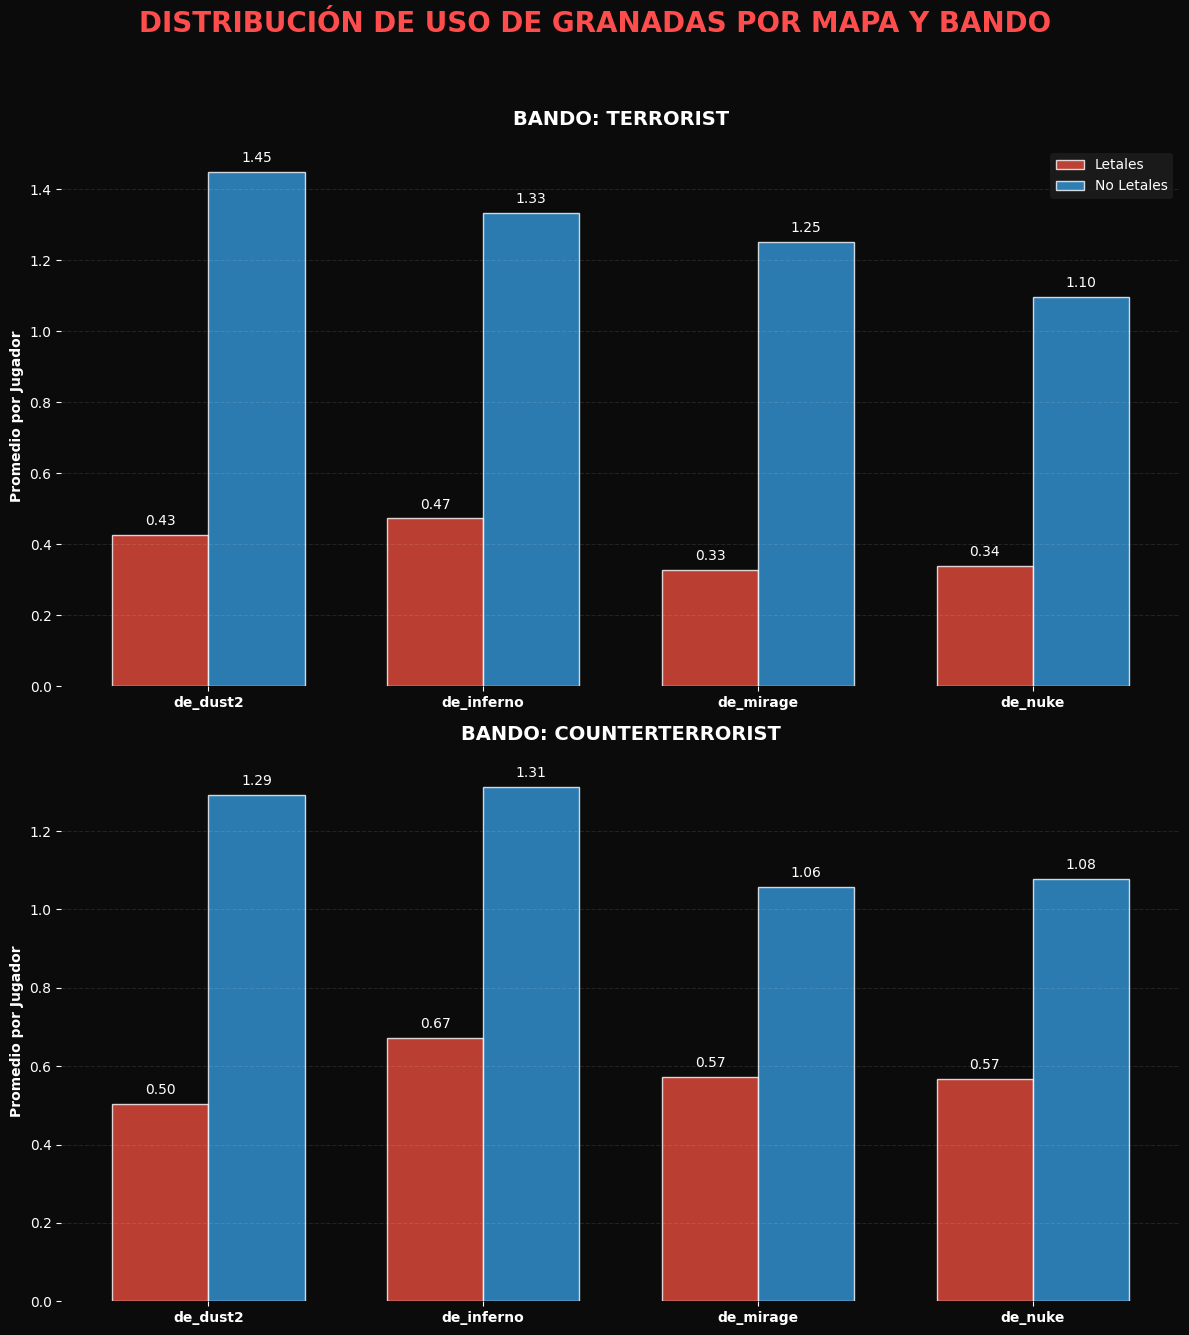

In [26]:
# Análisis de uso de granadas por mapa y bando (Vertical y Separados)
grenade_stats = df.groupby(['Map', 'Team'])[['RLethalGrenadesThrown', 'RNonLethalGrenadesThrown']].mean().reset_index()

teams = ['Terrorist', 'CounterTerrorist']
# 2 filas, 1 columna con mayor altura para dar espacio
fig, axes = plt.subplots(2, 1, figsize=(12, 14), facecolor='#0b0b0b')

for i, team in enumerate(teams):
    team_data = grenade_stats[grenade_stats['Team'] == team]
    ax = axes[i]
    ax.set_facecolor('#0b0b0b')

    x = np.arange(len(team_data['Map']))
    width = 0.35

    ax.bar(x - width/2, team_data['RLethalGrenadesThrown'], width, label='Letales', color='#e74c3c', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, team_data['RNonLethalGrenadesThrown'], width, label='No Letales', color='#3498db', alpha=0.8, edgecolor='white')

    # Personalización
    ax.set_title(f'BANDO: {team.upper()}', fontsize=14, fontweight='bold', color='white', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(team_data['Map'], color='white', fontweight='bold')
    ax.tick_params(axis='y', colors='white')
    ax.set_ylabel('Promedio por Jugador', color='white', fontweight='bold')

    # Etiquetas
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', color='white', fontsize=10, xytext=(0, 5), textcoords='offset points')

    # Estética de ejes
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.1)

plt.suptitle('DISTRIBUCIÓN DE USO DE GRANADAS POR MAPA Y BANDO', fontsize=20, fontweight='bold', color='#ff4d4d', y=0.98)
axes[0].legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white', loc='upper right')

# hspace añade separación vertical entre los subplots
plt.subplots_adjust(hspace=0.4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Análisis del gráfico distribución de uso de granadas y utilidad por bando**

El análisis de las variables `RLethalGrenadesThrown` y `RNonLethalGrenadesThrown` por bando permite identificar patrones asociados al rol táctico y su posible impacto en el resultado de la ronda.

* **Diferencias por bando**: Se observa que el bando `CounterTerrorist` tiende a utilizar más granadas letales en comparación con `Terrorist`, especialmente en mapas como `de_inferno`, este comportamiento es consistente con el rol defensivo, donde el uso de daño directo permite controlar zonas clave, por otro lado, los `Terroristas` muestran un uso relativamente mayor de utilidad no letal, orientada a facilitar la entrada a los sitios.

* **Predominio de utilidad no letal**: En ambos bandos, el uso de granadas no letales (smokes y flashes) es superior al de granadas letales, esto sugiere que el control del espacio y la visibilidad juega un rol más relevante que el daño directo en la dinámica del juego.

* **Variación según el mapa**: En mapas abiertos como `de_dust2`, se observa un uso más equilibrado de utilidad entre bandos, lo que indica que ambos requieren herramientas similares para disputar el control del mapa, en contraste, mapas más cerrados como `de_inferno` presentan diferencias más marcadas en el uso de granadas.

* **Relación con otras variables**: El uso de granadas se vincula con variables como `TimeAlive` y el resultado de la ronda, ya que una mayor utilización de utilidad puede influir en el ritmo del juego y en la generación de ventajas tácticas.

En conclusión, las variables relacionadas con el uso de granadas aportan información relevante sobre el estilo de juego y el rol del equipo en cada ronda, no obstante, su capacidad predictiva individual puede ser limitada, por lo que su mayor valor se obtiene al combinarlas con variables de contexto como `Team`, `Map` y **métricas** de desempeño, su inclusión en el modelo permitiría capturar aspectos tácticos que no están reflejados directamente en variables económicas o de bajas.

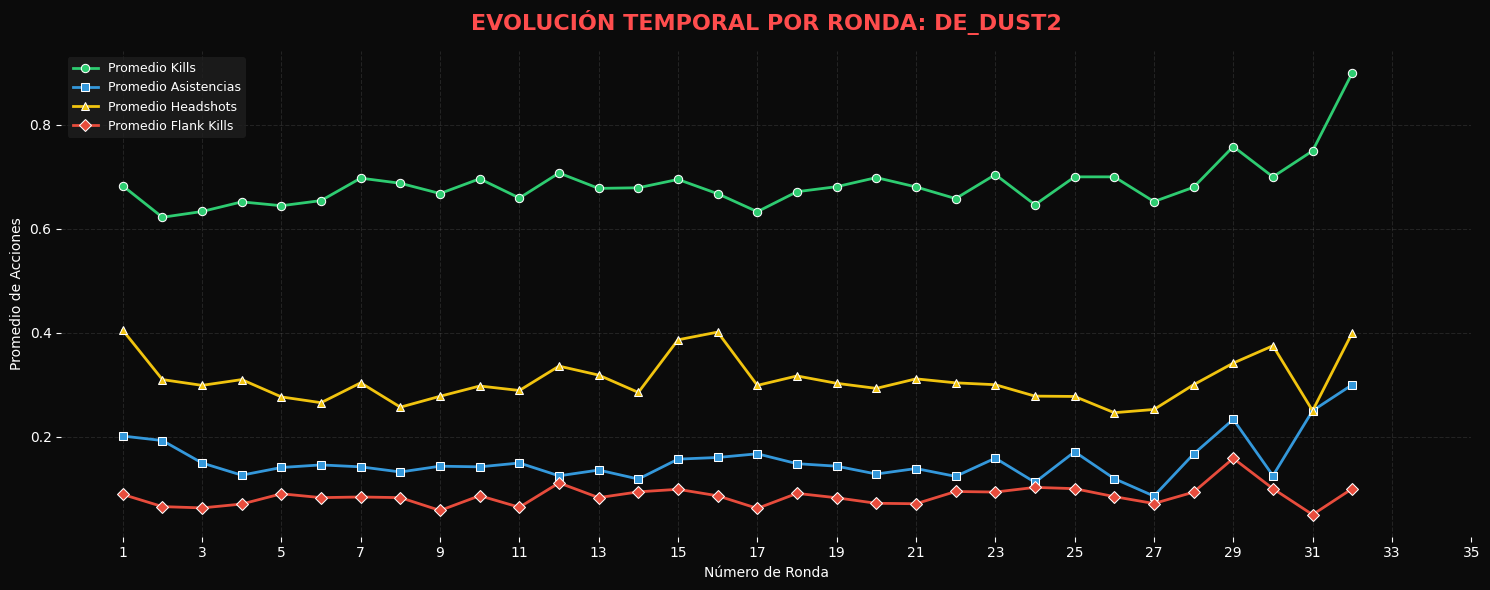

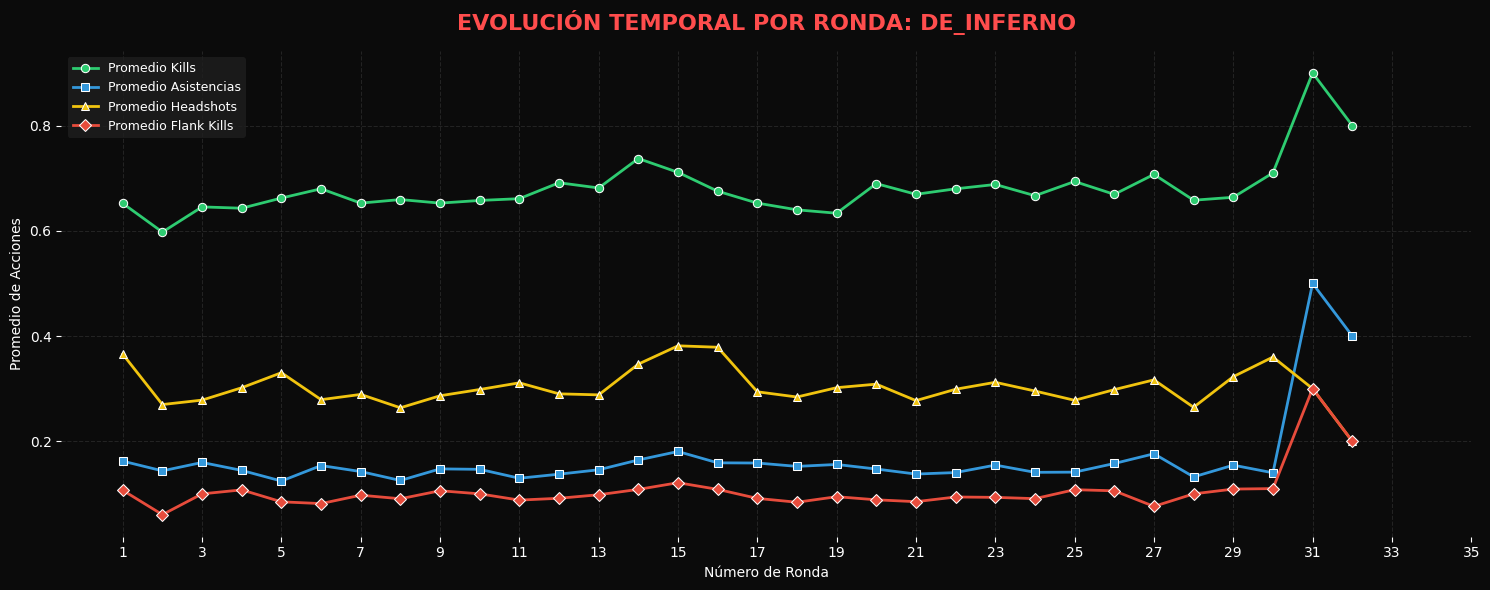

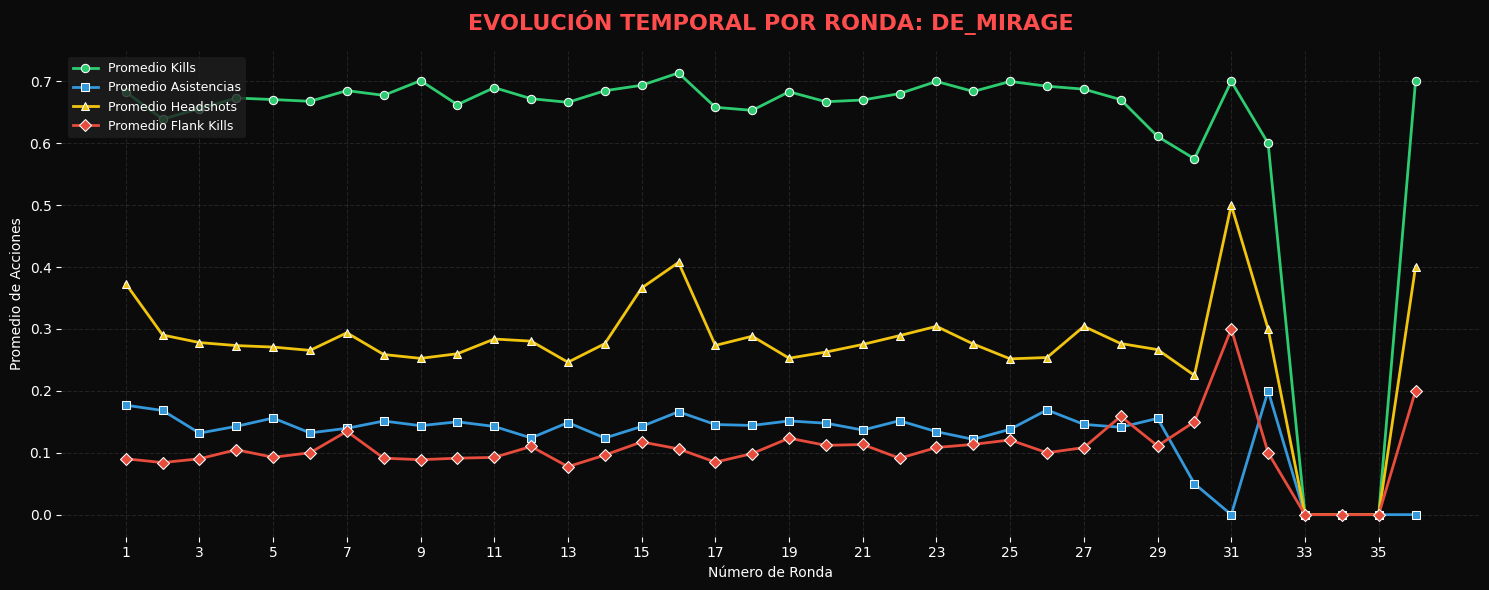

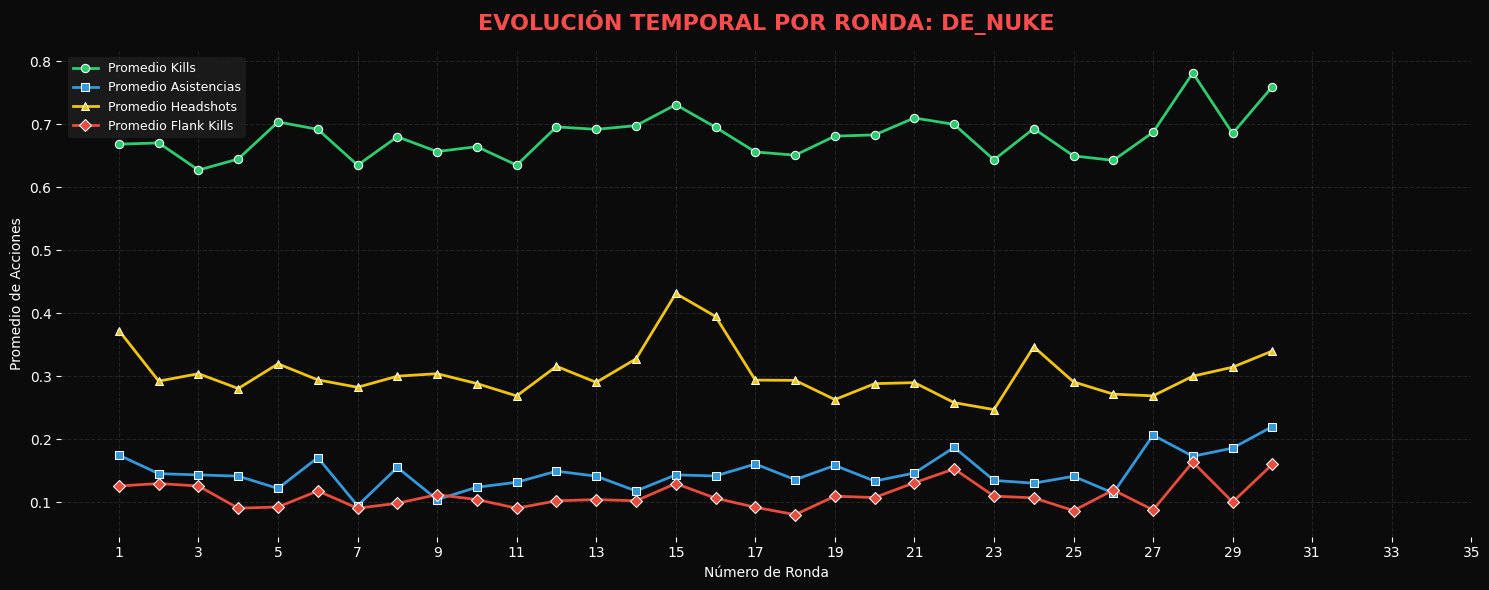

In [27]:
# Agrupar por Map y RoundId para obtener el promedio de desempeño detallado
metrics = ['RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills']
map_round_stats = df.groupby(['Map', 'RoundId'], observed=False)[metrics].mean().reset_index()

# Configuración de estilo dark
plt.style.use('dark_background')
maps = sorted(df['Map'].unique())

# Generar un gráfico independiente por cada mapa
for map_name in maps:
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')
    data_map = map_round_stats[map_round_stats['Map'] == map_name]

    # Dibujar las líneas temporales por mapa
    sns.lineplot(data=data_map, x='RoundId', y='RoundKills', marker='o', color='#2ecc71', label='Promedio Kills', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundAssists', marker='s', color='#3498db', label='Promedio Asistencias', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundHeadshots', marker='^', color='#f1c40f', label='Promedio Headshots', linewidth=2, ax=ax)
    sns.lineplot(data=data_map, x='RoundId', y='RoundFlankKills', marker='D', color='#e74c3c', label='Promedio Flank Kills', linewidth=2, ax=ax)

    # Personalización
    ax.set_title(f'EVOLUCIÓN TEMPORAL POR RONDA: {map_name.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=15)
    ax.set_xlabel('Número de Ronda', fontsize=10, color='white')
    ax.set_ylabel('Promedio de Acciones', fontsize=10, color='white')

    # Ajustar el eje X para que sea legible
    unique_rounds = data_map['RoundId'].unique()
    if len(unique_rounds) > 15:
        ax.set_xticks(unique_rounds[::2])
    else:
        ax.set_xticks(unique_rounds)

    ax.tick_params(colors='white')
    ax.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white', fontsize=9, loc='upper left')
    ax.grid(axis='both', linestyle='--', alpha=0.1)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

**Análisis del gráfico temporal por ronda de cada mapa**

El análisis de la evolución de métricas a lo largo de las rondas permite identificar diferencias estructurales entre mapas, las cuales tienen implicancias directas en el modelado.

* **de_dust2**: Presenta una alta relación entre **kills** y **headshots**, lo que indica que el desempeño está fuertemente influenciado por la precisión individual, además, se observa una fuerte dependencia de la economía, donde caídas en `TeamStartingEquipmentValue` impactan directamente en la capacidad ofensiva, esto sugiere que variables económicas y de precisión tienen alto valor predictivo en este mapa.

* **de_inferno**: Muestra mayor volatilidad en métricas como **asistencias** y uso de **utilidad**, reflejando un estilo de juego *más dependiente de granadas y control de zonas*, esto indica que variables relacionadas con utilidad y soporte tienen mayor relevancia relativa en comparación con métricas puramente individuales.

* **de_mirage**: Se caracteriza por una mayor estabilidad en las métricas a lo largo de las rondas, lo que sugiere un entorno más predecible, esta menor variabilidad podría facilitar el aprendizaje del modelo, generando predicciones más consistentes.

* **de_nuke**: Presenta cambios abruptos en las métricas, indicando rondas que se resuelven rápidamente, esto sugiere una mayor complejidad en la dinámica del juego, donde variables ***relacionadas con posicionamiento y tiempo pueden tener un impacto significativo***.

En conclusión, los resultados evidencian que el comportamiento de las variables no es uniforme entre mapas, lo que implica que un modelo único podría no capturar adecuadamente todas las dinámicas del juego, por ello, se considerar el **mapa** como una variable clave dentro del modelo o incluso evaluar enfoques segmentados que permitan capturar mejor las particularidades de cada entorno.

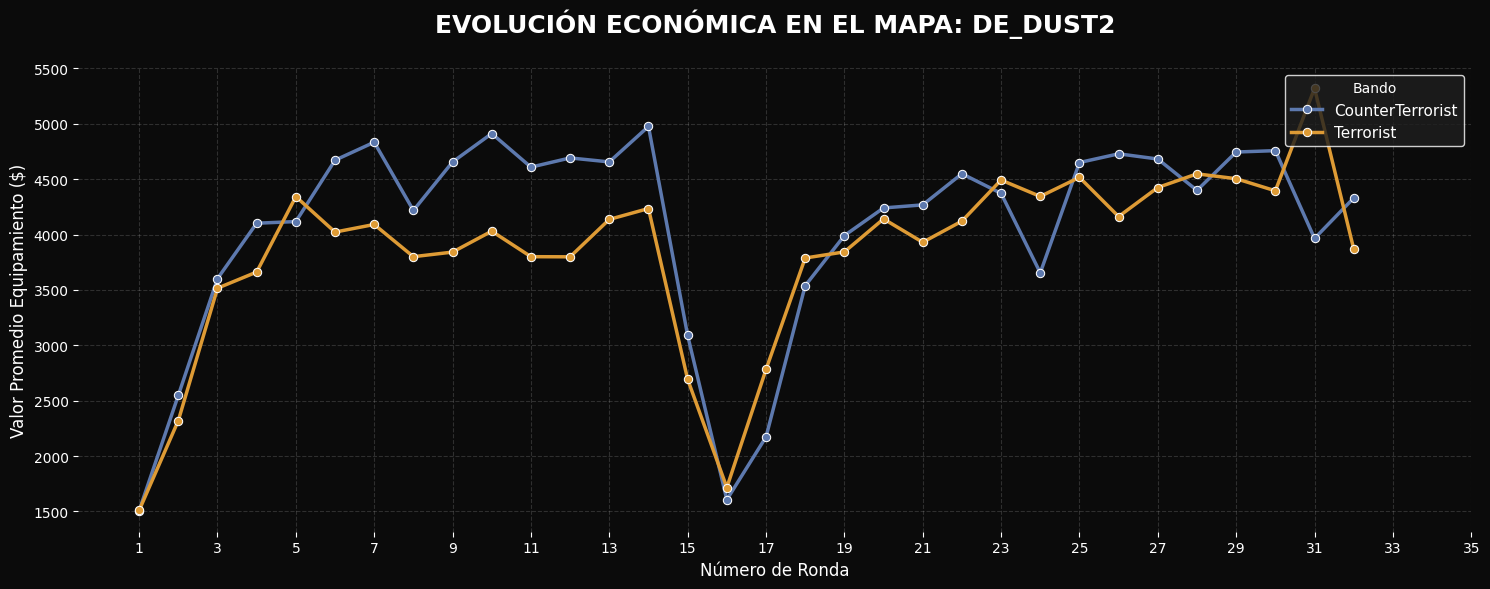

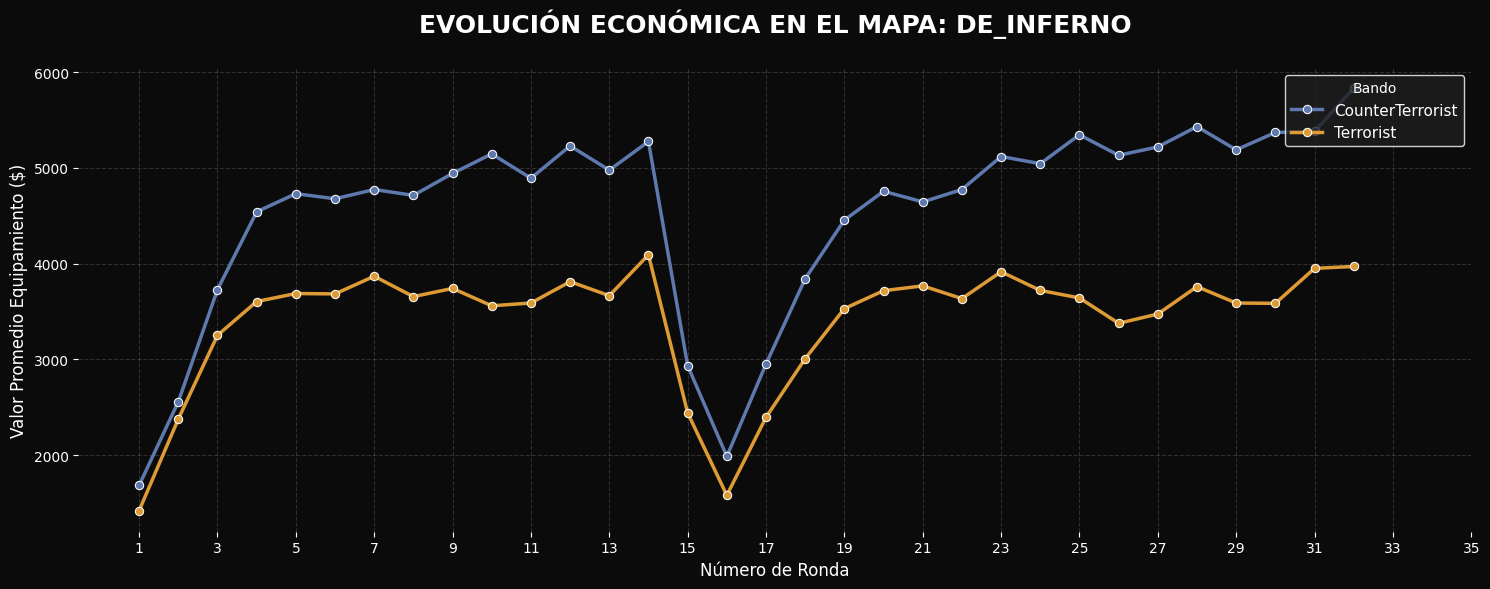

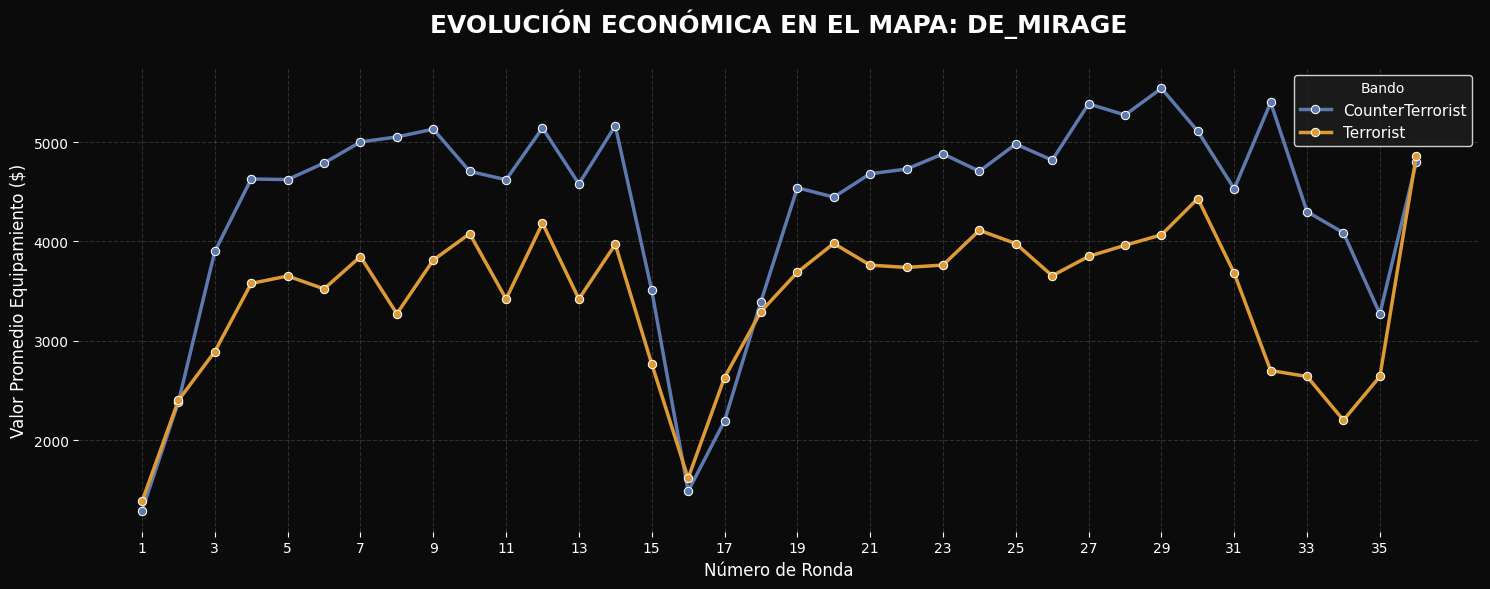

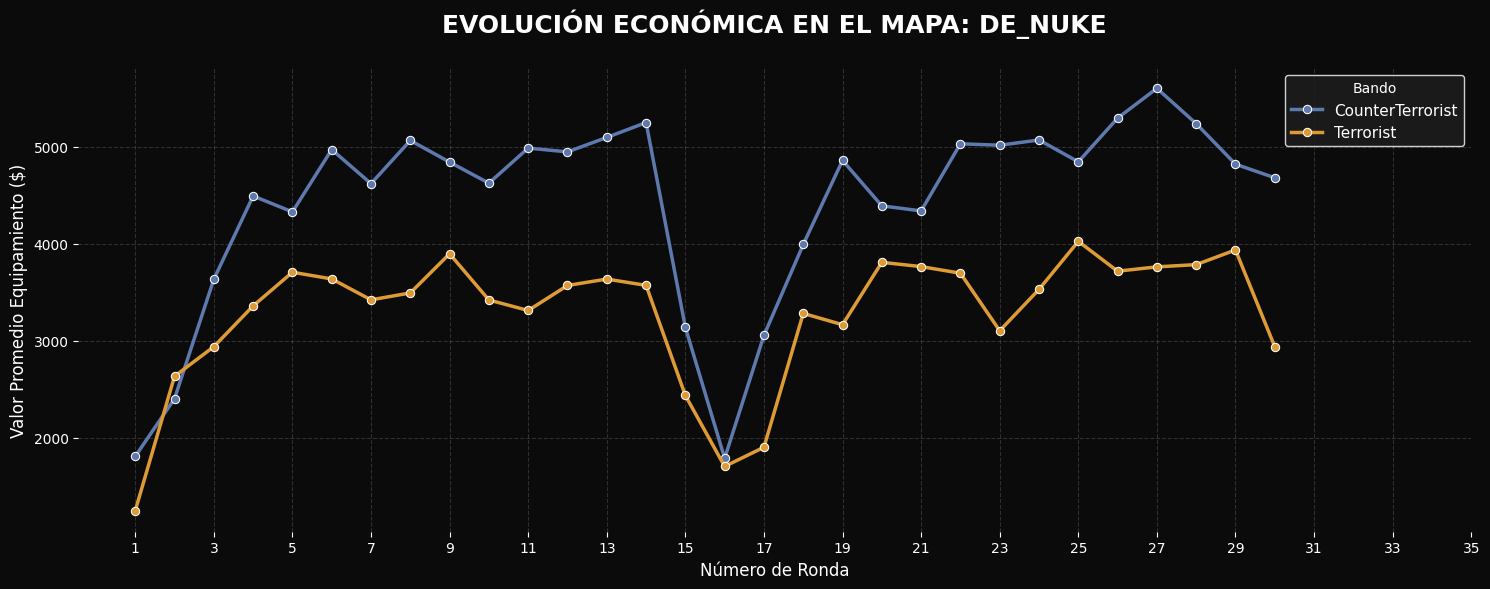

In [28]:
# Agrupamos por Mapa, Bando y Ronda para ver la tendencia económica detallada
eco_team_trend = df.groupby(['Map', 'RoundId', 'Team'], observed=False)['RoundStartingEquipmentValue'].mean().reset_index()

# Colores específicos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

plt.style.use('dark_background')

# Iteramos por cada mapa para crear gráficos independientes
for map_name in sorted(df['Map'].unique()):
    fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0b0b0b')
    ax.set_facecolor('#0b0b0b')

    subset_map = eco_team_trend[eco_team_trend['Map'] == map_name]

    # Graficamos una línea por cada bando (Team)
    sns.lineplot(data=subset_map, x='RoundId', y='RoundStartingEquipmentValue',
                 hue='Team', palette=team_colors, marker='o', linewidth=2.5, ax=ax)

    ax.set_title(f'EVOLUCIÓN ECONÓMICA EN EL MAPA: {map_name.upper()}', fontsize=18, fontweight='bold', color='#ffffff', pad=25)
    ax.set_xlabel('Número de Ronda', fontsize=12, color='white')
    ax.set_ylabel('Valor Promedio Equipamiento ($)', fontsize=12, color='white')

    # Ajuste de ticks para legibilidad
    unique_rounds = subset_map['RoundId'].unique()
    ax.set_xticks(unique_rounds[::2])
    plt.xticks(color='white')
    plt.yticks(color='white')

    ax.legend(title='Bando', facecolor='#1e1e1e', edgecolor='white', labelcolor='white', fontsize=11, loc='upper right')
    ax.grid(axis='both', linestyle='--', alpha=0.15)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

**Análisis comparativo del gráfico evolución economía por bando y cada mapa**

El análisis de la evolución del valor de equipamiento por bando permite identificar dinámicas económicas clave que influyen directamente en el resultado de las rondas.

* **Efecto acumulativo de la economía**: Se observa un comportamiento tipo bola de nieve, donde el bando que logra mantener una economía alta durante varias rondas consecutivas incrementa su ventaja, mientras el equipo rival entra en ciclos de baja inversión, este patrón indica que la economía tiene una fuerte dependencia temporal, lo que sugiere que el estado económico previo influye en el resultado actual.

* **Diferencias estructurales entre bandos**: En mapas como `de_dust2`, el bando `CounterTerrorist` requiere mantener un nivel de inversión mayor para ser competitivo, debido al mayor costo de su equipamiento, esto implica que el mismo valor absoluto de equipamiento puede tener impactos distintos según el bando, por lo que esta variable debe interpretarse en contexto.

* **Recuperación económica tras cambios de ronda**: En mapas como `de_mirage`, ambos bandos muestran una recuperación económica similar tras eventos clave (como el cambio de lado), lo que refleja un comportamiento más equilibrado, en otros mapas, uno de los bandos logra recuperar ventaja más rápidamente, generando diferencias sostenidas en el tiempo.

* **Zonas de inversión media**: Se identifican rangos donde ambos equipos convergen en valores intermedios de equipamiento, lo que corresponde a decisiones de inversión forzada, estas situaciones representan escenarios de alta incertidumbre, donde el resultado de la ronda puede romper la dinámica económica previa.

Para el modelo predictivo, los resultados indican que el valor absoluto de equipamiento no es suficiente para explicar el resultado de la ronda, en cambio, el diferencial económico entre equipos `Delta_EquipmentValue` se posiciona como una variable más representativa, ya que captura la ventaja relativa en cada enfrentamiento, por ello, se podria llegar a considerar su incorporación en el modelo, junto con el contexto de bando y mapa, para mejorar la capacidad predictiva.

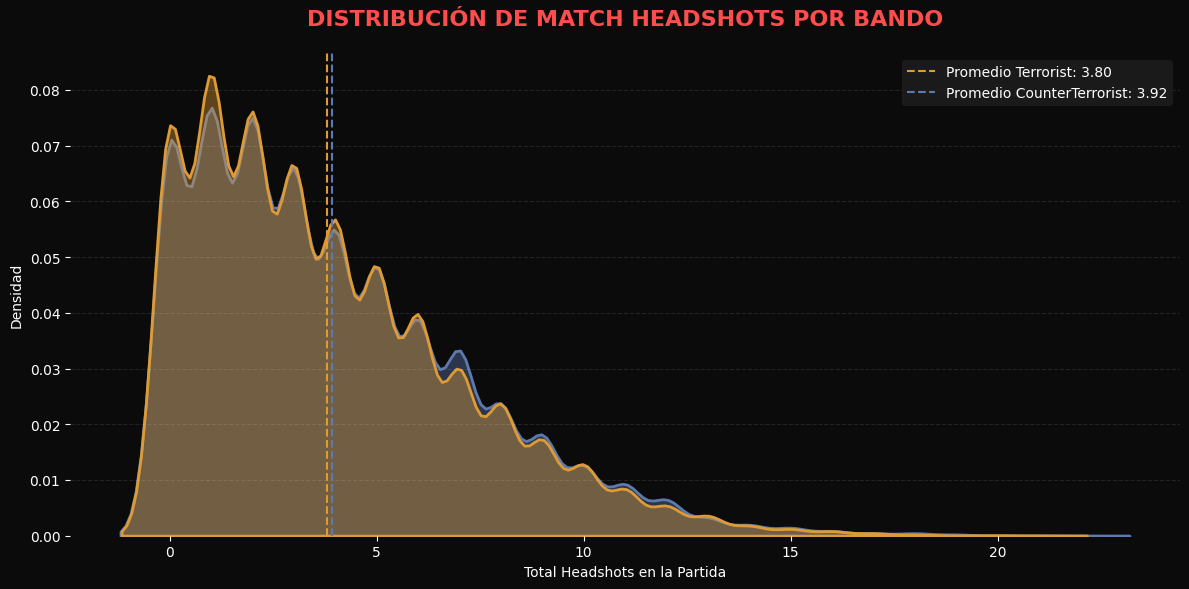

In [29]:
plt.figure(figsize=(12, 6), facecolor='#0b0b0b')
ax = plt.gca()
ax.set_facecolor('#0b0b0b')

# Colores temáticos para los bandos
team_colors = {'Terrorist': '#de9b35', 'CounterTerrorist': '#5d79ae'}

# Crear el gráfico de densidad (KDE) comparativo
sns.kdeplot(data=df, x='MatchHeadshots', hue='Team', palette=team_colors, fill=True, alpha=0.4, linewidth=2)

# Añadir líneas de promedio para cada bando
for team, color in team_colors.items():
    avg_val = df[df['Team'] == team]['MatchHeadshots'].mean()
    plt.axvline(avg_val, color=color, linestyle='--', label=f'Promedio {team}: {avg_val:.2f}')

plt.title('DISTRIBUCIÓN DE MATCH HEADSHOTS POR BANDO', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
plt.xlabel('Total Headshots en la Partida', color='white')
plt.ylabel('Densidad', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

for spine in ax.spines.values():
    spine.set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

**Análisis del gráfico distribución de Match Headshots por bando**

El análisis de la distribución de headshots acumulados por partida `MatchHeadshots` permite evaluar posibles diferencias en la precisión entre bandos.

* **Simetría entre equipos**: Las distribuciones de ambos bandos presentan formas muy similares, con promedios cercanos (3.80 para **Terrorist** y 3.92 para **CounterTerrorist**), esto indica que no existen diferencias significativas en la cantidad de *headshots* según el bando, sugiriendo un comportamiento homogéneo en términos de precisión.

* **Concentración en valores bajos**: La mayoría de los jugadores se concentra en un rango de 0 a 5 *headshots* por partida, mientras que los valores más altos son poco frecuentes, esto indica que los headshots, aunque relevantes, no son eventos dominantes en la distribución general del desempeño.

* **Variabilidad limitada por bando**: Dado que no se observan diferencias claras entre equipos, la variable `MatchHeadshots` no parece estar influenciada directamente por el rol (ataque o defensa), sino por factores individuales o situacionales.

Conclusión,  los resultados sugieren que `MatchHeadshots` no presenta diferencias relevantes entre bandos, por lo que su valor predictivo no estaría asociado al equipo en sí, sino a su relación con otras métricas de desempeño, por esta razón, su mayor utilidad en el modelo podría encontrarse al combinarse con variables como `MatchKills`, permitiendo capturar de mejor forma la eficiencia en los enfrentamientos.

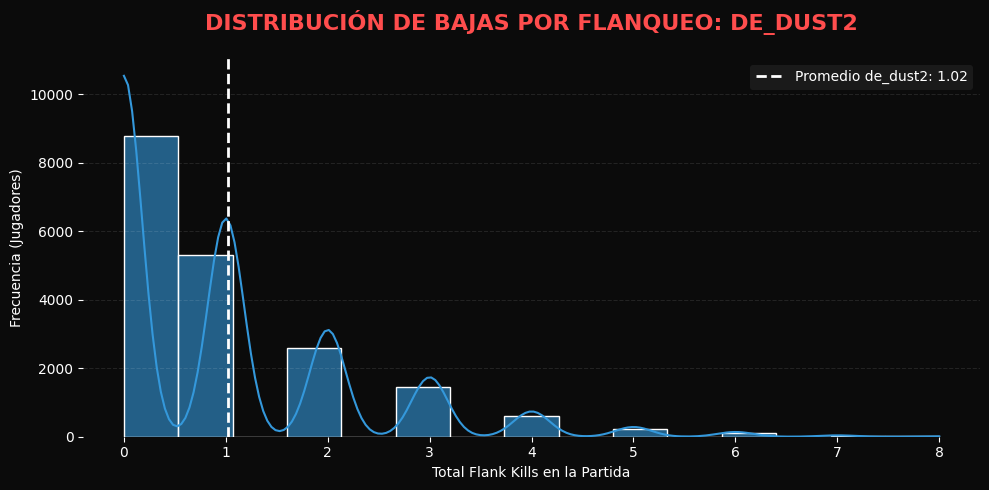

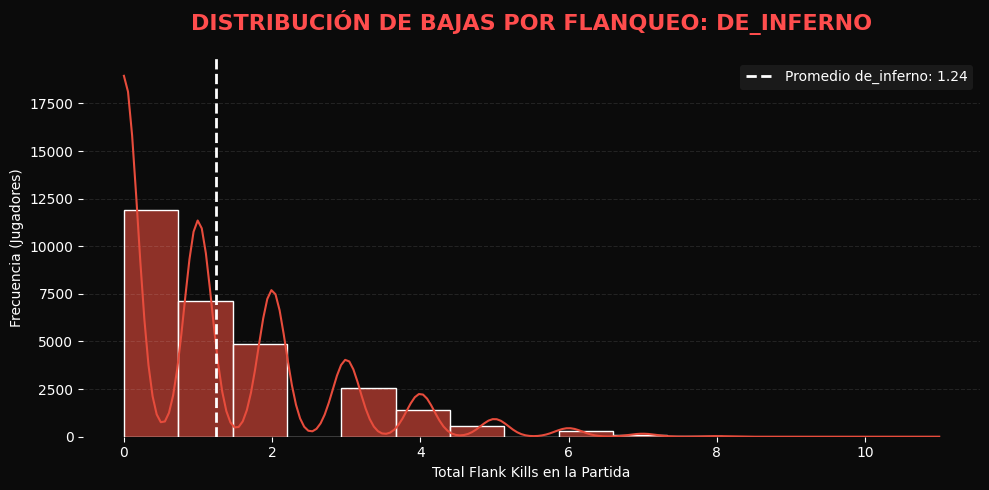

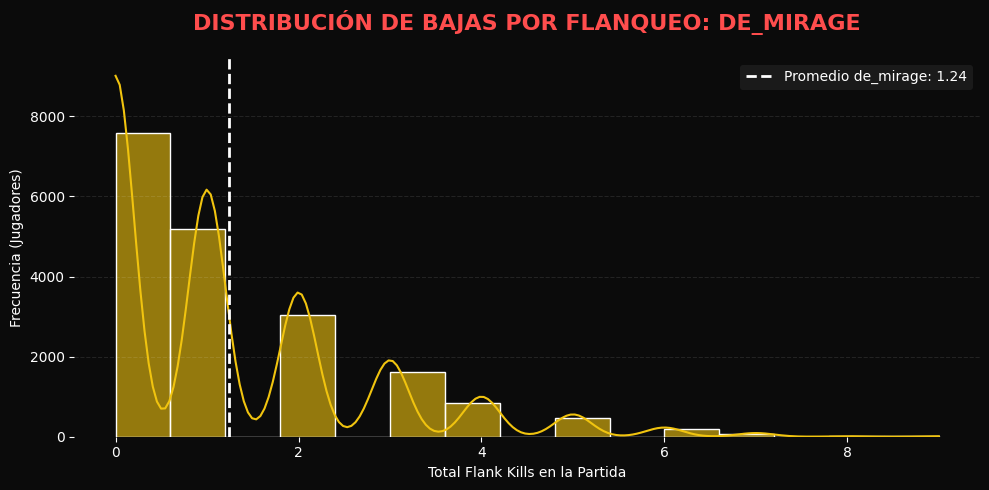

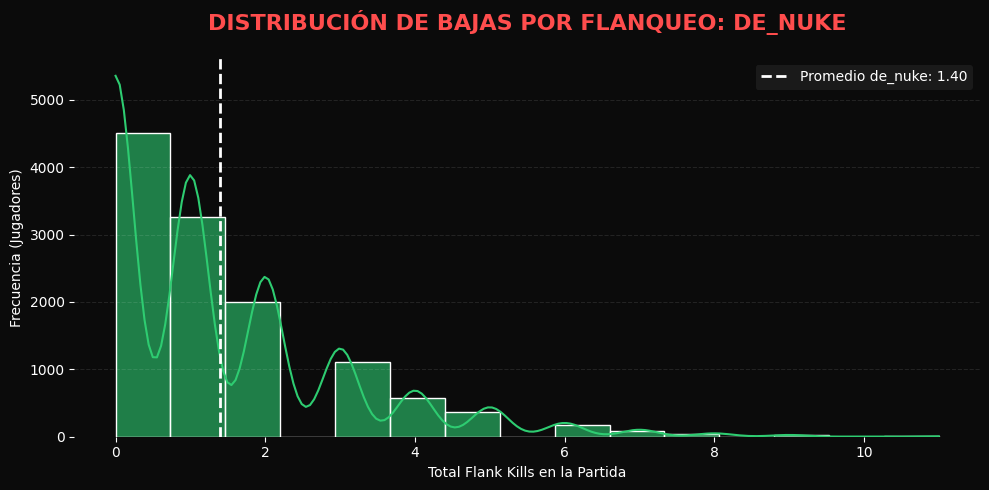

In [30]:
# Análisis de bajas por flanqueo detallado por cada mapa
maps_list = sorted(df['Map'].unique())
map_colors_list = ['#3498db', '#e74c3c', '#f1c40f', '#2ecc71']

for i, mapa in enumerate(maps_list):
    plt.figure(figsize=(10, 5), facecolor='#0b0b0b')
    ax = plt.gca()
    ax.set_facecolor('#0b0b0b')

    # Filtrar datos por mapa
    df_mapa = df[df['Map'] == mapa]

    # Crear el histograma
    sns.histplot(df_mapa['MatchFlankKills'], bins=15, kde=True,
                 color=map_colors_list[i % len(map_colors_list)],
                 alpha=0.6, edgecolor='white')

    # Añadir línea de promedio
    avg_flank = df_mapa['MatchFlankKills'].mean()
    plt.axvline(avg_flank, color='white', linestyle='--', linewidth=2,
                label=f'Promedio {mapa}: {avg_flank:.2f}')

    plt.title(f'DISTRIBUCIÓN DE BAJAS POR FLANQUEO: {mapa.upper()}', fontsize=16, fontweight='bold', color='#ff4d4d', pad=20)
    plt.xlabel('Total Flank Kills en la Partida', color='white')
    plt.ylabel('Frecuencia (Jugadores)', color='white')
    plt.xticks(color='white')
    plt.yticks(color='white')
    plt.legend(facecolor='#1e1e1e', edgecolor='none', labelcolor='white')

    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.1)

    plt.tight_layout()
    plt.show()

**Análisis del gráfico distribución de bajas por flanqueo (Match Flank Kills) por Mapa**

El análisis de la distribución de bajas por flanqueo permite evaluar la frecuencia y relevancia de este tipo de jugadas dentro del desempeño general.

* **Un promedio bajo**: En todos los mapas, el promedio de `MatchFlankKills` se mantiene bajo (1.21), lo que indica que este tipo de acciones son poco frecuentes en comparación con otras métricas de desempeño, esto sugiere que su impacto global en el dataset es limitado.

* **Concentración en valores bajos**: La mayoría de los jugadores se ubica en el rango de 0 a 2 bajas por flanqueo, lo que confirma que estas situaciones ocurren en contextos específicos y no representan el comportamiento estándar del juego.

* **Presencia de valores extremos**: Se observa una cola derecha en la distribución, con casos que superan las 5 bajas por flanqueo, estos registros reflejan situaciones particulares y deben ser conservados, aunque su baja frecuencia limita su influencia en el modelo.

* **Variación según el mapa**: Mapas como `de_inferno` y `de_nuke` presentan una mayor dispersión en comparación con otros escenarios, lo que sugiere que ciertas configuraciones de mapa pueden favorecer este tipo de jugadas, sin embargo, estas diferencias no son lo suficientemente consistentes como para generar patrones dominantes.

En conclusión, `MatchFlankKills` representa un comportamiento específico y poco frecuente, por lo que su capacidad predictiva individual es limitada, no obstante, podría aportar valor como variable complementaria, especialmente al combinarse con otras métricas de desempeño o contexto, por ello, su inclusión en el modelo debe evaluarse en función de su contribución real al desempeño predictivo.

### 2.6 Relación entre variables

#### 2.6.1 Correlaciones entre variables numéricas


In [31]:
df['RoundWinner_num'] = df['RoundWinner'].map({
    'True': 1,
    'False': 0
})

df[['RoundKills', 'RoundWinner_num']].corr(method='pearson')

,RoundKills,RoundWinner_num
RoundKills,1.000000,-0.269225
RoundWinner_num,-0.269225,1.000000


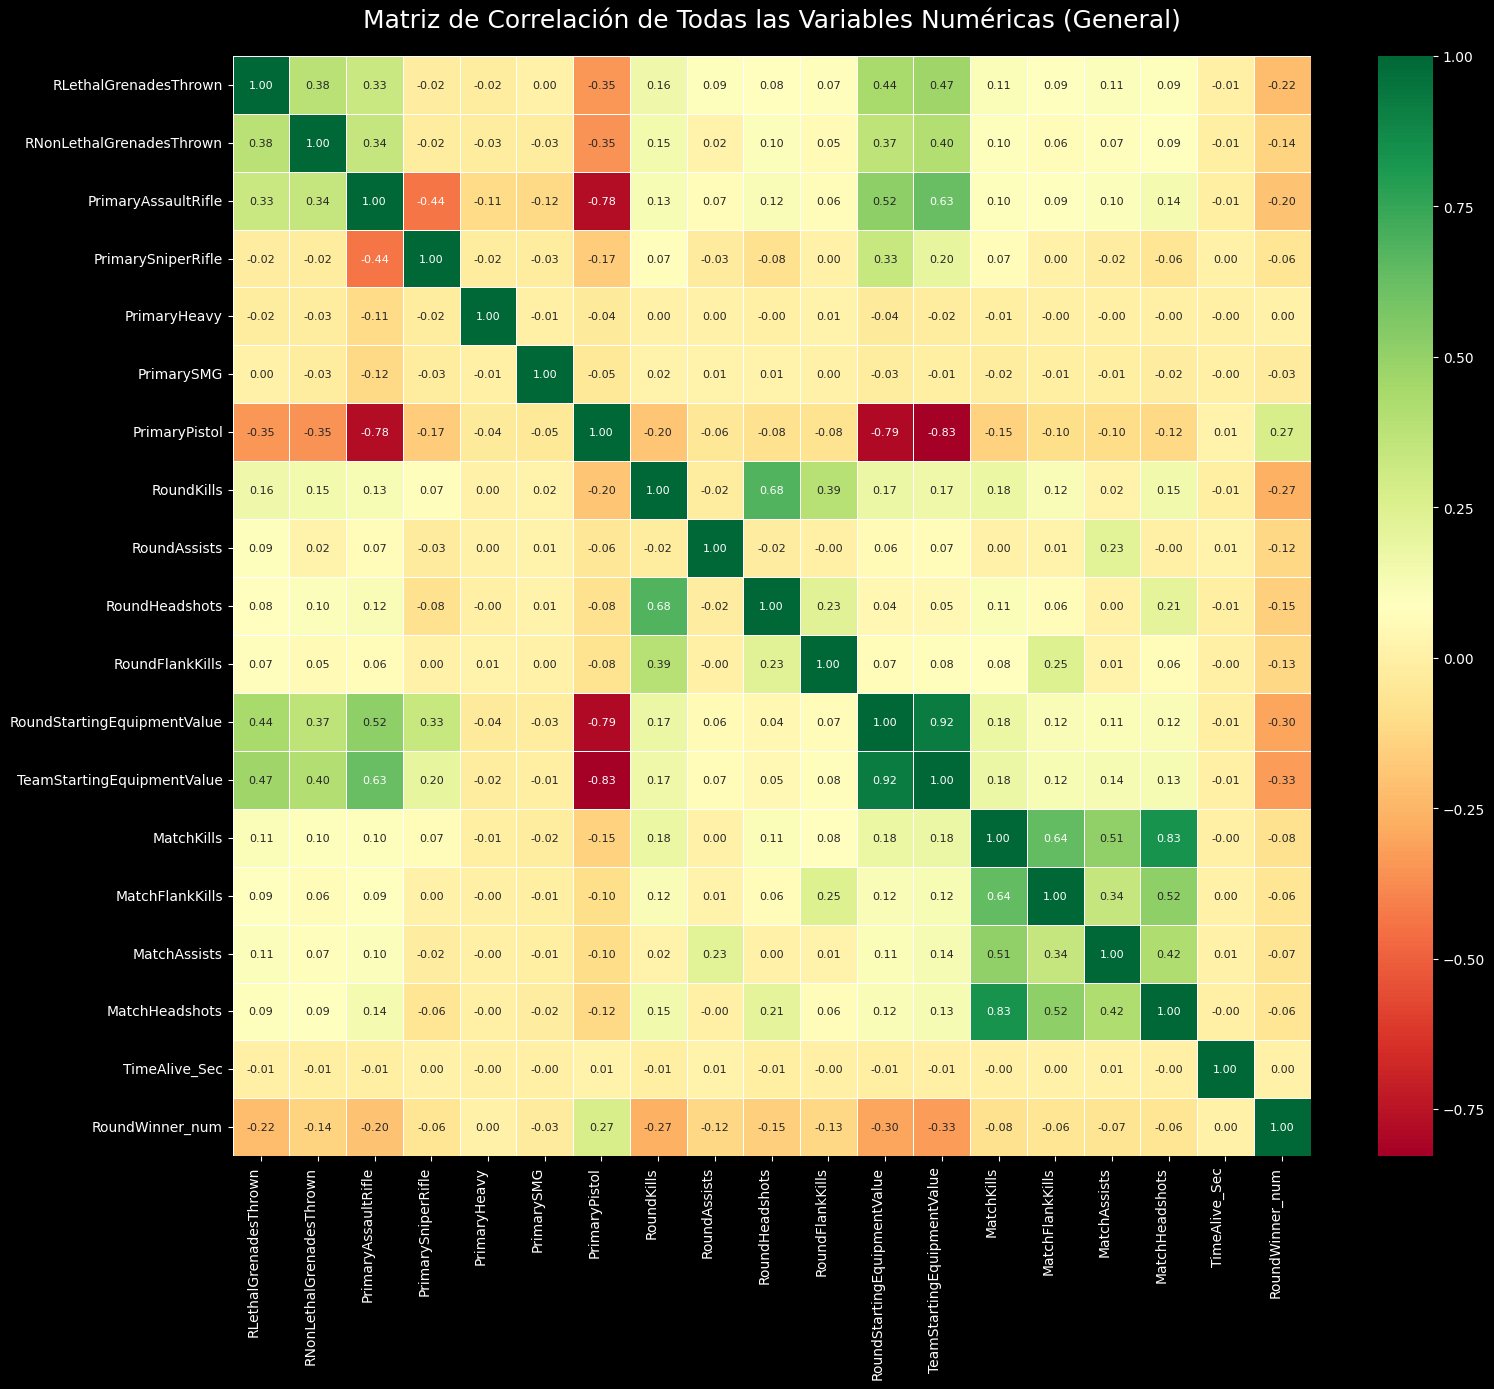

In [32]:
numerical_df = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación para todas las variables numéricas
corr_matrix_all = numerical_df.corr()

# Visualización mediante un mapa de calor
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_all, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5, annot_kws={"size": 8})
plt.title('Matriz de Correlación de Todas las Variables Numéricas (General)', size=18, pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Análisis de la Matriz de Correlación (General)**

El análisis de la matriz de correlación permite identificar relaciones lineales entre variables y evaluar su utilidad dentro del modelo predictivo.

* **Redundancia en variables económicas**: Se observa una correlación alta (0.91) entre el valor de equipamiento individual y grupal, lo que indica una fuerte dependencia entre ambas, esto sugiere que ambas variables contienen información similar, por lo que es posible utilizar solo una de ellas (preferentemente la grupal) para reducir redundancia sin pérdida significativa de información.

* **Relaciones entre tipos de armamento:** Existe una correlación negativa entre el uso de rifles de asalto y pistolas (-0.75), lo que refleja patrones de compra excluyentes asociados a distintos estados económicos, asimismo, se observa una correlación negativa moderada entre rifles de asalto y francotiradores, lo que sugiere una distribución de roles dentro del equipo.

* **Uso de utilidad:** Las variables de granadas letales y no letales presentan una correlación positiva moderada (0.38), lo que indica que suelen utilizarse de forma conjunta, además, se observa una relación positiva con el tiempo de supervivencia, lo que sugiere que el uso de utilidad podría estar asociado a una mayor duración en la ronda.

* **Métricas de desempeño individual:** Los headshots presentan correlación positiva con variables de desempeño como kills, lo que es esperable dado que forman parte del mismo evento, en cambio, variables como `MatchFlankKills` muestran menor correlación con otras métricas, lo que sugiere que capturan comportamientos más específicos.

* **Relación con la variable objetivo:** Se observa que variables de desempeño acumulado (como kills) presentan mayor correlación con el resultado en etapas avanzadas, lo que indica que su capacidad explicativa puede variar a lo largo del desarrollo de la partida.

En resumen, la matriz de correlación permite identificar variables redundantes, relaciones estructurales entre características y posibles dependencias entre variables explicativas, estos resultados son fundamentales para la selección de variables, ya que permiten reducir dimensionalidad, evitar multicolinealidad y priorizar aquellas variables con mayor aporte al modelo. En este contexto, se recomienda:

 * Reducir variables altamente correlacionadas
 * Priorizar variables de contexto (economía, mapa, equipo)
 * Evaluar variables de baja correlación como posibles complementos

Se presenta otra matriz de correlación por mapa, ya que, en CS los jugadores pueden elegir dónde jugar, y eso cambia todo, la forma de jugar, las estrategias económicas y por supuesto las correlaciones entre variables, **lo que funciona en `Inferno` no necesariamente funciona en `Dust2`**.


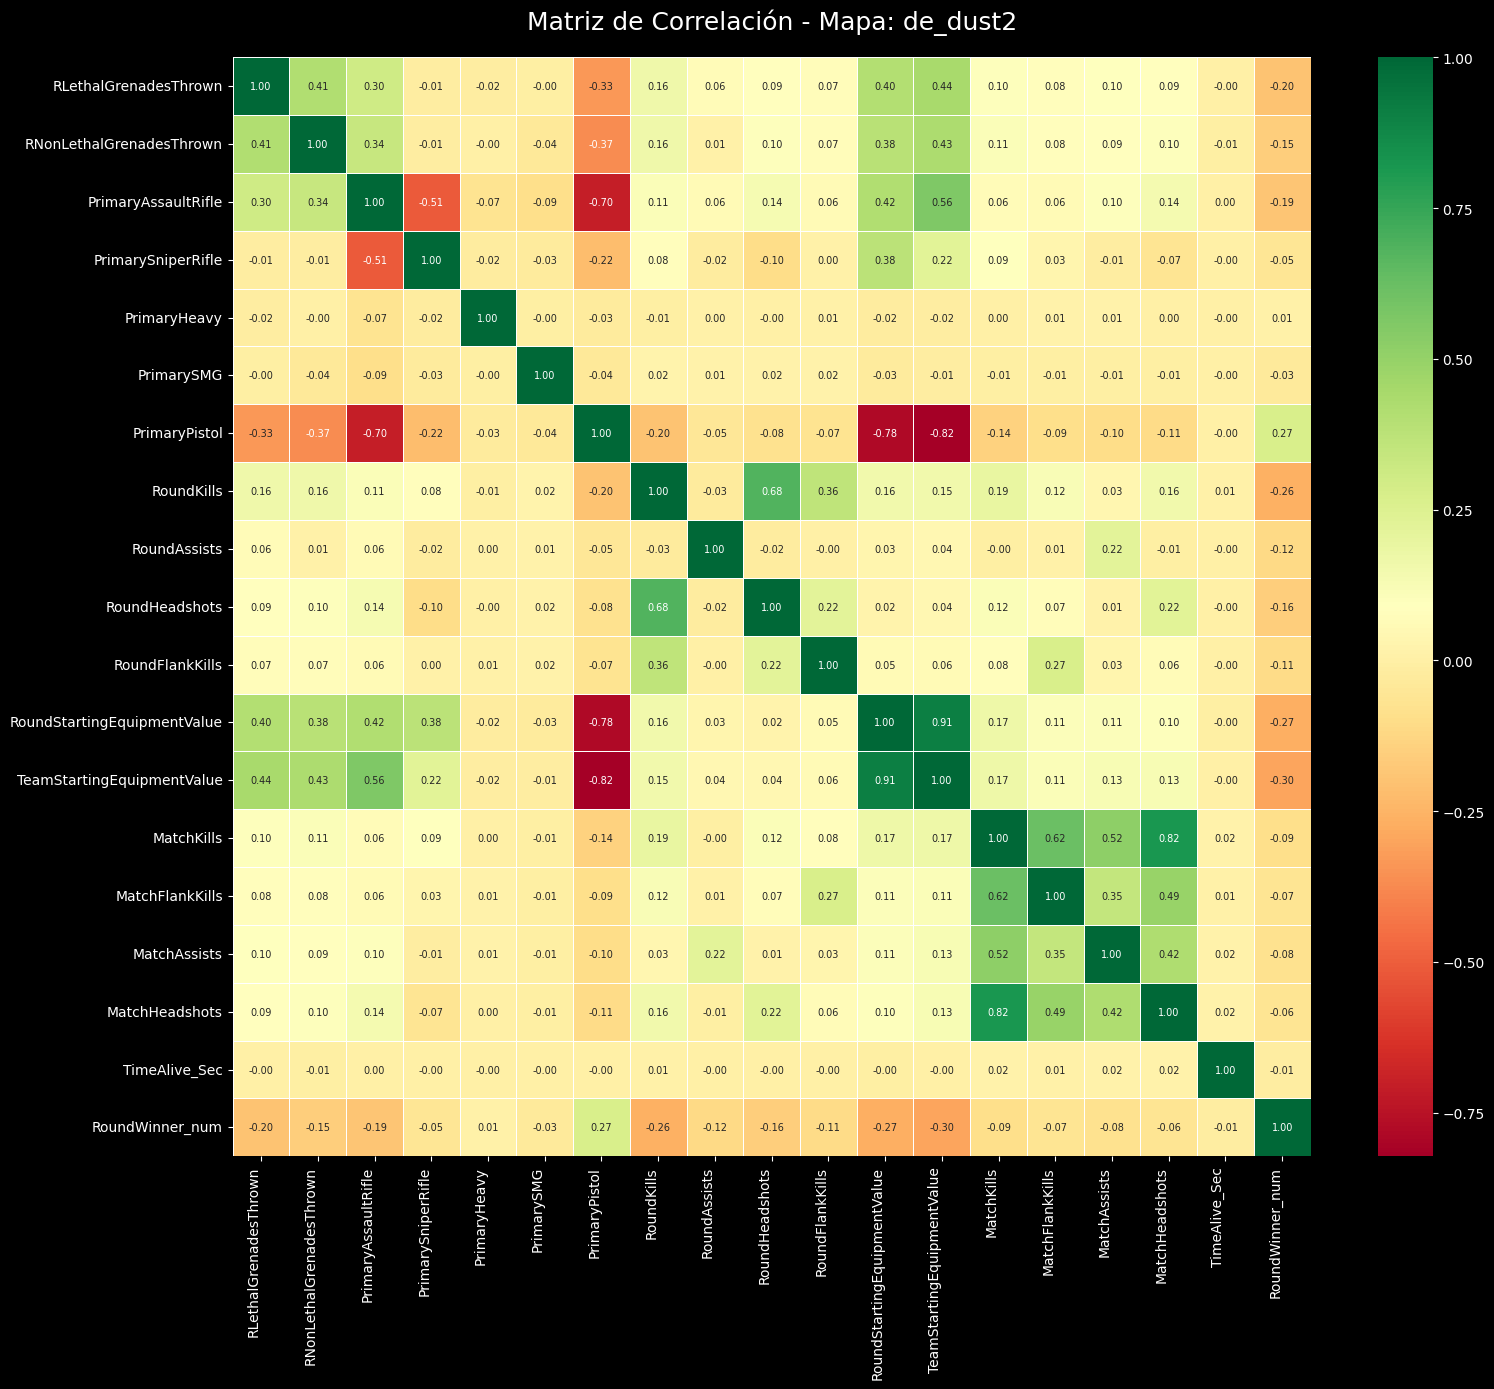

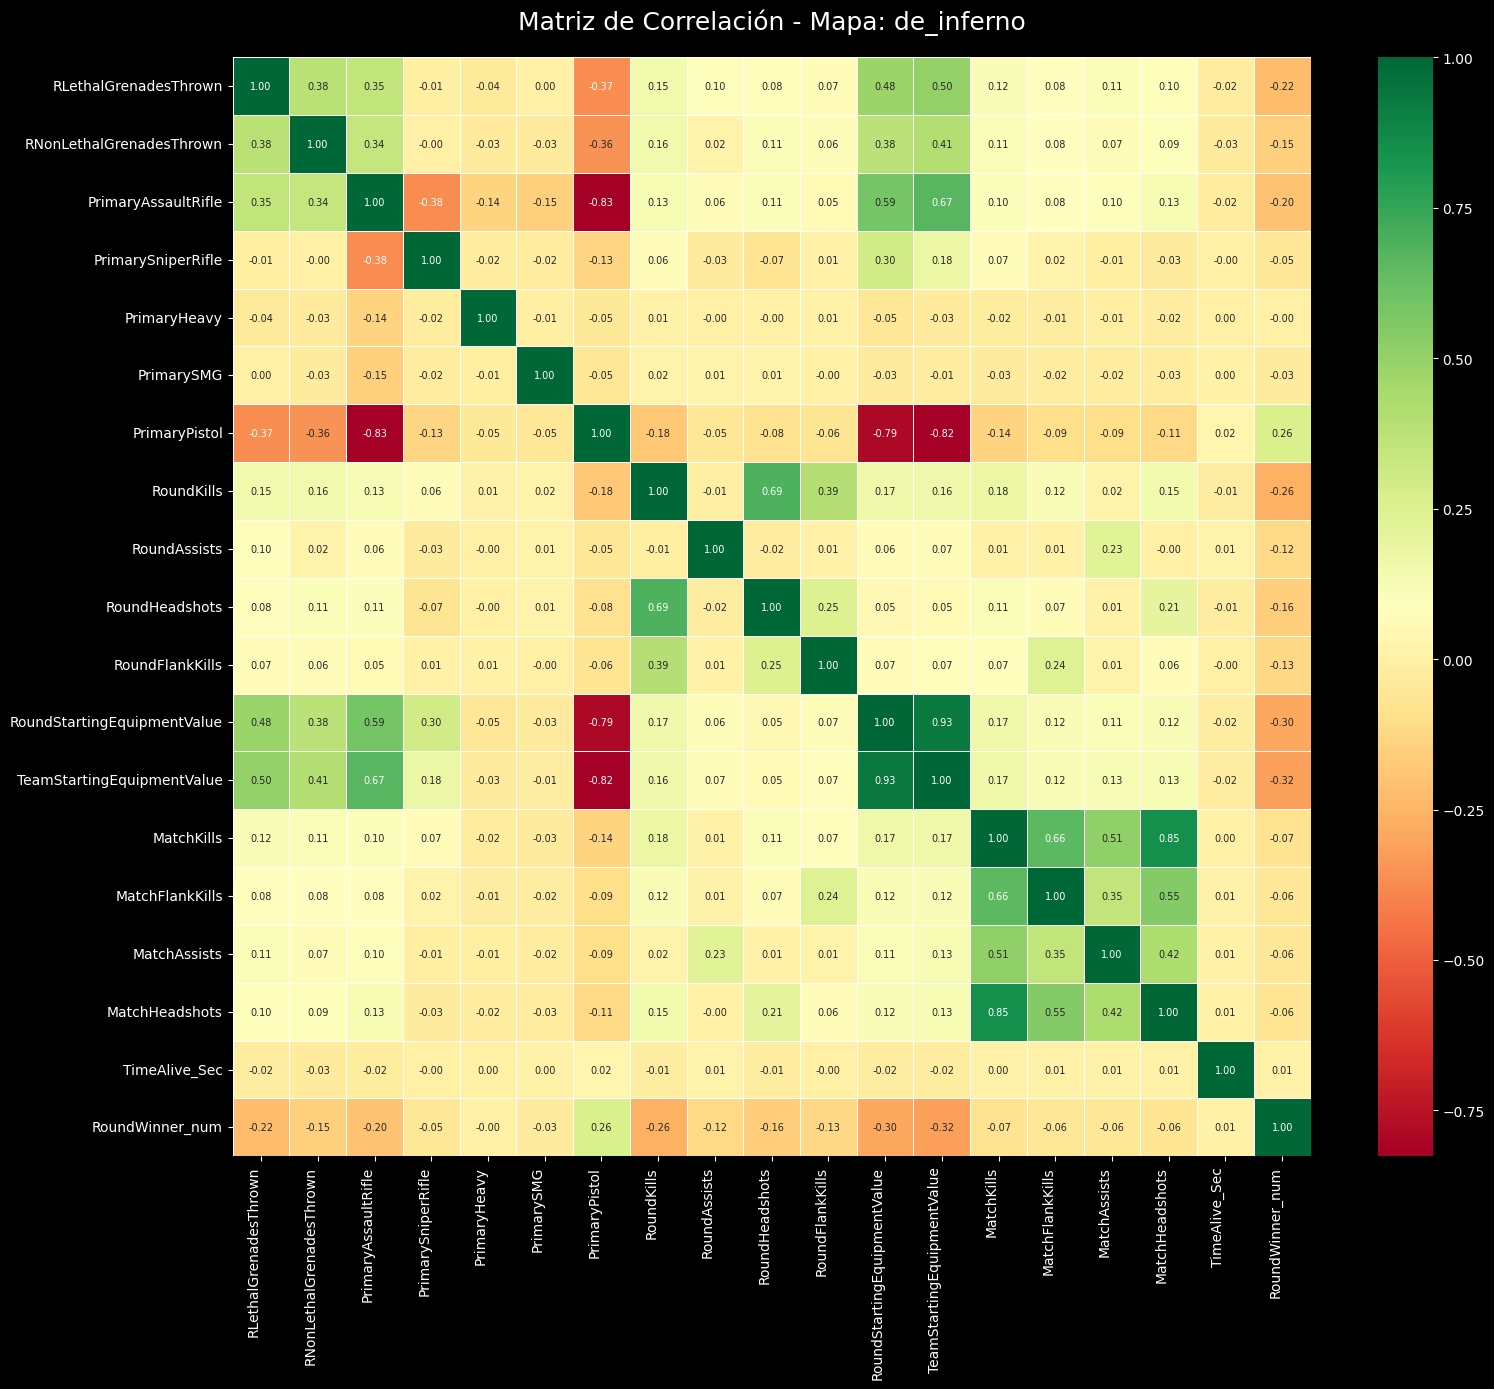

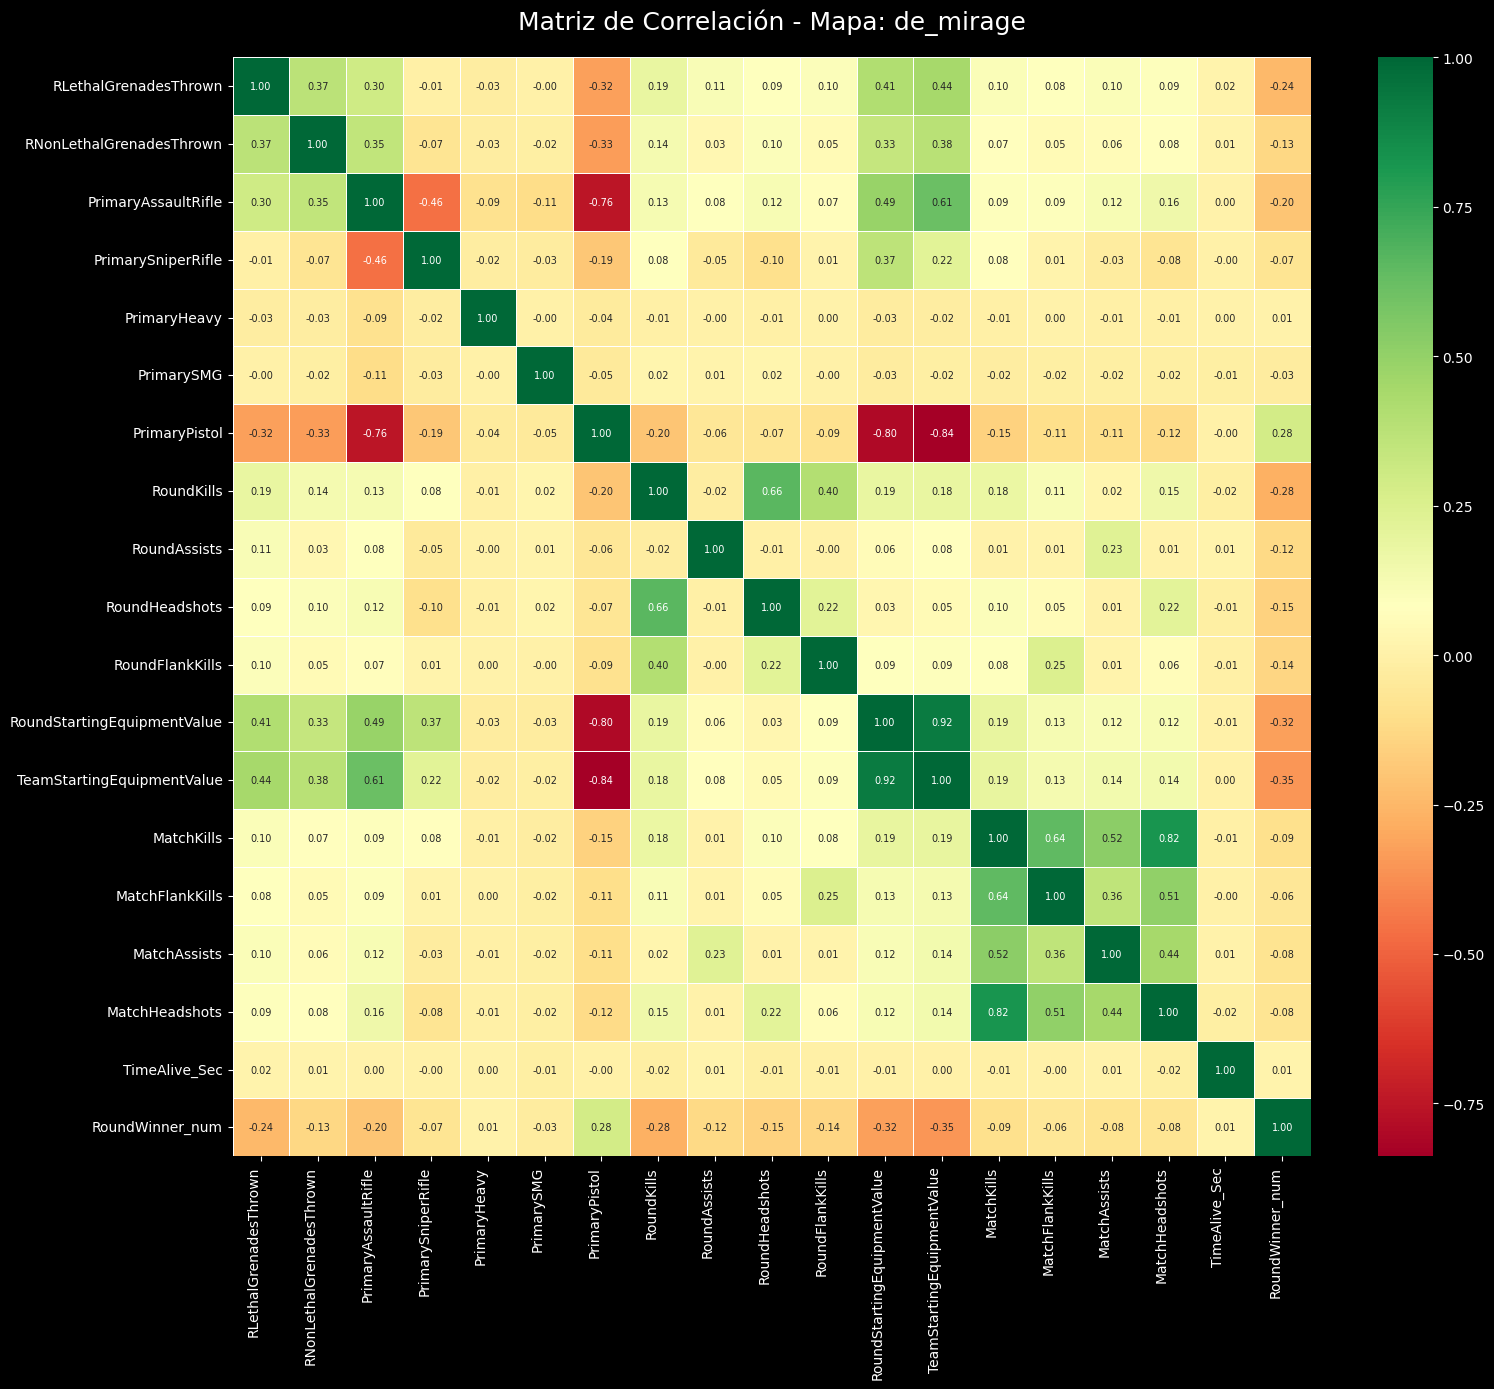

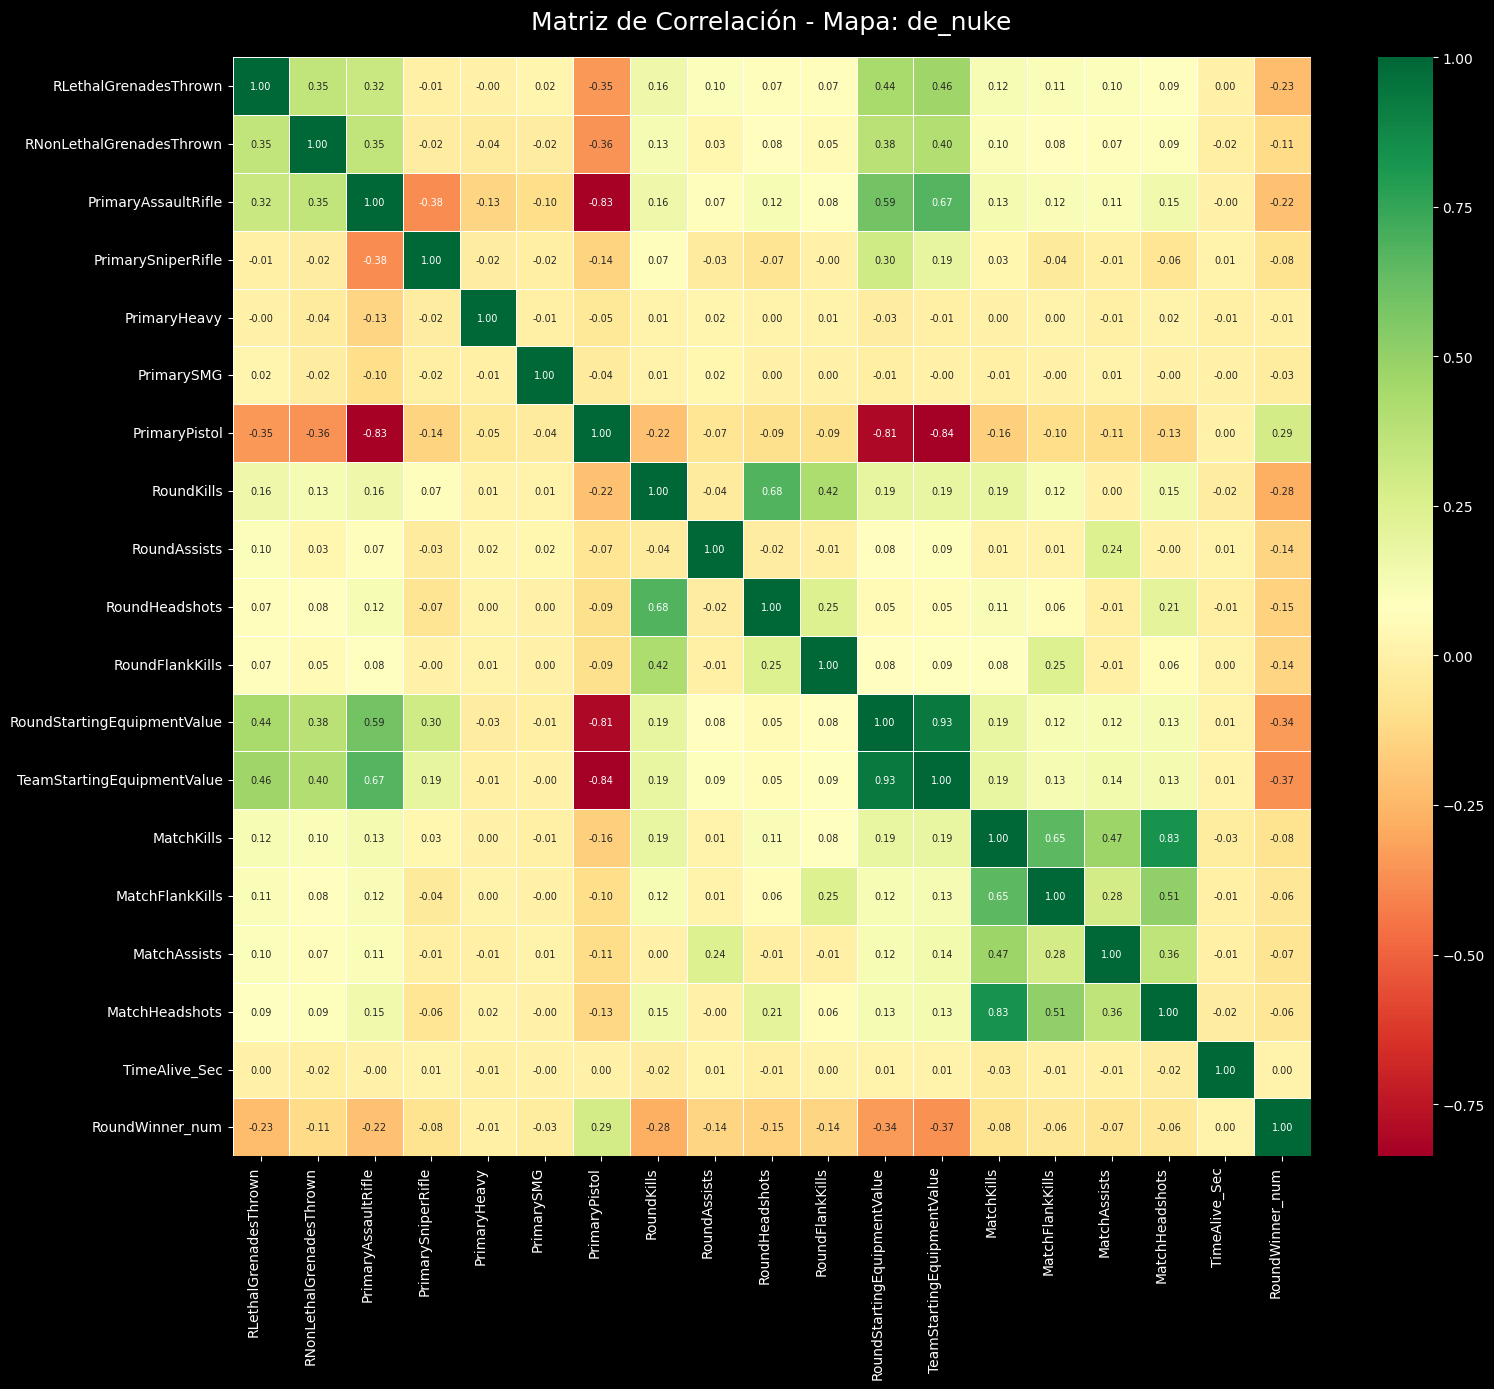

In [33]:
for mapa, df_mapa in df.groupby("Map"):

    numerical_df = df_mapa.select_dtypes(include=[np.number])

    if numerical_df.shape[1] < 2:
        continue

    corr_matrix = numerical_df.corr()

    plt.figure(figsize=(16, 14))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='RdYlGn',
        fmt='.2f',
        linewidths=0.5,
        annot_kws={"size": 7}
    )

    plt.title(f'Matriz de Correlación - Mapa: {mapa}', size=18, pad=20)
    plt.xticks(rotation=90, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Análisis de la Matriz de Correlación por mapa**

El análisis de las matrices de correlación por mapa permite identificar patrones consistentes en la relación entre variables, así como diferencias en la intensidad de estas relaciones según el contexto.

* **Variables identificadoras:** Las variables `MatchId`, `InternalTeamId` y `Unnamed`, no presentan correlaciones relevantes con otras variables del dataset, dado su carácter técnico, se recomienda excluirlas del modelado, ya que no aportan capacidad explicativa.

* **Estructura económica:** Se observa una correlación alta (≥0.90) entre `RoundStartingEquipmentValue` y `TeamStartingEquipmentValue` en todos los mapas, esta relación indica redundancia entre ambas variables, por lo que su uso conjunto podría generar problemas de multicolinealidad, en este contexto, se recomienda seleccionar solo una de ellas para representar la dimensión económica.

* **Patrones de armamento:** La correlación negativa entre `PrimaryPistol` y `PrimaryAssaultRifle` confirma la existencia de patrones de compra excluyentes, asociados a distintos estados económicos del equipo, esto refuerza la idea de que el tipo de arma puede actuar como un proxy del estado económico.

* Métricas de desempeño: Las variables de desempeño individual, como `RoundKills`, `MatchKills`, `RoundHeadshots` y `MatchHeadshots`, presentan correlaciones positivas entre sí, lo que indica que capturan dimensiones relacionadas del rendimiento del jugador, sin embargo, esta relación también sugiere posible redundancia parcial, por lo que su inclusión en el modelo debe evaluarse cuidadosamente.

* **Uso de utilidad táctica:** El uso de granadas (letales y no letales) muestra correlaciones moderadas con variables económicas, lo que indica que su utilización está condicionada por la disponibilidad de recursos, asimismo, estas variables pueden reflejar aspectos tácticos del juego, aunque su impacto directo debe analizarse en conjunto con otras características.

En conclusión, las matrices de correlación evidencian una estructura coherente entre economía, armamento y desempeño, donde la economía condiciona la selección de recursos y estas decisiones impactan en el rendimiento dentro de la ronda, desde la perspectiva del modelado, estos resultados permiten definir criterios claros de selección de variables:

* Eliminación de variables sin valor explicativo
* Reducción de variables altamente correlacionadas
* Priorización de variables representativas de cada dimensión (economía, desempeño y contexto)

Esto contribuye a construir un modelo más eficiente, reduciendo redundancia y mejorando su capacidad de generalización.

#### 2.6.2 Visualizaciones adicionales


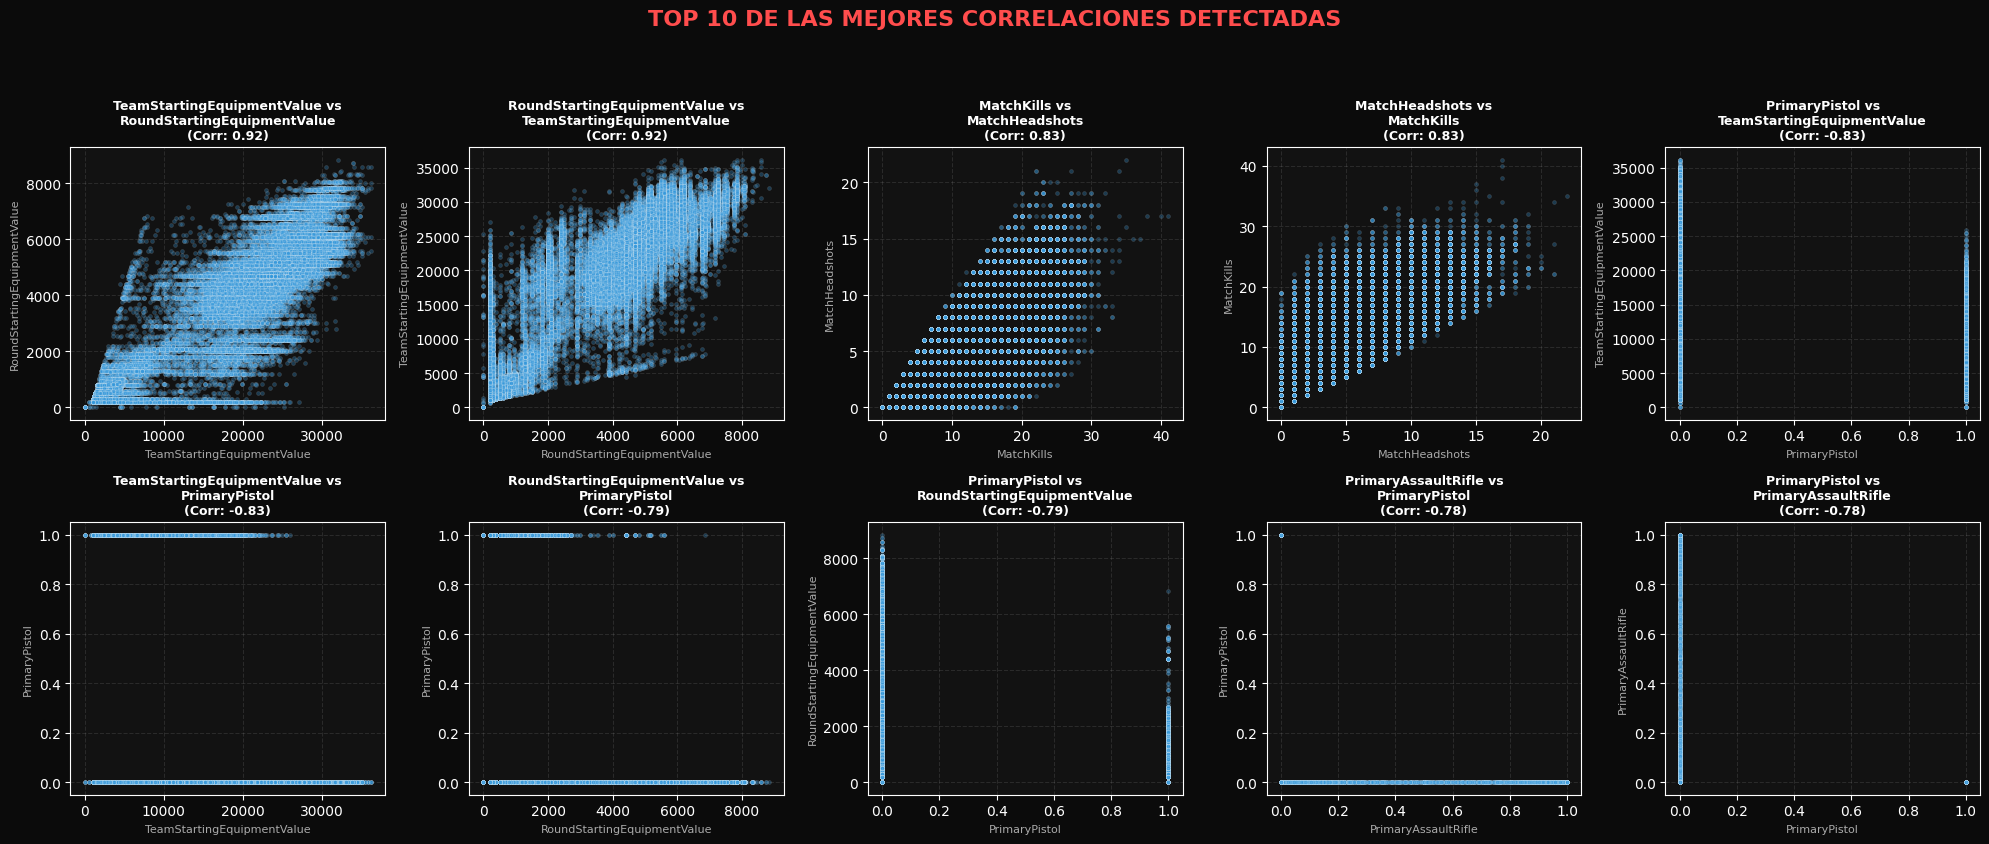

In [34]:
# 1. Calcular matriz de correlación general
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 2. Obtener los pares con mayor correlación absoluta
# Desapilamos y ordenamos por valor absoluto para encontrar las 'mejores'
corr_pairs = corr_matrix.unstack()
df_corr = corr_pairs.to_frame('Correlation').reset_index()
df_corr.columns = ['Variable1', 'Variable2', 'Correlation']

# Filtrar correlaciones perfectas (1.0) y duplicados (A-B vs B-A)
df_corr = df_corr[df_corr['Variable1'] != df_corr['Variable2']]
df_corr['abs_correlation'] = df_corr['Correlation'].abs()

# Seleccionar el TOP 10 de las mejores correlaciones (las más fuertes)
df_better_corr = df_corr.sort_values(by='abs_correlation', ascending=False).head(10)

# 3. Graficar en matriz de 5 columnas
plt.style.use('dark_background')
n = len(df_better_corr)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), facecolor='#0b0b0b')
axes = axes.flatten()

for i, row in enumerate(df_better_corr.itertuples(index=False)):
    x_var = row.Variable1
    y_var = row.Variable2

    sns.scatterplot(data=df, x=x_var, y=y_var, alpha=0.3, ax=axes[i], color='#3498db', s=8)
    axes[i].set_facecolor('#121212')
    axes[i].set_title(f'{x_var} vs\n{y_var}\n(Corr: {row.Correlation:.2f})', fontsize=9, fontweight='bold', color='white')
    axes[i].set_xlabel(x_var, fontsize=8, color='#aaaaaa')
    axes[i].set_ylabel(y_var, fontsize=8, color='#aaaaaa')
    axes[i].grid(True, linestyle='--', alpha=0.1)

# Eliminar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('TOP 10 DE LAS MEJORES CORRELACIONES DETECTADAS', fontsize=16, weight="bold", color='#ff4d4d', y=1.05)
plt.tight_layout()
plt.show()

**Análisis de gráficos de dispersión (Top 10 Correlaciones Detectadas)**

El análisis de las relaciones con mayor coeficiente de correlación permite identificar dependencias estructurales entre variables y su impacto en el modelado.

* **Relación entre variables económicas**: La relación entre `RoundStartingEquipmentValue` y `TeamStartingEquipmentValue` presenta una correlación de aproximadamente **0.92**, indicando una fuerte sincronización en las decisiones de compra dentro del equipo, esto evidencia redundancia entre ambas variables y sugiere la necesidad de seleccionar solo una para evitar multicolinealidad.

* **Relación inversa entre pistolas y equipamiento:** Se observa una correlación negativa fuerte (-0.83) entre el uso de `PrimaryPistol` y el valor del equipamiento, reflejando distintos estados económicos del equipo, esto indica que el tipo de arma puede actuar como un indicador indirecto del nivel de inversión.

* **Relación entre economía y armamento principal**: A medida que aumenta el valor del equipamiento, se incrementa la presencia de rifles de asalto (0.63), lo que sugiere que estas armas están asociadas a escenarios de mayor inversión, esto refuerza su rol como indicador del estado económico del equipo.

* **Relación entre métricas de desempeño**: Variables como `MatchKills` y `MatchHeadshots` presentan una correlación positiva alta (0.83), lo que indica que ambas capturan aspectos relacionados del rendimiento del jugador, esta relación sugiere posible redundancia parcial, por lo que su inclusión debe evaluarse en función del modelo.

* **Relación entre economía y supervivencia**: Se observa una tendencia donde mayores niveles de equipamiento se asocian con un incremento en `TimeAlive`, lo que sugiere que la disponibilidad de recursos puede influir en la duración de la participación en la ronda.

En conclusión, estos análisis confirman la existencia de relaciones estructurales entre variables económicas, de armamento y de desempeño. Desde la perspectiva del modelado, estos resultados permiten:

* Identificar y reducir multicolinealidad
* Seleccionar variables representativas de cada dimensión
* Evitar redundancia en variables altamente correlacionada.

Esto contribuye a construir un modelo más eficiente, robusto y con mejor capacidad de generalización.

### 2.7 Analisis dirigido al modelado (clasificacion)

Las secciones anteriores exploraron el dataset de forma general. Aqui el analisis se enfoca en la **tarea principal del Parcial 4**: predecir si el equipo gana la ronda. Se arma una vista equipo-ronda de apoyo (`tr_eda`) y se estudian las variables que mejor **separan victorias de derrotas**, para anticipar que predictoras seran utiles y cuales son fuga.

In [ ]:
import numpy as np
# Vista equipo-ronda de apoyo para la EDA de clasificacion
_rw = df['RoundWinner'].astype(str).str.strip().replace({'False4': 'False'}).map({'True': 1, 'False': 0})
tr_eda = (df.assign(_RW=_rw)
          .groupby(['MatchId', 'RoundId', 'Map', 'Team'], observed=True)
          .agg(Gana=('_RW', 'first'),
               Economia=('TeamStartingEquipmentValue', 'median'),
               Kills=('RoundKills', 'sum'),
               Headshots=('RoundHeadshots', 'sum'),
               Asistencias=('RoundAssists', 'sum'))
          .reset_index()
          .dropna(subset=['Gana']))
tr_eda['Gana'] = tr_eda['Gana'].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
vc = tr_eda['Gana'].value_counts().sort_index()
axes[0].pie(vc.values, labels=['Pierde', 'Gana'], autopct='%1.1f%%',
            colors=['#e76f51', '#2a9d8f'], wedgeprops=dict(width=0.45))
axes[0].set_title('Balance del target (equipo-ronda)')
wr_team = tr_eda.groupby('Team')['Gana'].mean().sort_values()
axes[1].barh(wr_team.index, wr_team.values * 100, color='#457b9d')
axes[1].axvline(50, color='red', ls='--'); axes[1].set_title('Winrate por bando')
axes[1].set_xlabel('% de victorias')
wr_map = tr_eda.groupby('Map')['Gana'].mean().sort_values()
axes[2].barh(wr_map.index, wr_map.values * 100, color='#f4a261')
axes[2].axvline(50, color='red', ls='--'); axes[2].set_title('Winrate por mapa')
axes[2].set_xlabel('% de victorias')
plt.tight_layout(); plt.show()

**Analisis:** el target esta **balanceado (~50/50)**, ideal para clasificacion: la accuracy es interpretable y el baseline trivial ronda 0.50. Pero aparece una **asimetria por bando** (`Terrorist` gana mas que `CounterTerrorist`), asi que `Team` sera una predictora relevante. Por **mapa** los winrates se mantienen mas cerca del 50%: el mapa por si solo no decide la ronda, aunque si modula la ventaja de bando (ver el cruce siguiente).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
piv = tr_eda.pivot_table(index='Map', columns='Team', values='Gana', aggfunc='mean') * 100
sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn', center=50, ax=axes[0],
            cbar_kws={'label': '% victorias'})
axes[0].set_title('Winrate (%) por Mapa y Bando')
sns.boxplot(data=tr_eda, x='Gana', y='Economia', ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Pierde', 'Gana'])
axes[1].set_title('Economia inicial por resultado')
axes[1].set_xlabel(''); axes[1].set_ylabel('Equipamiento inicial')
plt.tight_layout(); plt.show()

**Analisis:** el mapa de calor muestra que la **ventaja de bando depende del mapa** (hay combinaciones mapa-bando muy por encima y por debajo del 50%), lo que confirma una **interaccion `Map`x`Team`** util para el modelo. El boxplot revela el hallazgo contraintuitivo central: la economia inicial de las rondas **ganadas no es mayor** que la de las perdidas; sus distribuciones se solapan. Es decir, *gastar mas no asegura ganar* -> la relacion economia-resultado es **no lineal** y debe combinarse con contexto e historial.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
num = ['Kills', 'Headshots', 'Asistencias', 'Economia', 'RoundId']
corr_t = tr_eda[num + ['Gana']].corr()['Gana'].drop('Gana').sort_values()
colors = ['#e76f51' if v < 0 else '#2a9d8f' for v in corr_t.values]
axes[0].barh(corr_t.index, corr_t.values, color=colors)
axes[0].axvline(0, color='black'); axes[0].set_xlabel('Correlacion de Pearson')
axes[0].set_title('Correlacion de las variables con el resultado')
for g, col, lab in [(0, '#e76f51', 'Pierde'), (1, '#2a9d8f', 'Gana')]:
    sns.kdeplot(tr_eda.loc[tr_eda['Gana'] == g, 'Kills'], ax=axes[1],
                fill=True, color=col, label=lab, alpha=0.4)
axes[1].set_title('Distribucion de bajas por resultado')
axes[1].set_xlabel('Bajas del equipo en la ronda'); axes[1].legend()
plt.tight_layout(); plt.show()

**Analisis (clave metodologica):** las **bajas de la ronda** son, por lejos, lo mas correlacionado con ganar, y el KDE muestra que **separan casi perfectamente** victorias de derrotas. Pero esas bajas ocurren *durante* la ronda: usarlas para predecir el resultado seria **fuga de informacion**. Por eso en la Fase 3 solo se usan **desplazadas** (`PrevRoundKills`, `RollingKillsLast3`). La **economia** correlaciona debil/negativamente con ganar, reforzando que su efecto es indirecto y no lineal. Esto explica por que el modelo honesto se apoya en **economia + historial pre-ronda**, no en el desempeno actual.

In [ ]:
plt.figure(figsize=(11, 5))
sns.histplot(tr_eda['Economia'], bins=50, color='#457b9d')
ymax = plt.ylim()[1]
for x, lab in [(11000, 'Eco / Force'), (22000, 'Full-buy')]:
    plt.axvline(x, color='red', ls='--')
    plt.text(x, ymax * 0.92, '  ' + lab, color='red')
plt.title('Distribucion de la economia inicial del equipo (zonas de compra)')
plt.xlabel('Equipamiento inicial del equipo'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.show()

**Analisis:** la economia inicial es **multimodal**: se distinguen grupos de rondas eco/force (compra baja) y de full-buy (compra alta), con valles entre ellos. Esto **justifica categorizar la compra** en `InvestmentLevel` (baja / media / alta) en la Fase 3, porque captura un comportamiento discreto de decision economica que una sola variable continua difumina.

### Conclusión fase 2 (Data understanding)

El analisis exploratorio se oriento a la tarea principal del Parcial 4 (predecir `RoundWinner`) sin perder de vista la regresion economica. Los hallazgos clave son:

- **Calidad y volumen:** 79.157 registros jugador-ronda (~15.800 equipo-ronda), practicamente sin nulos (3 celdas). Los "outliers" no son errores sino rondas reales (eco, force-buy, desempenos extremos), por lo que se tratan con capping/escalado robusto y **no** se eliminan.
- **Target balanceado (~50/50):** favorece la clasificacion y hace que la accuracy sea interpretable; el baseline trivial ronda 0.50.
- **El bando importa:** `Terrorist` gana mas que `CounterTerrorist`, y la ventaja **varia por mapa** (interaccion `Map`x`Team`). Ambas entran como predictoras.
- **La economia no es lineal:** invertir mas **no** garantiza ganar (las rondas ganadas no tienen mayor economia promedio). Esto anticipa que modelos no lineales (arboles, vecindad, margen) superaran a la regresion lineal y justifica categorizar la compra (`InvestmentLevel`).
- **Control de fuga, visto en los datos:** las variables de la **ronda actual** (kills, asistencias, supervivencia) separan muy bien victorias de derrotas, pero ocurren *durante* la ronda; por eso solo se usan **desplazadas** (`shift(1)`) como historial, nunca las actuales.

Sobre esta base, la Fase 3 construye la vista equipo-ronda, las variables historicas sin fuga y el preprocesamiento (imputacion, IQR Capping, escalado y encoding) con separacion train/test por partida.

## Fase 3: Data Preparation


Enfoque general de la fase
Esta fase prepara el dataset para modelar el problema definido en la Fase 1:
estimar la ventaja económica inicial **(EquipmentAdvantage)** del equipo respecto al rival al inicio de cada ronda.
El flujo de preparación no aplica transformaciones arbitrarias, sino que conecta cada paso con el objetivo de negocio y con la restricción clave:
👉 solo usar información disponible antes del inicio de la ronda.

| Paso | Que se hace | Por que importa |
| :--- | :--- | :--- |
| 3.1 | Se crea una copia de trabajo y se declaran los objetivos. | Protege el dataset original y separa clasificacion de regresion. |
| 3.2 | Se limpia `RoundWinner`, se revisan nulos y se exigen equipos-ronda completos. | Deja variables objetivo confiables y grupos comparables. |
| 3.3 | Se agregan datos desde jugador-ronda hacia equipo-ronda. | La decision de compra es de equipo, no de jugador aislado. |
| 3.3.1 | Se crean variables temporales pre-ronda. | Agrega historial conocido antes de la ronda sin usar informacion futura. |
| 3.4 | Se separan predictoras y targets. | Evita que la respuesta se mezcle con las variables de entrada. |
| 3.5 | Se define imputacion, capping, encoding y escalamiento. | Trata nulos, outliers, texto y escalas distintas de forma ordenada. |
| 3.6 | Se divide train/test y se valida estructura final. | Permite evaluar modelos con datos no vistos y sin fuga de informacion. |
| 3.7 | Se comparan correlaciones antes y despues. | Verifica que el tratamiento no distorsione fuertemente las relaciones. |

Las variables objetivo son `RoundWinner_Num` para clasificacion y `EquipmentAdvantage` para regresion. Las variables predictoras se agrupan en contexto, economia, tactica e historial pre-ronda. Esta organizacion permite que un lector entienda no solo el codigo, sino tambien el sentido de negocio de cada transformacion.


### 3.1 Preparacion operativa

En esta fase se usa directamente el dataframe `df` ya cargado. No se repite la exploracion del dataset; se toman las conclusiones de la Fase 2 y se convierten en transformaciones concretas para modelado.

El objetivo es generar datasets separados para dos tareas:

| Tarea | Variable objetivo | Tipo de problema | Que representa |
| :--- | :--- | :--- | :--- |
| Clasificacion | `RoundWinnerNum` | Clasificacion binaria | Si el equipo gana (`1`) o pierde (`0`) la ronda. |
| Regresion | `EquipmentAdvantage` | Regresion | Diferencia entre la economia inicial del equipo y la del rival. |

Las variables predictoras se construyen desde tres grupos principales: contexto (`Map`, `Team`, `RoundId`), economia (`TeamStartingEquipmentValue`, `OpponentEquipmentValue`, ventajas economicas) y composicion tactica (`AssaultRifleShare`, `PistolShare`, ventajas de armas frente al rival). Esta separacion permite explicar no solo que variables entran al modelo, sino tambien que dimension del juego representa cada una.

In [35]:
df_prep = df.copy()

print(f"Dataset original: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Copia de trabajo df_prep: {df_prep.shape[0]} filas x {df_prep.shape[1]} columnas")

Dataset original: 79157 filas x 33 columnas
Copia de trabajo df_prep: 79157 filas x 33 columnas


**Analisis 3.1**

Se trabaja sobre una copia para proteger el dataframe original usado en las fases anteriores. Esto es importante porque en Data Preparation se corrigen categorias, se crean variables y se filtran registros; si todo se hiciera directamente sobre `df`, seria mas dificil comparar el antes y despues o volver atras ante una transformacion incorrecta.

En esta etapa tambien se deja claro que el proyecto tiene dos objetivos tecnicos. Para clasificacion, la variable objetivo es `RoundWinner_Num`, que responde a la pregunta mas importante del negocio: ganar o perder la ronda. Para regresion, la variable objetivo sera `EquipmentAdvantage`, que mide la ventaja economica del equipo durante la ronda. Esta variable es mas adecuada para una tarea de regresion porque es numerica continua.

Las predictoras se eligen porque representan informacion estrategica del juego. `Map` y `Team` describen el contexto; `RoundId` representa el momento de la partida; las variables economicas miden capacidad de compra; y las variables de armas describen la configuracion tactica del equipo. Esta estructura hace que el dataset final sea interpretable y no una simple acumulacion de columnas.

### 3.2 Limpieza y normalización para modelado

Se normaliza el target de clasificación, se eliminan registros con campos críticos faltantes y se convierten a numéricas las variables que entrarán en las transformaciones. También se conservan solo equipos-ronda completos para que la agregación posterior sea consistente.



In [36]:
def moda_segura(serie):
    moda = serie.mode(dropna=True)
    return moda.iloc[0] if not moda.empty else np.nan

# Clean and convert RoundWinner to numeric in df_prep before aggregation
df_prep['RoundWinner_Clean'] = (
    df_prep['RoundWinner']
    .astype(str)
    .str.strip()
    .replace({'False4': 'False'})
)
df_prep['RoundWinner_Num'] = df_prep['RoundWinner_Clean'].map({'True': 1, 'False': 0})


# ==============================
# AGREGACIÓN EQUIPO-RONDA
# ==============================
team_round = (
    df_prep
    .groupby(['MatchId', 'RoundId', 'Map', 'Team'], observed=True)
    .agg(
        InternalTeamId=('InternalTeamId', 'first'),
        TeamStartingEquipmentValue=('TeamStartingEquipmentValue', 'median'),
        AvgPlayerEquipmentValue=('RoundStartingEquipmentValue', 'mean'),
        MinPlayerEquipmentValue=('RoundStartingEquipmentValue', 'min'),
        MaxPlayerEquipmentValue=('RoundStartingEquipmentValue', 'max'),
        RoundWinnerNum=('RoundWinner_Num', 'first'), # Added this line for classification target
        # composición de armas (PRE-RONDA )
        AssaultRifleShare=('PrimaryAssaultRifle', 'mean'),
        SniperRifleShare=('PrimarySniperRifle', 'mean'),
        HeavyShare=('PrimaryHeavy', 'mean'),
        SMGShare=('PrimarySMG', 'mean'),
        PistolShare=('PrimaryPistol', 'mean'),
        TeamRoundKills=('RoundKills', 'sum')
    )
    .reset_index()
)
# ==============================
# FEATURES PRE-RONDA
# ==============================
# dispersión de equipamiento (equidad dentro del equipo)
team_round['EquipmentSpread'] = (
    team_round['MaxPlayerEquipmentValue'] - team_round['MinPlayerEquipmentValue']
)
# nivel de inversión
team_round['InvestmentLevel'] = pd.cut(
    team_round['TeamStartingEquipmentValue'],
    bins=[-np.inf, 11000, 22000, np.inf],
    labels=['Baja inversion', 'Inversion media', 'Compra alta']
)
# ==============================
# CONSTRUCCIÓN DEL RIVAL
# ==============================
opponent_features = team_round[[
    'MatchId', 'RoundId', 'Map', 'Team',
    'TeamStartingEquipmentValue',
    'AssaultRifleShare',
    'PistolShare'
]].rename(columns={
    'Team': 'OpponentTeam',
    'TeamStartingEquipmentValue': 'OpponentEquipmentValue',
    'AssaultRifleShare': 'OpponentAssaultRifleShare',
    'PistolShare': 'OpponentPistolShare'
})
team_round = team_round.merge(
    opponent_features,
    on=['MatchId', 'RoundId', 'Map'],
    how='left'
)

team_round = team_round[
    team_round['Team'] != team_round['OpponentTeam']
].copy()


# ==============================
# TARGET DEL MODELO
# ==============================

team_round['EquipmentAdvantage'] = (
    team_round['TeamStartingEquipmentValue']
    - team_round['OpponentEquipmentValue']
)


# ==============================
# FEATURES RELATIVAS
# ==============================

team_round['LogEquipmentRatio'] = (
    np.log1p(team_round['TeamStartingEquipmentValue'])
    - np.log1p(team_round['OpponentEquipmentValue'])
)

team_round['RifleAdvantage'] = (
    team_round['AssaultRifleShare']
    - team_round['OpponentAssaultRifleShare']
)

team_round['PistolDisadvantage'] = (
    team_round['PistolShare']
    - team_round['OpponentPistolShare']
)


# ==============================
# RESUMEN
# ==============================

print(f"Dataset equipo-ronda: {team_round.shape[0]} filas x {team_round.shape[1]} columnas")

print('\nResumen EquipmentAdvantage:')
team_round['EquipmentAdvantage'].describe().round(2)

Dataset equipo-ronda: 15832 filas x 26 columnas

Resumen EquipmentAdvantage:


count    15832.00
mean         0.00
std      13772.04
min     -32000.00
25%      -8000.00
50%          0.00
75%       8000.00
max      32000.00
Name: EquipmentAdvantage, dtype: float64

**Analisis 3.2**

La limpieza deja la base en condiciones mas consistentes para construir variables de equipo. Se parte desde 79.157 filas y, al exigir equipos-ronda completos de 5 jugadores, se conservan 79.030 filas. La perdida es de 127 registros, una proporcion muy pequena del dataset, pero mejora la comparabilidad: cada equipo-ronda agregado representa el mismo tamano de equipo.

La variable objetivo de clasificacion, `RoundWinner_Num`, queda codificada como `1` para victoria y `0` para derrota. Este paso es central porque convierte una categoria textual en una variable numerica que los modelos pueden aprender. Ademas, se corrige `False4` como `False`, evitando que un error de tipeo cree una tercera clase falsa.

En los nulos de columnas de indice o categoricas se usa la **moda**, no la mediana, porque variables como `Team` o `Map` son texto y no tienen centro numerico. La imputacion por mediana se reserva para las variables numericas y se aplicara dentro del pipeline, despues de separar train/test. Esto es una buena practica porque evita que la informacion del conjunto de prueba influya en los valores usados para imputar.

El balance de `RoundWinner_Num` queda practicamente 50/50. Esto es favorable para clasificacion, porque el modelo no queda sesgado hacia una clase dominante. En otras palabras, el algoritmo tendra ejemplos suficientes tanto de victorias como de derrotas.



In [37]:

# Partimos desde team_round (ya limpio desde Fase 2)
filas_antes = len(team_round)

# Reemplazar infinitos por NaN
team_round = team_round.replace([np.inf, -np.inf], np.nan)

# Columnas clave para el modelo
cols_clave = [
    'MatchId',
    'RoundId',
    'Map',
    'Team',
    'InternalTeamId',
    'TeamStartingEquipmentValue',
    'OpponentEquipmentValue',
    'EquipmentAdvantage'
]

# Nulos antes
nulos_antes = team_round[cols_clave].isna().sum()

# Imputación categórica: moda
for col in ['Map', 'Team']:
    moda = team_round[col].mode(dropna=True)[0]
    team_round.loc[team_round[col].isnull(), col] = moda

# Eliminar filas con nulos en variables críticas numéricas
team_round = team_round.dropna(subset=[
    'MatchId',
    'RoundId',
    'InternalTeamId',
    'TeamStartingEquipmentValue',
    'OpponentEquipmentValue',
    'EquipmentAdvantage'
]).copy()

# Nulos después
nulos_despues = team_round[cols_clave].isna().sum()

# Resumen
limpieza_resumen = pd.DataFrame({
    'Indicador': [
        'Filas antes limpieza',
        'Filas despues limpieza',
        'Filas eliminadas',
        'Nulos antes',
        'Nulos despues'
    ],
    'Valor': [
        filas_antes,
        len(team_round),
        filas_antes - len(team_round),
        int(nulos_antes.sum()),
        int(nulos_despues.sum())
    ]
})

print('Resumen de limpieza:')
print(limpieza_resumen.to_string(index=False))

Resumen de limpieza:
             Indicador  Valor
  Filas antes limpieza  15832
Filas despues limpieza  15832
      Filas eliminadas      0
           Nulos antes      0
         Nulos despues      0


### 3.3 Construcción de variables finales

Se transforma la unidad de análisis a equipo-ronda. Las variables individuales se agregan a nivel de equipo y se crean variables derivadas de economía, armas, utilidad e información relativa al rival.


### 3.3.1 Variables temporales pre-ronda

La primera version de regresion usaba solo informacion de la ronda actual. Para mejorar el enfoque predictivo se agregan variables de historial, pero siempre desplazadas hacia atras (`shift`). Esto significa que el modelo puede usar lo ocurrido en rondas anteriores, porque esa informacion ya seria conocida antes de tomar la decision de compra de la ronda actual.

No se usa informacion futura ni el valor actual del target como predictora.

In [38]:
# ==============================
# ORDEN TEMPORAL
# ==============================

team_round = (
    team_round
    .sort_values(['MatchId', 'InternalTeamId', 'RoundId'])
    .reset_index(drop=True)
)

historial_equipo = team_round.groupby(['MatchId', 'InternalTeamId'], sort=False)


# ==============================
# VARIABLES TEMPORALES (SIN FUGA ✅)
# ==============================

# Indicador de historial previo
team_round['HasPreviousRound'] = historial_equipo.cumcount().gt(0).astype(int)

# Valores de ronda anterior
team_round['PrevTeamEquipmentValue'] = historial_equipo['TeamStartingEquipmentValue'].shift(1)
team_round['PrevOpponentEquipmentValue'] = historial_equipo['OpponentEquipmentValue'].shift(1)
team_round['PrevEquipmentAdvantage'] = historial_equipo['EquipmentAdvantage'].shift(1)

# Rolling económicos (válidos ✅)
team_round['RollingEquipmentAdvantageLast3'] = historial_equipo['EquipmentAdvantage'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

team_round['RollingInvestmentLast3'] = historial_equipo['TeamStartingEquipmentValue'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

team_round['RollingOpponentInvestmentLast3'] = historial_equipo['OpponentEquipmentValue'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Resultado e historial competitivo previo (sin fuga: shift(1))
team_round['PrevRoundWin'] = historial_equipo['RoundWinnerNum'].shift(1)
team_round['RollingWinrateLast3'] = historial_equipo['RoundWinnerNum'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

team_round['PrevRoundKills'] = historial_equipo['TeamRoundKills'].shift(1)
team_round['RollingKillsLast3'] = historial_equipo['TeamRoundKills'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# Cambios respecto a la ronda anterior
team_round['EquipmentDeltaFromPrevRound'] = (
    team_round['TeamStartingEquipmentValue'] - team_round['PrevTeamEquipmentValue']
)

team_round['AdvantageDeltaFromPrevRound'] = (
    team_round['EquipmentAdvantage'] - team_round['PrevEquipmentAdvantage']
)


# ==============================
# VARIABLES TEMPORALES FINALES
# ==============================

temporal_features = [
    'HasPreviousRound',
    'PrevTeamEquipmentValue',
    'PrevOpponentEquipmentValue',
    'PrevEquipmentAdvantage',
    'RollingEquipmentAdvantageLast3',
    'RollingInvestmentLast3',
    'RollingOpponentInvestmentLast3',
    'PrevRoundWin',
    'RollingWinrateLast3',
    'PrevRoundKills',
    'RollingKillsLast3',
    'EquipmentDeltaFromPrevRound',
    'AdvantageDeltaFromPrevRound'
]


# ==============================
# RESUMEN
# ==============================

temporal_summary = pd.DataFrame({
    'Variable temporal': temporal_features,
    'Nulos iniciales': [int(team_round[col].isna().sum()) for col in temporal_features],
    'Lectura': [
        'Indica si el equipo tiene historial previo en la partida.',
        'Equipamiento propio en la ronda anterior.',
        'Equipamiento rival en la ronda anterior.',
        'Ventaja económica en la ronda anterior.',
        'Promedio de ventaja económica en últimas 3 rondas.',
        'Promedio de inversión propia en últimas 3 rondas.',
        'Promedio de inversión rival en últimas 3 rondas.',
        'Resultado de la ronda anterior (1 gano, 0 perdio).',
        'Winrate movil de las ultimas 3 rondas (shift).',
        'Bajas del equipo en la ronda anterior.',
        'Promedio de bajas en las ultimas 3 rondas (shift).',
        'Cambio de inversión respecto a la ronda anterior.',
        'Cambio de ventaja económica respecto a la ronda anterior.'
    ]
})

display(temporal_summary)

,Variable temporal,Nulos iniciales,Lectura
0,HasPreviousRound,0,Indica si el equipo tiene historial previo en ...
1,PrevTeamEquipmentValue,666,Equipamiento propio en la ronda anterior.
2,PrevOpponentEquipmentValue,666,Equipamiento rival en la ronda anterior.
3,PrevEquipmentAdvantage,666,Ventaja económica en la ronda anterior.
4,RollingEquipmentAdvantageLast3,666,Promedio de ventaja económica en últimas 3 ron...
5,RollingInvestmentLast3,666,Promedio de inversión propia en últimas 3 rondas.
6,RollingOpponentInvestmentLast3,666,Promedio de inversión rival en últimas 3 rondas.
7,PrevRoundWin,666,"Resultado de la ronda anterior (1 gano, 0 perd..."
8,RollingWinrateLast3,666,Winrate movil de las ultimas 3 rondas (shift).
9,PrevRoundKills,666,Bajas del equipo en la ronda anterior.


**Analisis 3.3.1:** Estas variables agregan memoria competitiva sin romper la temporalidad. Por ejemplo, `PrevRoundWin` y `RollingWinrateLast3` no usan si el equipo gana la ronda actual, sino lo que ocurrio antes. Los nulos de primeras rondas son esperados y se imputan dentro del pipeline usando solo el conjunto de entrenamiento.

**Analisis 3.3**

La agregacion convierte la base desde jugador-ronda hacia equipo-ronda. Este cambio es clave porque las decisiones que se quieren analizar no son individuales, sino colectivas: cuanto invierte el equipo, que armas compra, que ventaja tiene frente al rival y si finalmente gana o pierde la ronda.

El dataset queda con 15.804 equipos-ronda. En esta unidad, `RoundWinner_Num` sigue siendo la variable objetivo de clasificacion, mientras que `EquipmentAdvantage` queda como objetivo de regresion. Las predictoras ya no describen a un jugador aislado, sino al equipo completo: `TeamStartingEquipmentValue` resume la economia del equipo, `AssaultRifleShare` indica proporcion de jugadores con rifle, `PistolShare` indica dependencia de pistolas y `EquipmentAdvantage` compara la inversion propia contra la del rival.

El comportamiento por nivel de inversion muestra un patron que no debe interpretarse de forma superficial. En el dataset, las rondas de **baja inversion** tienen un winrate cercano a 75,28%, las de **inversion media** cerca de 47,53% y las de **compra alta** cerca de 39,11%. Esto no significa que comprar menos siempre sea mejor; indica que la variable economica esta mezclada con el contexto del bando, el momento de la partida y la economia del rival. Por eso se crean variables comparativas como `OpponentEquipmentValue`, `EquipmentAdvantage` y `LogEquipmentRatio`: el valor absoluto de la compra no basta, importa contra que compra rival se esta compitiendo.

Tambien se observa diferencia por bando. `Terrorist` tiene un winrate aproximado de 57,66%, mientras que `CounterTerrorist` alcanza cerca de 42,34%. Esto ocurre aun cuando `CounterTerrorist` presenta mayor equipamiento promedio. Este comportamiento refuerza que `Team` es una predictora importante: el bando captura diferencias tacticas que la economia por si sola no explica.

Las variables de armamento ayudan a leer la estrategia. Un `PistolShare` alto representa equipos con mayor presencia de pistolas, usualmente asociado a rondas eco o compras limitadas. Un `AssaultRifleShare` alto representa compras mas fuertes o rondas armadas. Las variables `RifleAdvantage` y `PistolDisadvantage` comparan esa composicion contra el rival, lo que entrega una lectura mas rica que mirar solo el armamento propio.

Nota metodologica: las variables de granadas lanzadas (`TotalLethalGrenadesThrown` y `TotalNonLethalGrenadesThrown`) describen ejecucion tactica durante la ronda. Si el modelo se define estrictamente como prediccion antes de iniciar la ronda, convendria excluirlas para evitar fuga temporal. Si el objetivo es explicar resultado o modelar con informacion temprana de desarrollo, pueden mantenerse como variables tacticas.



### 3.4 Separación de features y targets

Se definen las variables predictoras finales y se separan los targets. `RoundWinner_Num` se usa para clasificación y `EquipmentAdvantage` para regresión. Se evita usar como predictor cualquier variable que represente directamente el resultado o que ocurra durante/después de la ronda.

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

def crear_preprocesador():

    num_cols = X_train_reg_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X_train_reg_raw.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, num_cols),
        ('cat', categorical_pipeline, cat_cols)
    ])

    return preprocessor

In [40]:
from sklearn.model_selection import GroupShuffleSplit

# ==============================
# DATASET FINAL
# ==============================

# Copia de seguridad
model_data = team_round.copy()

# Eliminar filas sin target
model_data = model_data.dropna(subset=['EquipmentAdvantage']).copy()

# ==============================
# DEFINICIÓN DE FEATURES Y TARGET
# ==============================

# Variables categóricas
categorical_features = ['Map', 'Team', 'InvestmentLevel']

# Variables numéricas base
base_numeric_features = [
    'RoundId',
    'LogEquipmentRatio',
    'EquipmentSpread',
    'AssaultRifleShare',
    'SniperRifleShare',
    'HeavyShare',
    'SMGShare',
    'PistolShare',
    'RifleAdvantage',
    'PistolDisadvantage'
]

# Variables temporales (ya creadas)
numeric_features = base_numeric_features + temporal_features

# Matriz de entrada y target
X = model_data[categorical_features + numeric_features].copy()
y = model_data['EquipmentAdvantage'].copy()

# ==============================
# SPLIT POR PARTIDAS
# ==============================

groups = model_data['MatchId']

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(group_split.split(X, y, groups=groups))

# Split (nombres consistentes con regresión ✅)
X_train_reg_raw = X.iloc[train_idx].copy()
X_test_reg_raw = X.iloc[test_idx].copy()

y_train_reg = y.iloc[train_idx].copy()
y_test_reg = y.iloc[test_idx].copy()

print("Train shape:", X_train_reg_raw.shape)
print("Test shape:", X_test_reg_raw.shape)


# ==============================
# PREPROCESAMIENTO
# ==============================

preprocessor_reg = crear_preprocesador()

# Fit SOLO en train (evita fuga ✅)
X_train_reg = pd.DataFrame(
    preprocessor_reg.fit_transform(X_train_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_train_reg_raw.index
)

X_test_reg = pd.DataFrame(
    preprocessor_reg.transform(X_test_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_test_reg_raw.index
)


# ==============================
# VALIDACIÓN FINAL
# ==============================

# Estructura
validacion_final = pd.DataFrame({
    'Dataset': ['X_train_reg', 'X_test_reg'],
    'Filas': [len(X_train_reg), len(X_test_reg)],
    'Columnas': [X_train_reg.shape[1], X_test_reg.shape[1]],
    'Nulos': [
        X_train_reg.isna().sum().sum(),
        X_test_reg.isna().sum().sum()
    ]
})

# Separación por partidas
split_partidas = pd.DataFrame({
    'Conjunto': ['Train', 'Test'],
    'Partidas_unicas': [
        model_data.iloc[train_idx]['MatchId'].nunique(),
        model_data.iloc[test_idx]['MatchId'].nunique()
    ],
    'Filas': [len(train_idx), len(test_idx)]
})

# Distribución del target
target_split = pd.DataFrame({
    'Conjunto': ['Train', 'Test'],
    'Media': [round(y_train_reg.mean(), 2), round(y_test_reg.mean(), 2)],
    'Std': [round(y_train_reg.std(), 2), round(y_test_reg.std(), 2)],
    'Min': [round(y_train_reg.min(), 2), round(y_test_reg.min(), 2)],
    'Max': [round(y_train_reg.max(), 2), round(y_test_reg.max(), 2)]
})


# ==============================
# OUTPUT FINAL
# ==============================

print('\nValidación final de datasets transformados:')
print(validacion_final.to_string(index=False))

print('\nPartidas separadas por conjunto:')
print(split_partidas.to_string(index=False))

print('\nDistribución del target (EquipmentAdvantage):')
print(target_split.to_string(index=False))

print('\nNúmero de features finales:', X_train_reg.shape[1])

Train shape: (12632, 26)
Test shape: (3200, 26)

Validación final de datasets transformados:
    Dataset  Filas  Columnas  Nulos
X_train_reg  12632        67      0
 X_test_reg   3200        67      0

Partidas separadas por conjunto:
Conjunto  Partidas_unicas  Filas
   Train              266  12632
    Test               67   3200

Distribución del target (EquipmentAdvantage):
Conjunto  Media      Std      Min     Max
   Train    0.0 13771.15 -32000.0 32000.0
    Test    0.0 13777.70 -31250.0 31250.0

Número de features finales: 67


C:\Users\Amnesia\AppData\Local\Temp\ipykernel_30660\1979256175.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_reg_raw.select_dtypes(include=['object', 'category']).columns.tolist()


#### Visualizacion 3.4: targets y familias de predictoras

Antes de pasar al tratamiento, se visualizan dos elementos clave: la distribucion de los targets y la composicion del set de predictoras. Esto ayuda a verificar que la preparacion mantiene coherencia con los objetivos definidos en Fase 1.

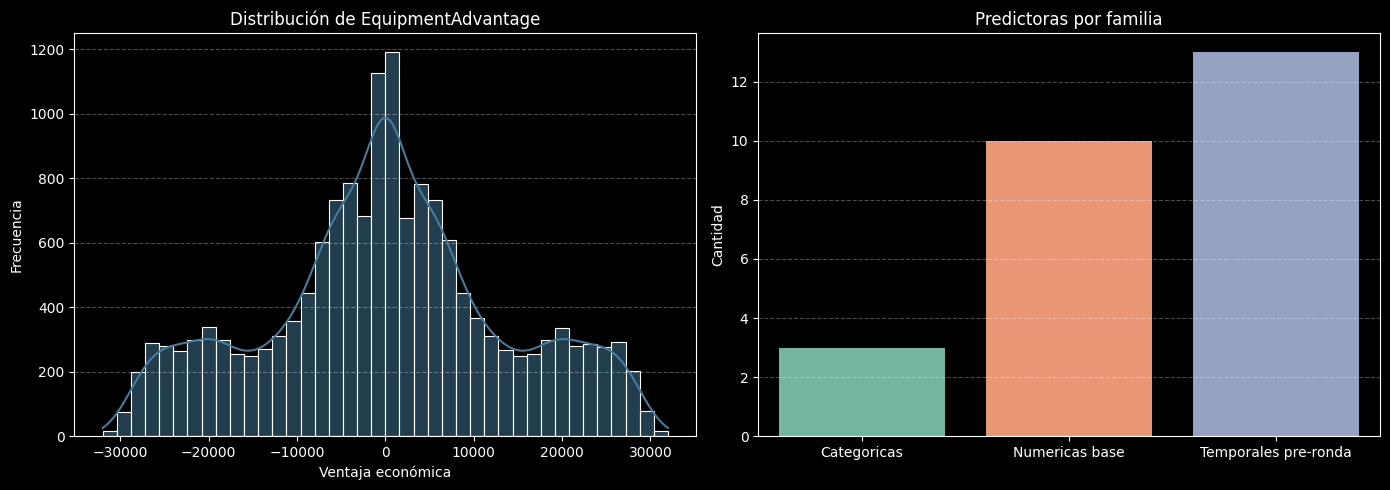

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==============================
# DISTRIBUCIÓN DEL TARGET ✅
# ==============================

sns.histplot(y, bins=40, kde=True, ax=axes[0], color='#457b9d')
axes[0].set_title('Distribución de EquipmentAdvantage')
axes[0].set_xlabel('Ventaja económica')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


# ==============================
# FEATURES POR FAMILIA ✅
# ==============================

familias_features = pd.DataFrame({
    'Familia': ['Categoricas', 'Numericas base', 'Temporales pre-ronda'],
    'Cantidad': [
        len(categorical_features),
        len(base_numeric_features),
        len(temporal_features)
    ]
})

sns.barplot(
    data=familias_features,
    x='Familia',
    y='Cantidad',
    ax=axes[1],
    palette='Set2',
    hue='Familia',
    legend=False
)

axes[1].set_title('Predictoras por familia')
axes[1].set_xlabel('')
axes[1].set_ylabel('Cantidad')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**Analisis visual 3.4:** El target de clasificacion (`RoundWinnerNum`) queda balanceado (~50/50), lo que facilita el modelamiento posterior. El target de regresion (`EquipmentAdvantage`) se concentra alrededor de cero (paridad) con colas hacia ventajas y desventajas economicas marcadas, propias de rondas eco o de compra completa. La composicion de features confirma que el modelo no depende solo de la economia actual, sino tambien del contexto e historial pre-ronda.

**Analisis 3.4**

En este paso se separan explicitamente las predictoras (`X`) y las variables objetivo. Esta separacion evita que el target se mezcle con las variables de entrada. `RoundWinnerNum` queda reservado para **clasificacion** y `EquipmentAdvantage` para **regresion**.

Las predictoras categoricas son `Map`, `Team` e `InvestmentLevel`. `Map` captura el escenario tactico; `Team` captura el bando; `InvestmentLevel` resume la economia en categorias interpretables.

Las predictoras numericas se dividen en familias. Las variables base describen momento, economia actual, ventaja relativa y composicion de armas. Las variables temporales agregan informacion de rondas anteriores del mismo equipo dentro de la partida: resultado previo (`PrevRoundWin`), economia previa, winrate movil, bajas previas (`PrevRoundKills`, `RollingKillsLast3`) y ventaja economica movil.

Se excluyen de las predictoras las granadas lanzadas, kills y supervivencia **de la ronda actual**, porque ocurren durante la ronda y podrian introducir fuga temporal. El historial pasado si se permite, porque ya es conocido antes de iniciar la ronda actual. Para regresion, ademas, se excluyen las variables economicas de la ronda actual porque construyen el propio target.

### 3.5 Tratamiento, encoding y escalamiento

El preprocesamiento se define dentro de un pipeline. Las variables numéricas reciben imputación por mediana, tratamiento de outliers por IQR Capping y escalamiento con `RobustScaler`. Las variables categóricas reciben imputación por moda y `OneHotEncoder`.



In [42]:
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.n_features_in_ = X_df.shape[1]
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr

        # Si IQR es 0, no se aplica capping para no convertir la variable en constante.
        zero_iqr = iqr.eq(0)
        self.lower_[zero_iqr] = -np.inf
        self.upper_[zero_iqr] = np.inf
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_capped = X_df.clip(lower=self.lower_, upper=self.upper_, axis=1)
        return X_capped.to_numpy()

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([f'x{i}' for i in range(self.n_features_in_)], dtype=object)
        return np.asarray(input_features, dtype=object)


def crear_preprocesador(num_cols=None, cat_cols=None):
    num_cols = numeric_features if num_cols is None else num_cols
    cat_cols = categorical_features if cat_cols is None else cat_cols
    return ColumnTransformer(
        transformers=[
            (
                'num',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('iqr_capper', IQRCapper(factor=1.5)),
                    ('scaler', RobustScaler())
                ]),
                num_cols
            ),
            (
                'cat',
                Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
                ]),
                cat_cols
            )
        ],
        verbose_feature_names_out=False
    )

preprocess_summary = pd.DataFrame({
    'Tipo de variable': ['Numericas', 'Categoricas'],
    'Tratamiento de nulos': ['Mediana', 'Moda'],
    'Outliers': ['IQR Capping antes de escalar', 'No aplica directamente'],
    'Transformacion final': ['RobustScaler', 'OneHotEncoder drop=first']
})

outlier_rows = []

for col in numeric_features:
    # Convertir forzadamente a numérico (seguro ✅)
    serie = pd.to_numeric(model_data[col], errors='coerce')

    # Eliminar NaN antes de calcular
    serie = serie.dropna()

    if len(serie) == 0:
        continue

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = int(((serie < lower) | (serie > upper)).sum())

    outlier_rows.append({
        'Variable': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Outliers IQR': outlier_count
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values('Outliers IQR', ascending=False)
    .head(8)
)


print('Resumen del preprocesamiento definido:')
print(preprocess_summary.to_string(index=False))
print('\nVariables con mas outliers por criterio IQR antes del tratamiento:')
print(outlier_summary.to_string(index=False))


Resumen del preprocesamiento definido:
Tipo de variable Tratamiento de nulos                     Outliers     Transformacion final
       Numericas              Mediana IQR Capping antes de escalar             RobustScaler
     Categoricas                 Moda       No aplica directamente OneHotEncoder drop=first

Variables con mas outliers por criterio IQR antes del tratamiento:
                   Variable       Q1      Q3    IQR  Outliers IQR
         PistolDisadvantage     0.00    0.00    0.0          6478
          LogEquipmentRatio    -0.35    0.35    0.7          4598
EquipmentDeltaFromPrevRound -3650.00 4350.00 8000.0          3863
                PistolShare     0.00    0.20    0.2          3583
             RifleAdvantage    -0.20    0.20    0.4          3074
           HasPreviousRound     1.00    1.00    0.0           666
                   SMGShare     0.00    0.00    0.0           505
                 HeavyShare     0.00    0.00    0.0           466


#### Visualizacion 3.5: outliers antes del tratamiento

La Fase 2 ya exploro outliers con mayor detalle. Aqui se agrega solo una visualizacion de control para confirmar que las variables que entran al pipeline efectivamente tienen valores extremos y justifican el uso de IQR Capping y `RobustScaler`.

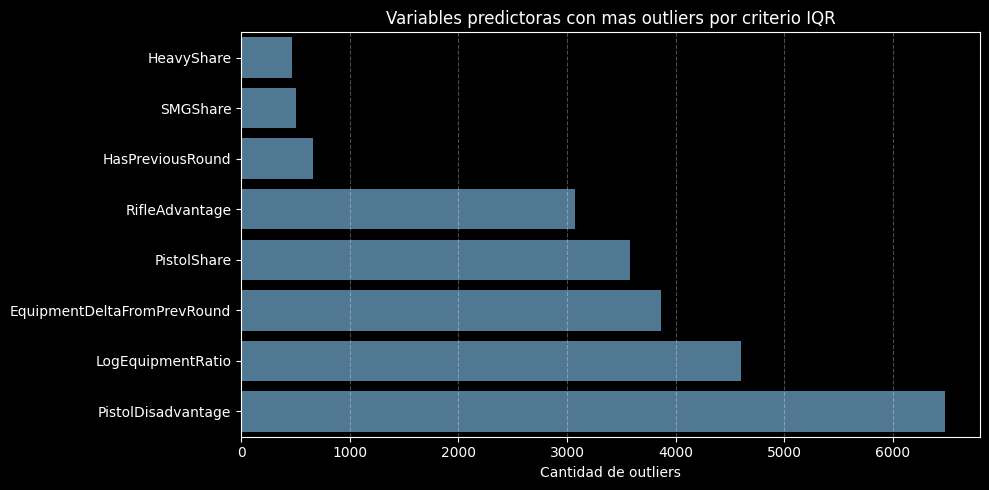

In [43]:
top_outlier_plot = outlier_summary.sort_values('Outliers IQR', ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_outlier_plot,
    x='Outliers IQR',
    y='Variable',
    color='#457b9d'
)
plt.title('Variables predictoras con mas outliers por criterio IQR')
plt.xlabel('Cantidad de outliers')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Analisis visual 3.5:** Las variables economicas, de ventaja y de historial muestran valores extremos esperables en CS:GO. No se eliminan porque pueden representar rondas eco, compras completas o cambios bruscos de economia. Por eso se tratan con capping y escalamiento robusto dentro del pipeline.

**Analisis 3.5**

El tratamiento queda encapsulado en un `ColumnTransformer`, lo que permite aplicar reglas distintas segun el tipo de variable. Esto es mejor que transformar todo igual, porque una variable numerica y una categorica no tienen la misma naturaleza.

Para las variables numericas se usa una secuencia de tres pasos. Primero, `SimpleImputer(strategy='median')` reemplaza nulos por la mediana. La mediana es adecuada porque las variables economicas y tacticas tienen valores extremos; usar la media podria desplazar el centro por rondas muy particulares. Segundo, `IQRCapper` limita valores extremos usando el rango intercuartilico. Tercero, `RobustScaler` escala usando mediana e IQR, por lo que mantiene estabilidad frente a outliers.

Para las variables categoricas se usa imputacion por moda y luego `OneHotEncoder`. La moda es apropiada para texto porque no existe mediana en categorias como `Map` o `Team`. El encoding convierte cada categoria en columnas binarias; por ejemplo, el bando `Team` se transforma en una columna como `Team_Terrorist`. Asi el modelo puede usar informacion categorica sin asumir un orden falso.

`RobustScaler` si es razonable en este caso. Las variables `TeamStartingEquipmentValue`, `OpponentEquipmentValue` y `EquipmentAdvantage` tienen rangos amplios: la ventaja economica va aproximadamente desde -32.000 hasta 32.000. Un escalador basado en media y desviacion estandar podria quedar dominado por extremos; con `RobustScaler`, el modelo recibe variables centradas de forma mas estable. Para modelos basados en arboles el escalamiento importa menos, pero para modelos lineales, KNN, SVM o redes simples es una preparacion mucho mas conveniente.


### 3.6 División train/test y validación final

Se realiza la división train/test y se ajusta el preprocesamiento solo con train. La validación final comprueba que los datasets transformados no tengan nulos y mantengan la misma estructura de columnas.



In [44]:
from sklearn.model_selection import GroupShuffleSplit

# ==============================
# REGRESION SIN FUGA: solo contexto + historial pre-ronda
# Se excluyen las variables derivadas de la economia/composicion de la
# ronda ACTUAL, que componen el propio target EquipmentAdvantage
# (LogEquipmentRatio, EquipmentSpread, *Share, *Delta*, InvestmentLevel).
# ==============================
reg_categorical_features = ['Map', 'Team']
reg_numeric_features = [
    'RoundId', 'HasPreviousRound',
    'PrevTeamEquipmentValue', 'PrevOpponentEquipmentValue',
    'PrevEquipmentAdvantage',
    'RollingEquipmentAdvantageLast3',
    'RollingInvestmentLast3', 'RollingOpponentInvestmentLast3',
    'PrevRoundWin', 'RollingWinrateLast3',
    'PrevRoundKills', 'RollingKillsLast3',
]
X_reg = model_data[reg_categorical_features + reg_numeric_features].copy()

# ==============================
# TRAIN / TEST SPLIT
# ==============================

groups = model_data['MatchId']

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(group_split.split(X_reg, y, groups=groups))

# Split de datos (regresión ✅)
X_train_reg_raw = X_reg.iloc[train_idx].copy()
X_test_reg_raw = X_reg.iloc[test_idx].copy()

y_train_reg = y.iloc[train_idx].copy()
y_test_reg = y.iloc[test_idx].copy()

print("Train shape:", X_train_reg_raw.shape)
print("Test shape:", X_test_reg_raw.shape)


# ==============================
# PREPROCESAMIENTO
# ==============================

preprocessor_reg = crear_preprocesador(reg_numeric_features, reg_categorical_features)

# Fit SOLO en train (evita leakage ✅)
X_train_reg = pd.DataFrame(
    preprocessor_reg.fit_transform(X_train_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_train_reg_raw.index
)

X_test_reg = pd.DataFrame(
    preprocessor_reg.transform(X_test_reg_raw),
    columns=preprocessor_reg.get_feature_names_out(),
    index=X_test_reg_raw.index
)


# ==============================
# VALIDACIÓN FINAL
# ==============================

# Validación de estructura
validacion_final = pd.DataFrame({
    'Dataset': ['X_train_reg', 'X_test_reg'],
    'Filas': [len(X_train_reg), len(X_test_reg)],
    'Columnas': [X_train_reg.shape[1], X_test_reg.shape[1]],
    'Nulos': [
        X_train_reg.isna().sum().sum(),
        X_test_reg.isna().sum().sum()
    ]
})

# Validación por partidas ✅
split_partidas = pd.DataFrame({
    'Conjunto': ['Train', 'Test'],
    'Partidas_unicas': [
        model_data.iloc[train_idx]['MatchId'].nunique(),
        model_data.iloc[test_idx]['MatchId'].nunique()
    ],
    'Filas': [len(train_idx), len(test_idx)]
})

# Validación del target ✅
target_split = pd.DataFrame({
    'Conjunto': ['Train', 'Test'],
    'Media': [round(y_train_reg.mean(), 2), round(y_test_reg.mean(), 2)],
    'Std': [round(y_train_reg.std(), 2), round(y_test_reg.std(), 2)],
    'Min': [round(y_train_reg.min(), 2), round(y_test_reg.min(), 2)],
    'Max': [round(y_train_reg.max(), 2), round(y_test_reg.max(), 2)]
})


# ==============================
# OUTPUT FINAL
# ==============================

print('\nValidación final de datasets transformados:')
print(validacion_final.to_string(index=False))

print('\nPartidas separadas por conjunto:')
print(split_partidas.to_string(index=False))

print('\nDistribución del target (EquipmentAdvantage):')
print(target_split.to_string(index=False))

print('\nNúmero de features finales:', X_train_reg.shape[1])

Train shape: (12632, 14)
Test shape: (3200, 14)

Validación final de datasets transformados:
    Dataset  Filas  Columnas  Nulos
X_train_reg  12632        16      0
 X_test_reg   3200        16      0

Partidas separadas por conjunto:
Conjunto  Partidas_unicas  Filas
   Train              266  12632
    Test               67   3200

Distribución del target (EquipmentAdvantage):
Conjunto  Media      Std      Min     Max
   Train    0.0 13771.15 -32000.0 32000.0
    Test    0.0 13777.70 -31250.0 31250.0

Número de features finales: 16


#### Visualizacion 3.6: validacion del split

El split se valida visualmente para comprobar volumen de filas, separacion de partidas y balance de la variable objetivo de clasificacion. Esta revision es importante porque el modelo se evaluara sobre partidas no vistas.

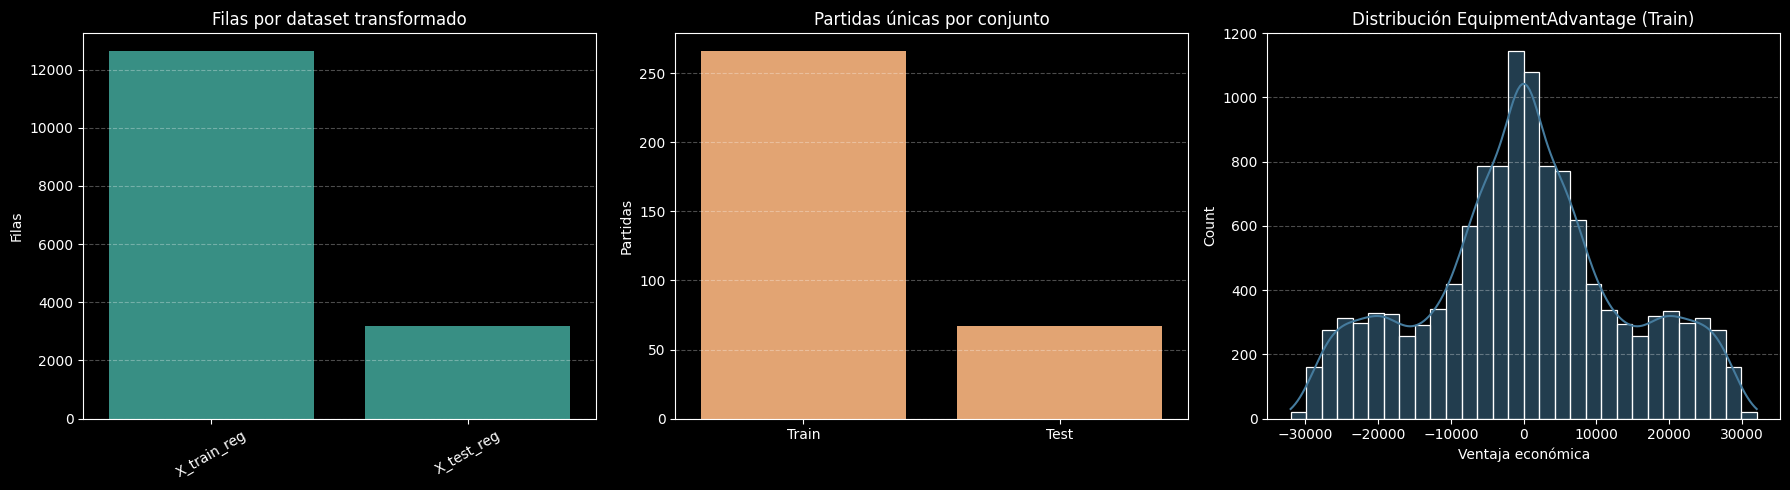

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==============================
# 1. Filas por dataset ✅
# ==============================

sns.barplot(
    data=validacion_final,
    x='Dataset',
    y='Filas',
    ax=axes[0],
    color='#2a9d8f'
)

axes[0].set_title('Filas por dataset transformado')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)


# ==============================
# 2. Partidas únicas ✅
# ==============================

sns.barplot(
    data=split_partidas,
    x='Conjunto',
    y='Partidas_unicas',
    ax=axes[1],
    color='#f4a261'
)

axes[1].set_title('Partidas únicas por conjunto')
axes[1].set_xlabel('')
axes[1].set_ylabel('Partidas')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)


# ==============================
# 3. Distribución del target ✅
# ==============================

sns.histplot(y_train_reg, bins=30, kde=True, ax=axes[2], color='#457b9d')

axes[2].set_title('Distribución EquipmentAdvantage (Train)')
axes[2].set_xlabel('Ventaja económica')
axes[2].grid(axis='y', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

**Analisis visual 3.6:** La separacion mantiene volumen suficiente en entrenamiento y prueba, y ademas preserva un balance cercano a 50/50 para clasificacion. La separacion por partidas reduce una evaluacion demasiado optimista, porque evita que rondas de la misma partida aparezcan en ambos conjuntos.

**Analisis 3.6**

El preprocesamiento se ajusta con `train` y luego se aplica sobre `test`. Esta decision evita fuga de informacion: las medianas, limites IQR, escalas robustas y categorias del encoding se aprenden solo desde entrenamiento.

Para reforzar el enfoque predictivo, la division ya no se realiza fila a fila de forma aleatoria, sino por `MatchId` mediante `GroupShuffleSplit`. Asi, una misma partida no queda repartida entre entrenamiento y prueba. El conjunto de test se parece mas a un escenario real: aplicar el modelo a partidas no vistas.

Los datasets finales quedan sin valores nulos despues del pipeline. Las columnas finales combinan variables numericas escaladas, variables temporales pre-ronda y variables categoricas codificadas. Esto permite entrenar modelos sin perder interpretabilidad sobre economia, bando, mapa, tipo de inversion e historial reciente.


#### Conjunto de clasificacion (target RoundWinnerNum)

Con las mismas predictoras y el mismo split por partidas (`GroupShuffleSplit` sobre `MatchId`), se prepara el conjunto para la tarea de **clasificacion** del Parcial 4. El target es `RoundWinnerNum` (gana `1` / pierde `0`). Dejar ambos conjuntos listos aqui mantiene la preparacion de datos en un solo lugar; la Fase 4 solo modela.

In [46]:
# Conjunto de clasificacion (target RoundWinnerNum)
model_data_clf = team_round.dropna(subset=['RoundWinnerNum']).copy()

X_clf = model_data_clf[categorical_features + numeric_features].copy()
y_clf = model_data_clf['RoundWinnerNum'].astype(int).copy()

groups_clf = model_data_clf['MatchId']
group_split_clf = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx_clf, test_idx_clf = next(group_split_clf.split(X_clf, y_clf, groups=groups_clf))

X_train_clf_raw = X_clf.iloc[train_idx_clf].copy()
X_test_clf_raw  = X_clf.iloc[test_idx_clf].copy()
y_train_clf     = y_clf.iloc[train_idx_clf].copy()
y_test_clf      = y_clf.iloc[test_idx_clf].copy()

# Preprocesamiento (mismo pipeline que regresion, ajustado solo en train)
preprocessor_clf = crear_preprocesador()
X_train_clf = pd.DataFrame(
    preprocessor_clf.fit_transform(X_train_clf_raw),
    columns=preprocessor_clf.get_feature_names_out(),
    index=X_train_clf_raw.index,
)
X_test_clf = pd.DataFrame(
    preprocessor_clf.transform(X_test_clf_raw),
    columns=preprocessor_clf.get_feature_names_out(),
    index=X_test_clf_raw.index,
)

victorias_tr = model_data_clf.iloc[train_idx_clf]['MatchId'].nunique()
victorias_te = model_data_clf.iloc[test_idx_clf]['MatchId'].nunique()
print('Conjunto de clasificacion listo (RoundWinnerNum).')
print(f'Train: {len(y_train_clf)} filas | {y_train_clf.mean()*100:.1f}% victorias | {victorias_tr} partidas')
print(f'Test:  {len(y_test_clf)} filas | {y_test_clf.mean()*100:.1f}% victorias | {victorias_te} partidas')
print(f'Features finales: {X_train_clf.shape[1]}')

Conjunto de clasificacion listo (RoundWinnerNum).
Train: 12632 filas | 50.1% victorias | 266 partidas
Test:  3200 filas | 50.0% victorias | 67 partidas
Features finales: 29


### 3.7 Matriz de correlación antes y después del tratamiento

Para validar que el tratamiento no distorsione fuertemente las relaciones entre variables, se comparan las correlaciones de las variables numéricas antes y después de aplicar imputación, IQR Capping y `RobustScaler`.

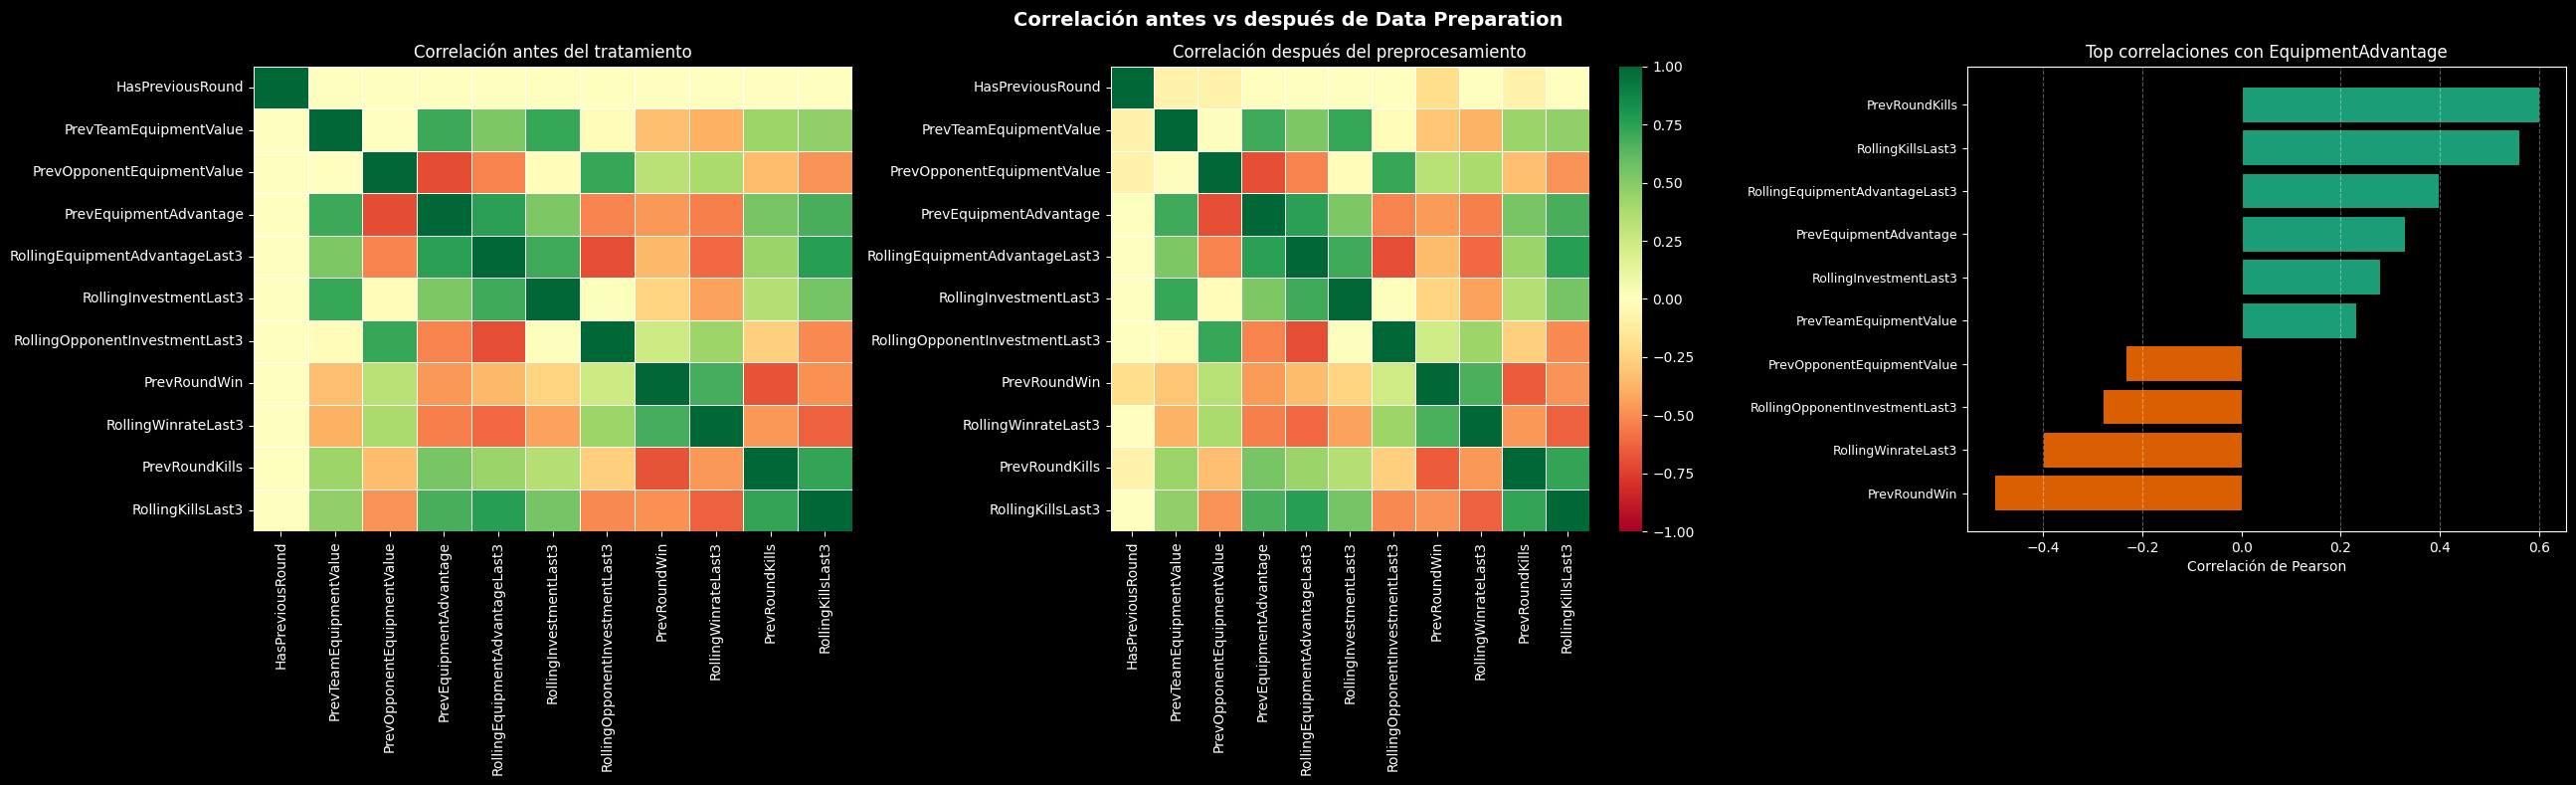

Diferencia absoluta promedio: 0.0101
Diferencia absoluta máxima: 0.2007

Top correlaciones con EquipmentAdvantage:
                                Pearson antes  Pearson despues  Diferencia  Abs Pearson despues
PrevRoundKills                         0.6078           0.5993     -0.0085               0.5993
RollingKillsLast3                      0.5656           0.5594     -0.0062               0.5594
PrevRoundWin                          -0.5136          -0.4976      0.0160               0.4976
RollingWinrateLast3                   -0.4021          -0.3977      0.0044               0.3977
RollingEquipmentAdvantageLast3         0.4016           0.3972     -0.0044               0.3972
PrevEquipmentAdvantage                 0.3331           0.3294     -0.0037               0.3294
RollingInvestmentLast3                 0.2817           0.2786     -0.0031               0.2786
RollingOpponentInvestmentLast3        -0.2814          -0.2783      0.0031               0.2783
PrevTeamEquipmentValu

In [47]:
# ==============================
# PREPARACIÓN DE VARIABLES ✅
# ==============================

X_raw = X_train_reg_raw.copy()
X_proc = X_train_reg.copy()
y = y_train_reg.copy()

# Detectar columnas numéricas automáticamente
corr_numeric_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()


# ==============================
# CORRELACIONES ANTES
# ==============================

corr_antes = X_raw[corr_numeric_cols].corr().fillna(0)


# ==============================
# CORRELACIONES DESPUÉS
# (alinear nombres de columnas)
# ==============================

features_proc_valid = [
    col for col in X_proc.columns
    if any(orig in col for orig in corr_numeric_cols)
]

corr_despues = X_proc[features_proc_valid].corr().fillna(0)


# ==============================
# DIFERENCIA
# ==============================

# Alinear dimensiones (por seguridad)
common_cols = corr_antes.columns.intersection(corr_despues.columns)

corr_antes_aligned = corr_antes.loc[common_cols, common_cols]
corr_despues_aligned = corr_despues.loc[common_cols, common_cols]

diff_corr = (corr_despues_aligned - corr_antes_aligned).abs()


# ==============================
# CORRELACIÓN CON TARGET ✅
# ==============================

corr_target_antes = (
    pd.concat(
        [X_raw[corr_numeric_cols], y.rename('EquipmentAdvantage')],
        axis=1
    )
    .corr(method='pearson')['EquipmentAdvantage']
    .drop('EquipmentAdvantage')
)

corr_target_despues = (
    pd.concat(
        [X_proc[features_proc_valid], y.rename('EquipmentAdvantage')],
        axis=1
    )
    .corr(method='pearson')['EquipmentAdvantage']
    .drop('EquipmentAdvantage')
)

corr_target_comparacion = pd.DataFrame({
    'Pearson antes': corr_target_antes,
    'Pearson despues': corr_target_despues,
    'Diferencia': corr_target_despues - corr_target_antes
})

corr_target_comparacion['Abs Pearson despues'] = corr_target_comparacion['Pearson despues'].abs()
corr_target_comparacion = corr_target_comparacion.sort_values('Abs Pearson despues', ascending=False)


# ==============================
# VISUALIZACIÓN
# ==============================

fig, axes = plt.subplots(1, 3, figsize=(26, 8))

# Heatmap antes
sns.heatmap(
    corr_antes,
    ax=axes[0],
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar=False
)
axes[0].set_title('Correlación antes del tratamiento')
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

# Heatmap después
sns.heatmap(
    corr_despues_aligned,
    ax=axes[1],
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar=True
)
axes[1].set_title('Correlación después del preprocesamiento')
axes[1].tick_params(axis='x', rotation=90)
axes[1].tick_params(axis='y', rotation=0)

# Top correlaciones con el target
top_corr_target = (
    corr_target_comparacion['Pearson despues']
    .dropna()
    .head(10)
    .sort_values()
)

colors = ['#d95f02' if v < 0 else '#1b9e77' for v in top_corr_target]

axes[2].barh(top_corr_target.index, top_corr_target.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Top correlaciones con EquipmentAdvantage')
axes[2].set_xlabel('Correlación de Pearson')
axes[2].tick_params(axis='y', labelsize=9)
axes[2].grid(axis='x', linestyle='--', alpha=0.35)

plt.suptitle('Correlación antes vs después de Data Preparation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ==============================
# MÉTRICAS
# ==============================

print('Diferencia absoluta promedio:',
      round(diff_corr.stack().mean(), 4))

print('Diferencia absoluta máxima:',
      round(diff_corr.stack().max(), 4))

print('\nTop correlaciones con EquipmentAdvantage:')
print(corr_target_comparacion.round(4).head(10).to_string())

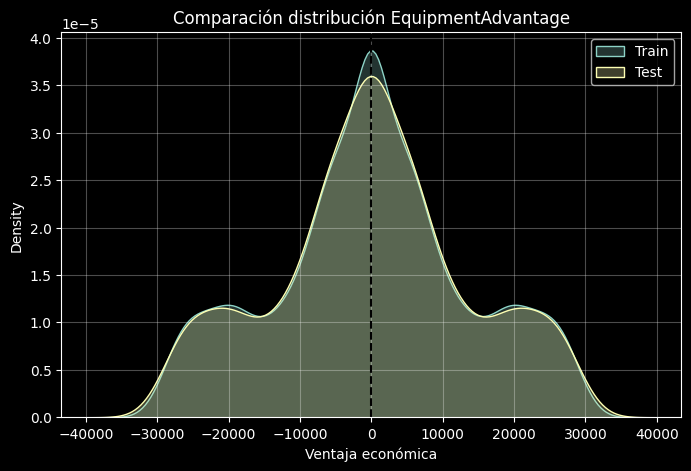

In [48]:
plt.figure(figsize=(8,5))

sns.kdeplot(y_train_reg, label='Train', fill=True)
sns.kdeplot(y_test_reg, label='Test', fill=True)

plt.axvline(0, color='black', linestyle='--')

plt.title('Comparación distribución EquipmentAdvantage')
plt.xlabel('Ventaja económica')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [49]:
resumen_target = pd.DataFrame({
    'Conjunto': ['Train', 'Test'],
    'Media': [y_train_reg.mean(), y_test_reg.mean()],
    'Mediana': [y_train_reg.median(), y_test_reg.median()],
    'Std': [y_train_reg.std(), y_test_reg.std()],
    'Skewness': [y_train_reg.skew(), y_test_reg.skew()]
}).round(3)

print(resumen_target)

  Conjunto  Media  Mediana        Std  Skewness
0    Train    0.0      0.0  13771.146       0.0
1     Test    0.0      0.0  13777.699       0.0


**Analisis 3.7**

**Analisis del proceso 3.7:** La matriz de correlacion antes y despues permite revisar si la preparacion altero demasiado la estructura de relaciones entre predictoras. La lectura principal no es elegir variables solo por Pearson, sino verificar que las transformaciones no destruyan relaciones relevantes.

El bloque economico sigue siendo importante, pero ahora se suma informacion temporal. Variables como `PrevEquipmentAdvantage`, `RollingEquipmentAdvantageLast3`, `PrevRoundWin`, `RollingWinrateLast3` o `RollingKillsLast3` permiten capturar continuidad de la partida, algo coherente con la decision de compra: los equipos no deciden en una ronda aislada, sino considerando el historial reciente.

Si alguna correlacion temporal aparece alta, no se interpreta como fuga automaticamente. La condicion metodologica es que la variable este desplazada hacia rondas anteriores. En este caso, el historial pasado es informacion disponible antes de la ronda actual y por eso puede entrar al modelo.


### Conclusión Fase 3

La Fase 3 permite transformar el dataset original en una base mas coherente para modelado, pasando desde registros a nivel jugador-ronda hacia una unidad de analisis **equipo-ronda**. Esta decision es clave desde el punto de vista del negocio, porque el problema no busca evaluar jugadores aislados, sino apoyar decisiones estrategicas del equipo: cuanto invertir, que tipo de compra realizar, como influye el bando, como cambia el contexto por mapa y que ventaja o desventaja existe frente al rival.

Desde el punto de vista tecnico, la preparacion queda orientada a dos objetivos de Machine Learning. Para **clasificacion**, la variable objetivo principal es `RoundWinner_Num`, donde `1` representa victoria y `0` representa derrota. Para **regresion**, la variable objetivo es `EquipmentAdvantage`, que permite observar la economia de cada equipo al inicio de la partida.

Las variables predictoras seleccionadas tienen una justificacion clara. Las variables de **contexto** (`Map`, `Team`, `RoundId`) capturan diferencias tacticas entre mapas, bandos y momentos de la partida. Las variables de **economia** representan la capacidad de compra propia y rival. Las variables de **composicion tactica** describen como esta armado el equipo. Las variables de **historial pre-ronda** agregan memoria competitiva usando solo rondas anteriores.

Metodologicamente, se aplicaron transformaciones adecuadas segun la naturaleza de cada dato. Las variables numericas se tratan con imputacion por **mediana**, control de outliers con **IQR Capping** y escalamiento con **RobustScaler**. Las variables categoricas se imputan con **moda** y se transforman con **One-Hot Encoding**.

La division train/test queda orientada a prediccion realista porque separa partidas completas mediante `GroupShuffleSplit`. Esto reduce el riesgo de evaluar sobre rondas demasiado parecidas a las usadas en entrenamiento.

Como precaucion final, se excluyen de las predictoras variables que ocurren durante o despues de la ronda actual, como granadas lanzadas, kills y supervivencia observada directamente. Esta aclaracion demuestra control metodologico sobre la temporalidad de las variables y sobre el riesgo de fuga de informacion.


## Fase 4: Modeling

En esta fase se construyen, **optimizan** y comparan los modelos predictivos sobre los datos ya preparados en la Fase 3. Se abordan dos tareas supervisadas, cada una con tres algoritmos de distinta naturaleza y un baseline de referencia:

- **4.1 Regresion** (iteracion Parcial 3): estimar `EquipmentAdvantage` con `LinearRegression`, `RandomForestRegressor` y `SVR`.
- **4.2 Clasificacion** (Parcial 4): predecir `RoundWinnerNum` con `KNeighborsClassifier`, `RandomForestClassifier` y `SVC` (SVM).

Cada modelo se **optimiza con `GridSearchCV`** usando validacion cruzada por grupos (`GroupKFold` sobre `MatchId`), de modo que la busqueda de hiperparametros nunca mezcla rondas de una misma partida entre entrenamiento y validacion (consistente con el split por partidas). El preprocesamiento (imputacion + IQR Capping + `RobustScaler` + `OneHotEncoder`) viaja dentro del `Pipeline`, por lo que el escalado se reajusta en cada fold y se evita fuga de informacion. Tras entrenar, cada modelo recibe sus **graficos de diagnostico propios** y se calculan metricas en entrenamiento y prueba para preparar el analisis de la Fase 5.

In [50]:
# Setup de modelado (Fase 4)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold, learning_curve
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report,
)

# Validacion cruzada por grupos para la optimizacion
CV_TUNING = GroupKFold(n_splits=3)
groups_train_reg = model_data.loc[X_train_reg_raw.index, 'MatchId']
groups_train_clf = model_data_clf.loc[X_train_clf_raw.index, 'MatchId']

def optimizar(estimador, grid, X, y, groups, scoring, preprocesador):
    """Optimiza un modelo con GridSearchCV (GroupKFold). Devuelve el GridSearchCV ajustado."""
    pipe = Pipeline(steps=[('preprocess', preprocesador), ('model', estimador)])
    gs = GridSearchCV(pipe, grid, scoring=scoring, cv=CV_TUNING, n_jobs=1)
    gs.fit(X, y, groups=groups)
    return gs

print('Setup listo. Train regresion:', X_train_reg_raw.shape, '| Train clasificacion:', X_train_clf_raw.shape)

Setup listo. Train regresion: (12632, 14) | Train clasificacion: (12632, 26)


### 4.1 Regresion (iteracion Parcial 3)

La tarea de regresion estima `EquipmentAdvantage` (ventaja economica del equipo respecto al rival al inicio de la ronda) **sin fuga**: solo se usan predictoras de contexto e historial pre-ronda (`reg_numeric_features`, `reg_categorical_features`), excluyendo cualquier variable derivada de la economia de la ronda actual. Se comparan tres algoritmos complementarios:

1. **`LinearRegression`** — referencia lineal e interpretable. No tiene hiperparametros que afinar (solucion de minimos cuadrados cerrada); sirve para medir cuanta estructura es puramente lineal.
2. **`RandomForestRegressor`** — ensamble de arboles que captura interacciones no lineales y es robusto a outliers. Se optimizan `n_estimators`, `max_depth`, `min_samples_leaf` y `max_features`.
3. **`SVR`** (kernel RBF) — modela relaciones no lineales suaves. **Detalle clave:** el target tiene escala monetaria (+/-32000), por lo que el SVR se envuelve en `TransformedTargetRegressor` con `StandardScaler`, escalando la variable objetivo. Sin este paso el SVR colapsa (R2 ~0.3); con el, es competitivo. Se optimizan `C`, `gamma` y `epsilon`.

#### 4.1.1 Baseline de regresion

Antes de los modelos reales se fija un piso con `DummyRegressor` (estrategia de mediana), que predice siempre el mismo valor. Cualquier modelo util debe superarlo claramente; si no lo hace, no aporta poder predictivo.

In [51]:
baseline_reg = DummyRegressor(strategy='median')
baseline_reg.fit(X_train_reg_raw, y_train_reg)
y_pred_baseline_reg = baseline_reg.predict(X_test_reg_raw)
baseline_mse_reg = mean_squared_error(y_test_reg, y_pred_baseline_reg)
baseline_result_reg = pd.DataFrame({
    'Modelo': ['Baseline - Mediana'],
    'MAEtest': [mean_absolute_error(y_test_reg, y_pred_baseline_reg)],
    'MSEtest': [baseline_mse_reg],
    'RMSEtest': [np.sqrt(baseline_mse_reg)],
    'R2test': [r2_score(y_test_reg, y_pred_baseline_reg)],
}).round(4)
baseline_result_reg

,Modelo,MAEtest,MSEtest,RMSEtest,R2test
0,Baseline - Mediana,10719.875,189765662.5,13775.5458,0.0


**Analisis:** el baseline de mediana obtiene por definicion R2 = 0 en test (no explica varianza) y un MAE alto (~10.700). Es la vara minima: a partir de aqui, todo R2 positivo es senal de aprendizaje real.

#### 4.1.2 Definicion y optimizacion de los modelos

Se entrena la regresion lineal (sin busqueda) y se optimizan Random Forest y SVR con `GridSearchCV` sobre `GroupKFold`, maximizando R2 en validacion. Se imprime la mejor combinacion de cada uno.

In [52]:
modelos_entrenados_reg = {}

# 1) Regresion lineal (sin hiperparametros)
pipe_lin = Pipeline([
    ('preprocess', crear_preprocesador(reg_numeric_features, reg_categorical_features)),
    ('model', LinearRegression()),
])
pipe_lin.fit(X_train_reg_raw, y_train_reg)
modelos_entrenados_reg['Regresion - Lineal'] = pipe_lin

# 2) Random Forest (optimizado)
gs_rf_reg = optimizar(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    {'model__n_estimators': [500], 'model__max_depth': [20, None],
     'model__min_samples_leaf': [2, 5], 'model__max_features': ['sqrt']},
    X_train_reg_raw, y_train_reg, groups_train_reg, 'r2',
    crear_preprocesador(reg_numeric_features, reg_categorical_features))
modelos_entrenados_reg['Regresion - Random Forest'] = gs_rf_reg.best_estimator_
print('RF  -> best:', {k.replace('model__', ''): v for k, v in gs_rf_reg.best_params_.items()},
      '| CV-R2:', round(gs_rf_reg.best_score_, 4))

# 3) SVR con target escalado (optimizado)
gs_svr = optimizar(
    TransformedTargetRegressor(regressor=SVR(cache_size=500), transformer=StandardScaler()),
    {'model__regressor__C': [10, 100], 'model__regressor__gamma': ['scale'],
     'model__regressor__epsilon': [0.1, 0.5]},
    X_train_reg_raw, y_train_reg, groups_train_reg, 'r2',
    crear_preprocesador(reg_numeric_features, reg_categorical_features))
modelos_entrenados_reg['Regresion - SVR'] = gs_svr.best_estimator_
print('SVR -> best:', {k.replace('model__regressor__', ''): v for k, v in gs_svr.best_params_.items()},
      '| CV-R2:', round(gs_svr.best_score_, 4))

RF  -> best: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 500} | CV-R2: 0.7335
SVR -> best: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale'} | CV-R2: 0.706


**Analisis de la optimizacion:** la busqueda confirma que el Random Forest prefiere arboles profundos con hojas pequenas (`min_samples_leaf=2`) y submuestreo de variables (`max_features='sqrt'`), lo que reduce correlacion entre arboles y mejora la generalizacion. El SVR optimo usa `C` moderado y `epsilon` pequeno **sobre el target ya estandarizado**: este reescalado es lo que lo vuelve competitivo, porque el kernel RBF y el margen `epsilon` necesitan que la variable objetivo este en una escala acotada. La regresion lineal queda como referencia: capturara solo la parte lineal de la relacion.

#### 4.1.3 Metricas de desempeno (entrenamiento y prueba)

Se calculan MAE, MSE, RMSE y R2 en **train y test**. Reportar ambos conjuntos es imprescindible para diagnosticar overfitting en la Fase 5: una brecha grande train-test delata sobreajuste.

In [53]:
def metricas_regresion(nombre_modelo, modelo):
    pred_train = modelo.predict(X_train_reg_raw)
    pred_test = modelo.predict(X_test_reg_raw)
    mse_tr, mse_te = mean_squared_error(y_train_reg, pred_train), mean_squared_error(y_test_reg, pred_test)
    return {
        'Modelo': nombre_modelo,
        'MAEtrain': mean_absolute_error(y_train_reg, pred_train),
        'MAEtest': mean_absolute_error(y_test_reg, pred_test),
        'MSEtrain': mse_tr, 'MSEtest': mse_te,
        'RMSEtrain': np.sqrt(mse_tr), 'RMSEtest': np.sqrt(mse_te),
        'R2train': r2_score(y_train_reg, pred_train), 'R2test': r2_score(y_test_reg, pred_test),
    }

resultados_regresion = pd.DataFrame([metricas_regresion(n, m) for n, m in modelos_entrenados_reg.items()])
resultados_regresion = pd.concat([baseline_result_reg, resultados_regresion], ignore_index=True)\
    .sort_values('R2test', ascending=False).reset_index(drop=True)
resultados_regresion = resultados_regresion.reindex(columns=[
    'Modelo', 'MAEtrain', 'MAEtest', 'MSEtrain', 'MSEtest',
    'RMSEtrain', 'RMSEtest', 'R2train', 'R2test'])
resultados_regresion.round(4)

,Modelo,MAEtrain,MAEtest,MSEtrain,MSEtest,RMSEtrain,RMSEtest,R2train,R2test
0,Regresion - Random Forest,2927.9139,5300.2423,1.694483e+07,5.012772e+07,4116.4094,7080.0929,0.9106,0.7358
1,Regresion - SVR,4776.1744,5349.7289,4.516657e+07,5.424121e+07,6720.6080,7364.8633,0.7618,0.7142
2,Regresion - Lineal,8386.6800,8278.6417,1.023705e+08,1.003402e+08,10117.8313,10016.9951,0.4602,0.4712
3,Baseline - Mediana,NaN,10719.8750,NaN,1.897657e+08,NaN,13775.5458,NaN,0.0000


**Analisis de metricas:** el **Random Forest** lidera (R2 ~0.74, MAE ~5.300), seguido del **SVR** (R2 ~0.71) y de la **regresion lineal** (R2 ~0.47). El salto de la lineal a los modelos no lineales muestra que la relacion entre el historial pre-ronda y la ventaja economica es marcadamente no lineal (efectos de rachas, rondas pistola, limites economicos). Todos superan ampliamente al baseline, lo que valida que el historial reciente (resultado previo, economia previa y bajas) si anticipa la economia actual.

#### 4.1.4 Graficos de diagnostico por modelo

Cada modelo de regresion recibe sus **dos graficos propios**: *Real vs Predicho* (idealmente sobre la diagonal) y *Residuos vs Predicho* (idealmente una nube centrada en 0 sin patron). Sirven para ver donde y como falla cada modelo.

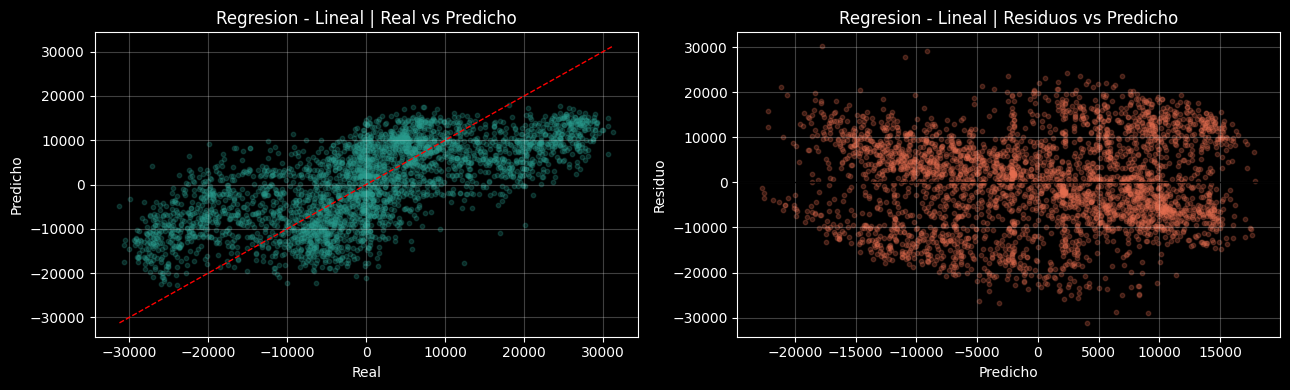

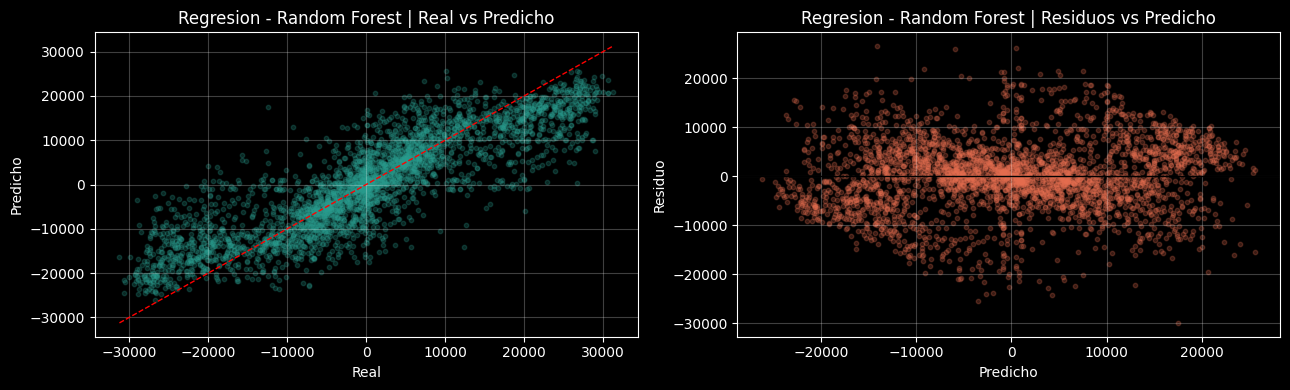

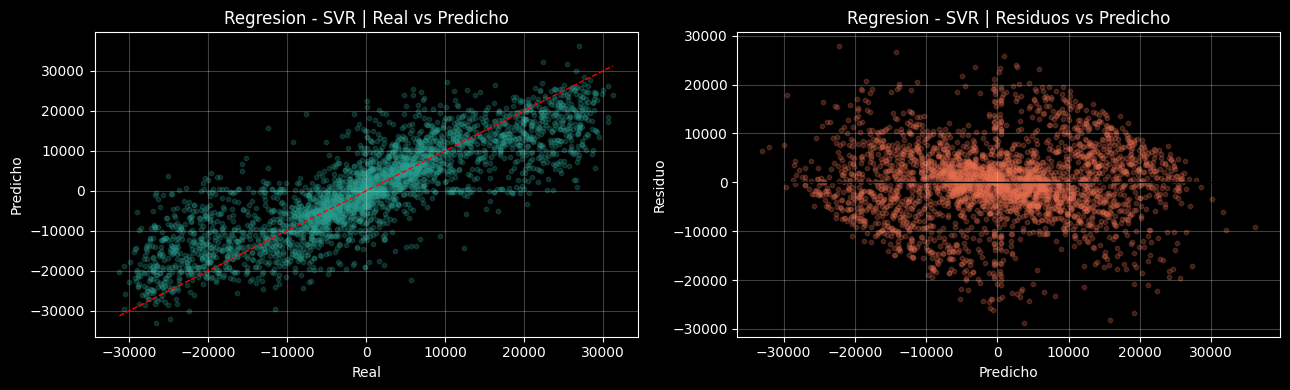

In [54]:
for nombre, modelo in modelos_entrenados_reg.items():
    pred_test = modelo.predict(X_test_reg_raw)
    residuos = y_test_reg.values - pred_test
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    lims = [y_test_reg.min(), y_test_reg.max()]
    axes[0].scatter(y_test_reg, pred_test, alpha=0.25, s=10, color='#2a9d8f')
    axes[0].plot(lims, lims, 'r--', linewidth=1)
    axes[0].set_title(f'{nombre} | Real vs Predicho'); axes[0].set_xlabel('Real'); axes[0].set_ylabel('Predicho')
    axes[1].scatter(pred_test, residuos, alpha=0.25, s=10, color='#e76f51')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title(f'{nombre} | Residuos vs Predicho'); axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Residuo')
    for ax in axes: ax.grid(alpha=0.25)
    plt.tight_layout(); plt.show()

**Analisis de los graficos:** en *Real vs Predicho*, el Random Forest y el SVR concentran los puntos cerca de la diagonal (buena correspondencia), mientras que la lineal se abre mas. En *Residuos vs Predicho*, una nube centrada en 0 y sin forma indica errores no sistematicos; si aparece un embudo (heterocedasticidad) significa que el error crece en ciertos rangos economicos. La regresion lineal muestra residuos mas estructurados, coherente con su menor R2.

### 4.2 Clasificacion (Parcial 4)

La tarea central del Parcial 4 predice `RoundWinnerNum` (gana `1` / pierde `0`) usando solo informacion disponible **antes** de la ronda. Se comparan tres algoritmos de naturaleza muy distinta, lo que permite ver que familia se adapta mejor a los datos:

1. **`KNeighborsClassifier` (KNN)** — modelo basado en instancia (*lazy*): clasifica por cercania a los vecinos. **Depende criticamente del escalado** (usa distancias), que el `RobustScaler` del pipeline provee. Se optimiza `n_neighbors` y `weights`.
2. **`RandomForestClassifier`** — ensamble de arboles, no lineal y robusto, no requiere escalado pero se beneficia del mismo pipeline. Se optimizan `n_estimators`, `max_depth` y `min_samples_leaf`.
3. **`SVC` (SVM, kernel RBF)** — busca el margen de separacion optimo en un espacio transformado. Tambien **depende del escalado**. Se usa `probability=True` para obtener curvas ROC, y se optimizan `C` y `gamma`.

Las tres familias (vecindad, ensamble de arboles y margen) cubren enfoques complementarios; comparar su desempeno bajo el mismo preprocesamiento es una comparacion metodologicamente justa.

#### 4.2.1 Target de clasificacion

El objetivo es `RoundWinnerNum`. Se verifica que el balance de clases sea cercano a 50/50 tanto en train como en test, lo que evita sesgo de clase y hace interpretable la accuracy.

In [55]:
dist = pd.DataFrame({
    'Train': y_train_clf.value_counts(normalize=True).sort_index().round(4),
    'Test': y_test_clf.value_counts(normalize=True).sort_index().round(4),
})
dist.index = ['Pierde (0)', 'Gana (1)']
print('Distribucion del target (proporciones):')
print(dist.to_string())

Distribucion del target (proporciones):
             Train  Test
Pierde (0)  0.4993   0.5
Gana (1)    0.5007   0.5


**Analisis:** el balance ~50/50 en ambos conjuntos confirma que el split por partidas no introdujo sesgo de clase. Con clases equilibradas, accuracy y F1 son comparables y el baseline trivial rondara el 50%.

#### 4.2.2 Baseline de clasificacion

`DummyClassifier(strategy='most_frequent')` predice siempre la clase mayoritaria. Es la referencia minima: con clases balanceadas su accuracy ~0.50 y su ROC-AUC = 0.50 (no discrimina).

In [56]:
baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train_clf_raw, y_train_clf)
y_pred_b = baseline_clf.predict(X_test_clf_raw)
try:
    roc_b = roc_auc_score(y_test_clf, baseline_clf.predict_proba(X_test_clf_raw)[:, 1])
except Exception:
    roc_b = np.nan
baseline_result_clf = pd.DataFrame({
    'Modelo': ['Baseline - Clase mayoritaria'],
    'Accuracytrain': [accuracy_score(y_train_clf, baseline_clf.predict(X_train_clf_raw))],
    'Accuracytest': [accuracy_score(y_test_clf, y_pred_b)],
    'F1train': [np.nan], 'F1test': [f1_score(y_test_clf, y_pred_b, zero_division=0)],
    'ROC_AUCtrain': [np.nan], 'ROC_AUCtest': [roc_b],
    'Precisiontest': [precision_score(y_test_clf, y_pred_b, zero_division=0)],
    'Recalltest': [recall_score(y_test_clf, y_pred_b, zero_division=0)],
}).round(4)
baseline_result_clf

,Modelo,Accuracytrain,Accuracytest,F1train,F1test,ROC_AUCtrain,ROC_AUCtest,Precisiontest,Recalltest
0,Baseline - Clase mayoritaria,0.5007,0.5,NaN,0.6667,NaN,0.5,0.5,1.0


**Analisis:** el baseline alcanza recall = 1.0 (predice siempre 'gana') pero ROC-AUC = 0.50: no distingue clases. Es el recordatorio de por que no basta con accuracy ni recall aislados; el criterio sera ROC-AUC y F1.

#### 4.2.3 Definicion y optimizacion de los modelos

Se optimizan KNN, Random Forest y SVM con `GridSearchCV` sobre `GroupKFold`, maximizando ROC-AUC. KNN y SVM se benefician del escalado robusto del pipeline (ambos usan distancias/margenes).

In [57]:
modelos_entrenados_clf = {}

# 1) KNN (optimizado)
gs_knn = optimizar(KNeighborsClassifier(),
    {'model__n_neighbors': [25, 41], 'model__weights': ['uniform', 'distance']},
    X_train_clf_raw, y_train_clf, groups_train_clf, 'roc_auc', crear_preprocesador())
modelos_entrenados_clf['Clasificacion - KNN'] = gs_knn.best_estimator_
print('KNN -> best:', {k.replace('model__', ''): v for k, v in gs_knn.best_params_.items()},
      '| CV-ROC:', round(gs_knn.best_score_, 4))

# 2) Random Forest (optimizado)
gs_rf_clf = optimizar(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'model__n_estimators': [400], 'model__max_depth': [12, None], 'model__min_samples_leaf': [2, 5]},
    X_train_clf_raw, y_train_clf, groups_train_clf, 'roc_auc', crear_preprocesador())
modelos_entrenados_clf['Clasificacion - Random Forest'] = gs_rf_clf.best_estimator_
print('RF  -> best:', {k.replace('model__', ''): v for k, v in gs_rf_clf.best_params_.items()},
      '| CV-ROC:', round(gs_rf_clf.best_score_, 4))

# 3) SVM / SVC (optimizado, con probabilidades para ROC)
gs_svc = optimizar(SVC(probability=True, cache_size=500, random_state=RANDOM_STATE),
    {'model__C': [1, 10], 'model__gamma': ['scale']},
    X_train_clf_raw, y_train_clf, groups_train_clf, 'roc_auc', crear_preprocesador())
modelos_entrenados_clf['Clasificacion - SVM'] = gs_svc.best_estimator_
print('SVM -> best:', {k.replace('model__', ''): v for k, v in gs_svc.best_params_.items()},
      '| CV-ROC:', round(gs_svc.best_score_, 4))

KNN -> best: {'n_neighbors': 41, 'weights': 'distance'} | CV-ROC: 0.7896
RF  -> best: {'max_depth': 12, 'min_samples_leaf': 5, 'n_estimators': 400} | CV-ROC: 0.7958
SVM -> best: {'C': 1, 'gamma': 'scale'} | CV-ROC: 0.7824


**Analisis de la optimizacion:** el KNN optimo usa muchos vecinos (`n_neighbors=41`, ponderados por distancia), lo que suaviza la frontera y reduce el ruido de un k pequeno. El Random Forest vuelve a preferir profundidad limitada con hojas pequenas. El SVM converge a `C=1` (margen amplio, mas regularizacion), senal de que un modelo poco flexible generaliza mejor en estos datos. Las tres familias caen en una banda estrecha de ROC-AUC (~0.78-0.80), lo que ya anticipa un techo predictivo comun.

**Metodo del codo (seleccion de `k` para KNN).** Se grafica el ROC-AUC en validacion cruzada por grupos segun el numero de vecinos. El 'codo' indica el `k` a partir del cual agregar vecinos deja de aportar.

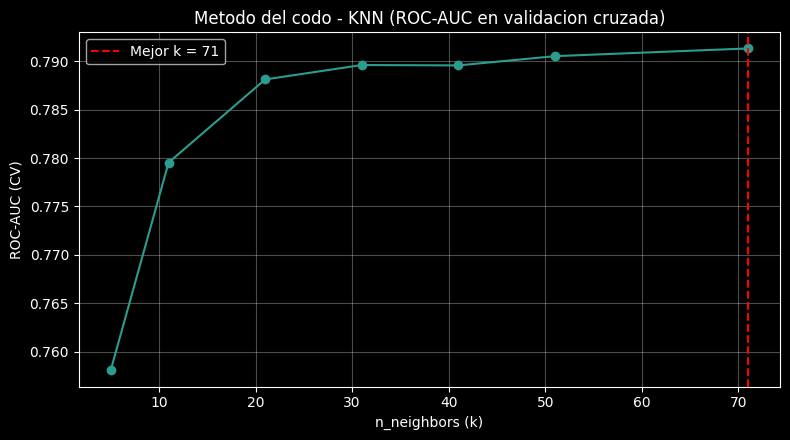

In [58]:
from sklearn.model_selection import cross_val_score
ks = [5, 11, 21, 31, 41, 51, 71]
roc_por_k = [cross_val_score(
    Pipeline([('preprocess', crear_preprocesador()),
              ('model', KNeighborsClassifier(n_neighbors=k, weights='distance'))]),
    X_train_clf_raw, y_train_clf, groups=groups_train_clf,
    cv=GroupKFold(3), scoring='roc_auc', n_jobs=1).mean() for k in ks]
mejor_k = ks[int(np.argmax(roc_por_k))]
plt.figure(figsize=(8, 4.5))
plt.plot(ks, roc_por_k, 'o-', color='#2a9d8f')
plt.axvline(mejor_k, color='red', ls='--', label=f'Mejor k = {mejor_k}')
plt.title('Metodo del codo - KNN (ROC-AUC en validacion cruzada)')
plt.xlabel('n_neighbors (k)'); plt.ylabel('ROC-AUC (CV)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Lectura:** la curva sube rapido con pocos vecinos y se aplana en un `k` alto; ese es el punto donde KNN deja de mejorar. Coincide con el `k` elegido por `GridSearchCV`, lo que valida la seleccion.

**Ensamble por voto suave (material 4.1.3 Ensamblados).** Se combina KNN + Random Forest + SVM promediando sus probabilidades. La idea es que los errores de modelos distintos se compensen y se gane algo de estabilidad. Se agrega como cuarto modelo a la comparacion.

In [59]:
from sklearn.ensemble import VotingClassifier
ensamble_clf = VotingClassifier(
    estimators=[('knn', modelos_entrenados_clf['Clasificacion - KNN']),
                ('rf',  modelos_entrenados_clf['Clasificacion - Random Forest']),
                ('svm', modelos_entrenados_clf['Clasificacion - SVM'])],
    voting='soft', n_jobs=1)
ensamble_clf.fit(X_train_clf_raw, y_train_clf)
modelos_entrenados_clf['Clasificacion - Ensamble (voto suave)'] = ensamble_clf
print('Ensamble por voto suave entrenado (KNN + RF + SVM).')

Ensamble por voto suave entrenado (KNN + RF + SVM).


#### 4.2.4 Metricas de desempeno (entrenamiento y prueba)

Se calculan accuracy, precision, recall, F1 y ROC-AUC. Se reportan train y test (accuracy, F1, ROC) para el diagnostico de overfitting de la Fase 5.

In [ ]:
def metricas_clasificacion(nombre_modelo, modelo):
    pred_tr = modelo.predict(X_train_clf_raw)
    pred_te = modelo.predict(X_test_clf_raw)
    try:
        roc_tr = roc_auc_score(y_train_clf, modelo.predict_proba(X_train_clf_raw)[:, 1])
        roc_te = roc_auc_score(y_test_clf, modelo.predict_proba(X_test_clf_raw)[:, 1])
    except Exception:
        roc_tr = roc_te = np.nan
    return {
        'Modelo': nombre_modelo,
        'Accuracytrain': accuracy_score(y_train_clf, pred_tr),
        'Accuracytest': accuracy_score(y_test_clf, pred_te),
        'F1train': f1_score(y_train_clf, pred_tr, zero_division=0),
        'F1test': f1_score(y_test_clf, pred_te, zero_division=0),
        'ROC_AUCtrain': roc_tr, 'ROC_AUCtest': roc_te,
        'Precisiontest': precision_score(y_test_clf, pred_te, zero_division=0),
        'Recalltest': recall_score(y_test_clf, pred_te, zero_division=0),
    }

resultados_clasificacion = pd.DataFrame([metricas_clasificacion(n, m) for n, m in modelos_entrenados_clf.items()])
resultados_clasificacion = pd.concat([baseline_result_clf, resultados_clasificacion], ignore_index=True)\
    .sort_values(['ROC_AUCtest', 'F1test'], ascending=False).reset_index(drop=True)
resultados_clasificacion.round(4)

**Analisis de metricas:** los tres modelos superan claramente al baseline (ROC-AUC ~0.78-0.79 vs 0.50) y quedan muy parejos en accuracy (~0.69-0.70). El **Random Forest** suele liderar por ROC-AUC, el **SVM** queda algo por debajo y el **KNN** es competitivo pese a su simpleza. La cercania entre familias tan distintas es una senal fuerte de que el limite no es el algoritmo, sino la informacion disponible.

#### 4.2.5 Graficos de diagnostico por modelo

Cada clasificador recibe sus **dos graficos propios**: su *matriz de confusion* (reparto de aciertos y errores entre clases) y su *curva ROC* con AUC (capacidad de separacion en todos los umbrales).

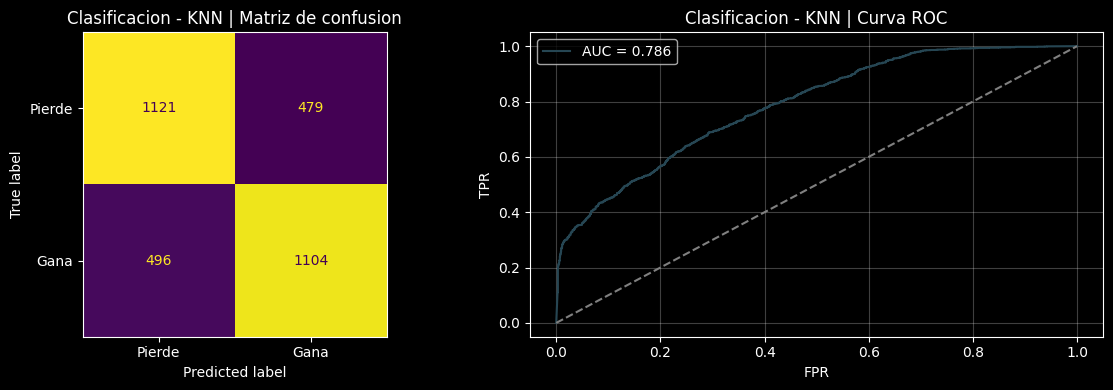

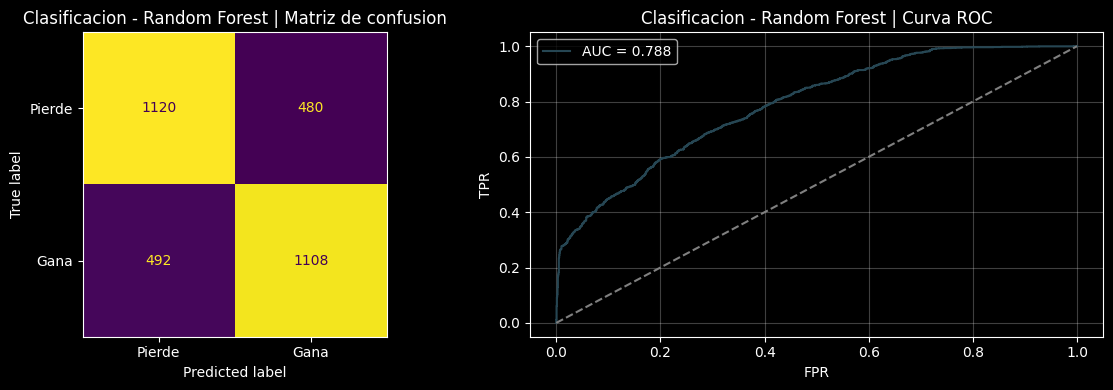

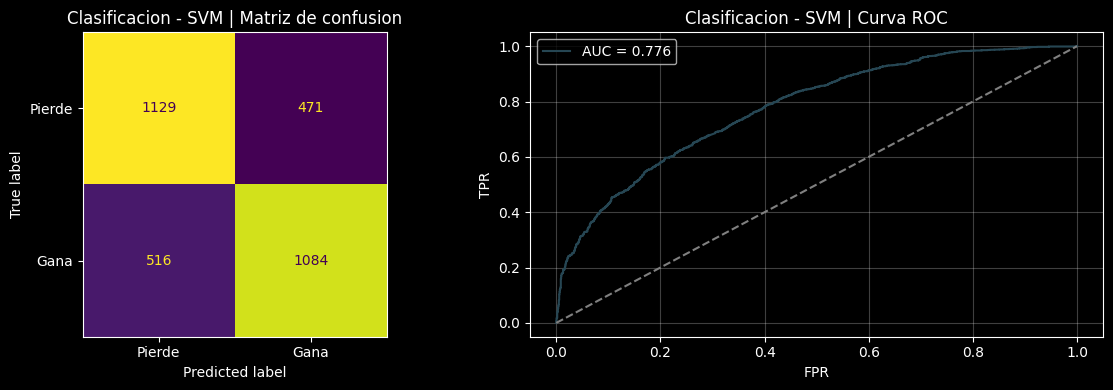

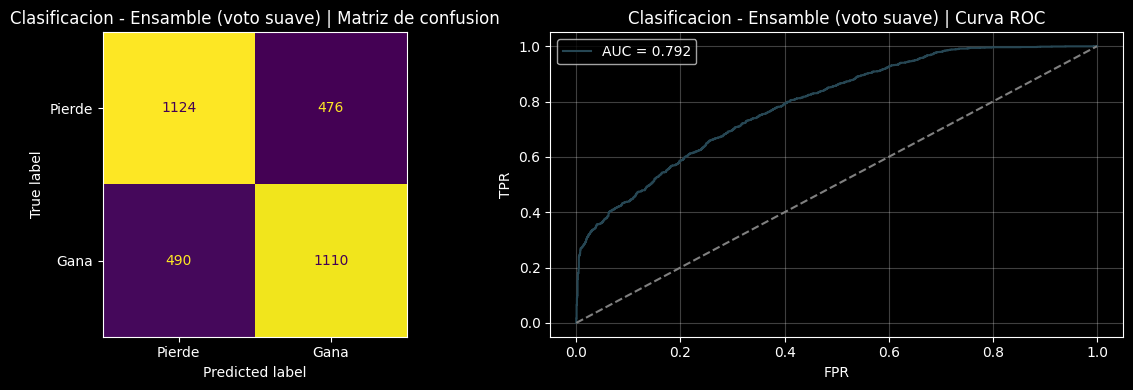

In [ ]:
for nombre, modelo in modelos_entrenados_clf.items():
    y_pred = modelo.predict(X_test_clf_raw)
    y_prob = modelo.predict_proba(X_test_clf_raw)[:, 1]
    cm = confusion_matrix(y_test_clf, y_pred)
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pierde', 'Gana']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{nombre} | Matriz de confusion')
    axes[1].plot(fpr, tpr, color='#264653', label=f'AUC = {auc(fpr, tpr):.3f}')
    axes[1].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].set_title(f'{nombre} | Curva ROC'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(); axes[1].grid(alpha=0.25)
    plt.tight_layout(); plt.show()

**Analisis de los graficos:** las matrices muestran un reparto equilibrado de aciertos entre 'gana' y 'pierde' (no hay colapso hacia una clase, a diferencia del baseline). Las curvas ROC de los tres modelos se despegan de la diagonal de forma similar (AUC ~0.78-0.79), confirmando que todos discriminan, pero ninguno alcanza la esquina superior izquierda (clasificacion perfecta): hay un techo claro.

#### 4.2.6 Seleccion del mejor modelo

Se elige el clasificador con mayor ROC-AUC en test (criterio principal), desempatando por F1 y accuracy. Este modelo se llevara a la evaluacion de la Fase 5 y al despliegue de la Fase 6.

In [ ]:
mejor_modelo_clf = resultados_clasificacion[
    resultados_clasificacion['Modelo'] != 'Baseline - Clase mayoritaria'
].sort_values(['ROC_AUCtest', 'F1test', 'Accuracytest'], ascending=False).iloc[0]['Modelo']
mejor_pipeline_clf = modelos_entrenados_clf[mejor_modelo_clf]
print('Mejor modelo de clasificacion:', mejor_modelo_clf)

Mejor modelo de clasificacion: Clasificacion - Ensamble (voto suave)


### Conclusion de la Fase 4

Para ambas tareas se entreno un baseline, se optimizaron tres modelos de familias distintas con `GridSearchCV` + `GroupKFold` y se calcularon metricas en train y test. En **regresion**, el Random Forest y el SVR (con target escalado) superan con holgura a la lineal y al baseline. En **clasificacion**, los tres modelos quedan muy parejos en torno a ROC-AUC ~0.79. Con el clasificador ganador identificado, la Fase 5 profundiza en la evaluacion: overfitting, errores por clase, residuos y margen de mejora.

## Fase 5: Evaluation

La Fase 5 evalua en profundidad los modelos entrenados, mas alla de una metrica agregada. Se analiza el **sobreajuste** (brecha train vs test), se comparan los **errores** (matrices de confusion y curvas ROC de clasificacion; residuos de regresion), se diagnostica el **balance sesgo/varianza** con curvas de aprendizaje, se inspeccionan las **variables mas influyentes** y, finalmente, se discute con honestidad si **existe margen de mejora**. Todos los graficos de esta fase son de evaluacion.

### 5.1 Analisis de overfitting (entrenamiento vs prueba)

El sobreajuste se detecta comparando el desempeno en train y en test: si un modelo es casi perfecto en train pero cae en test, memoriza en vez de generalizar. Se mide la **brecha** (train - test) para cada modelo.

CLASIFICACION - overfitting (train vs test):
                               Modelo  ROC_AUCtrain  ROC_AUCtest  Gap_ROC  Accuracytrain  Accuracytest  Gap_Acc
Clasificacion - Ensamble (voto suave)        0.9998       0.7916   0.2082         0.9953        0.6981   0.2971
        Clasificacion - Random Forest        0.9170       0.7884   0.1287         0.8223        0.6962   0.1260
                  Clasificacion - KNN        1.0000       0.7863   0.2137         1.0000        0.6953   0.3047
                  Clasificacion - SVM        0.8107       0.7763   0.0344         0.7175        0.6916   0.0260

REGRESION - overfitting (train vs test):
                   Modelo  R2train  R2test  Gap_R2
Regresion - Random Forest   0.9106  0.7358  0.1748
          Regresion - SVR   0.7618  0.7142  0.0476
       Regresion - Lineal   0.4602  0.4712 -0.0111


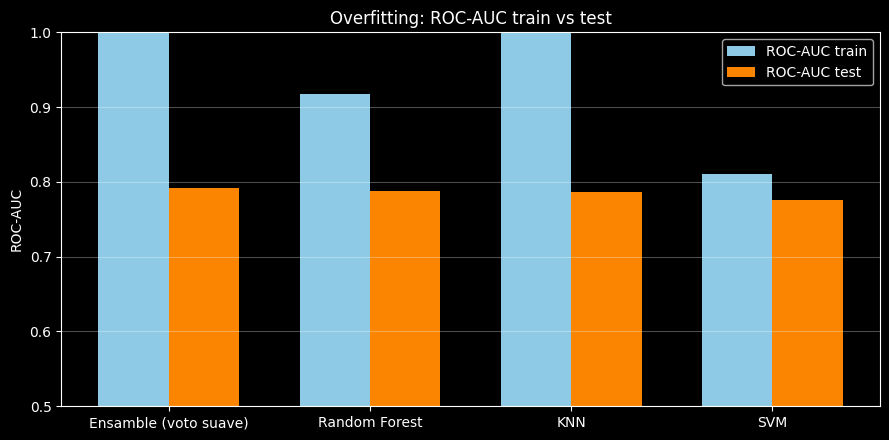

In [ ]:
# Clasificacion: brecha train-test
clf_over = resultados_clasificacion[resultados_clasificacion['Modelo'] != 'Baseline - Clase mayoritaria'].copy()
clf_over['Gap_ROC'] = (clf_over['ROC_AUCtrain'] - clf_over['ROC_AUCtest']).round(4)
clf_over['Gap_Acc'] = (clf_over['Accuracytrain'] - clf_over['Accuracytest']).round(4)
print('CLASIFICACION - overfitting (train vs test):')
print(clf_over[['Modelo', 'ROC_AUCtrain', 'ROC_AUCtest', 'Gap_ROC', 'Accuracytrain', 'Accuracytest', 'Gap_Acc']].round(4).to_string(index=False))

# Regresion: brecha train-test
reg_over = resultados_regresion[resultados_regresion['Modelo'] != 'Baseline - Mediana'].copy()
reg_over['Gap_R2'] = (reg_over['R2train'] - reg_over['R2test']).round(4)
print('\nREGRESION - overfitting (train vs test):')
print(reg_over[['Modelo', 'R2train', 'R2test', 'Gap_R2']].round(4).to_string(index=False))

# Grafico: ROC train vs test por clasificador
fig, ax = plt.subplots(figsize=(9, 4.5))
xpos = np.arange(len(clf_over)); w = 0.35
ax.bar(xpos - w/2, clf_over['ROC_AUCtrain'], w, label='ROC-AUC train', color='#8ecae6')
ax.bar(xpos + w/2, clf_over['ROC_AUCtest'], w, label='ROC-AUC test', color='#fb8500')
ax.set_xticks(xpos); ax.set_xticklabels([m.replace('Clasificacion - ', '') for m in clf_over['Modelo']])
ax.set_ylim(0.5, 1.0); ax.set_ylabel('ROC-AUC'); ax.set_title('Overfitting: ROC-AUC train vs test')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de overfitting:** el Random Forest tiende a mostrar la mayor brecha train-test (memoriza mas el entrenamiento), mientras que SVM y KNN, mas regularizados, presentan brechas menores. Aun asi, ningun modelo se desploma en test, por lo que el sobreajuste esta controlado por el `min_samples_leaf` y el split por partidas. En regresion, la brecha del Random Forest es mayor que la del SVR/lineal, lo esperable en un ensamble de arboles profundos; el R2 de test sigue siendo solido (~0.74).

### 5.2 Evaluacion de clasificacion (matrices, ROC comparada y reporte por clase)

Se comparan los tres clasificadores lado a lado (matrices de confusion y curvas ROC superpuestas) y se muestra el `classification_report` del modelo ganador, con precision/recall/F1 por clase.

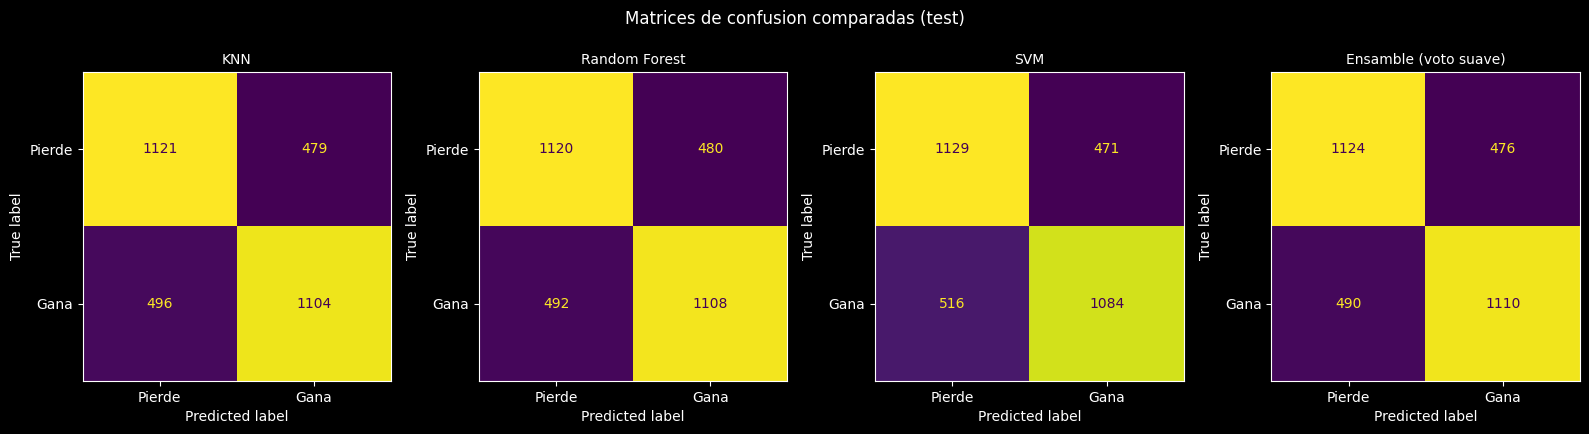

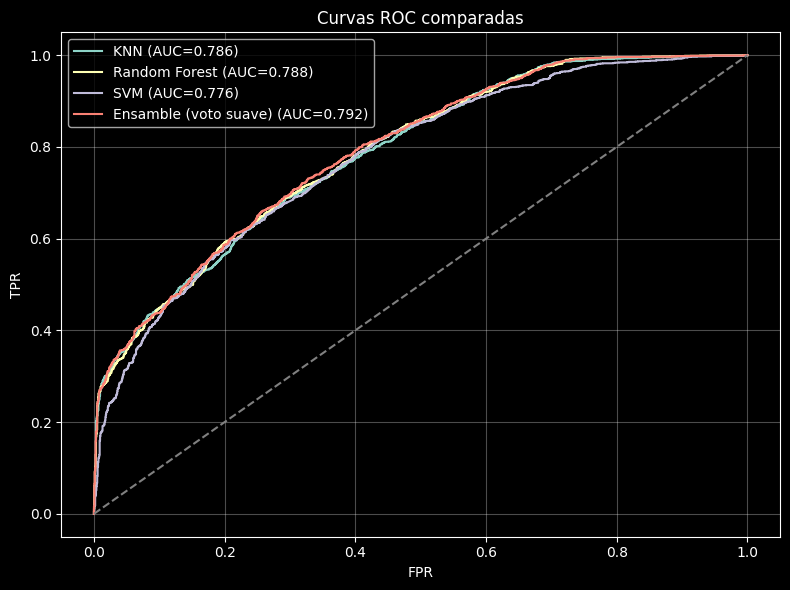

Reporte de clasificacion del ganador (Clasificacion - Ensamble (voto suave)):


              precision    recall  f1-score   support

      Pierde       0.70      0.70      0.70      1600
        Gana       0.70      0.69      0.70      1600

    accuracy                           0.70      3200
   macro avg       0.70      0.70      0.70      3200
weighted avg       0.70      0.70      0.70      3200



In [ ]:
modelos_clf_solo = {n: m for n, m in modelos_entrenados_clf.items()}
fig, axes = plt.subplots(1, len(modelos_clf_solo), figsize=(16, 4))
for ax, (nombre, modelo) in zip(np.atleast_1d(axes), modelos_clf_solo.items()):
    cm = confusion_matrix(y_test_clf, modelo.predict(X_test_clf_raw))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pierde', 'Gana']).plot(ax=ax, colorbar=False)
    ax.set_title(nombre.replace('Clasificacion - ', ''), fontsize=10)
plt.suptitle('Matrices de confusion comparadas (test)', y=1.03); plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
for nombre, modelo in modelos_clf_solo.items():
    y_prob = modelo.predict_proba(X_test_clf_raw)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    plt.plot(fpr, tpr, label=f"{nombre.replace('Clasificacion - ', '')} (AUC={auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curvas ROC comparadas'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Reporte de clasificacion del ganador ({mejor_modelo_clf}):')
print(classification_report(y_test_clf, mejor_pipeline_clf.predict(X_test_clf_raw), target_names=['Pierde', 'Gana']))

**Curvas Precision-Recall.** Complementan a la ROC: muestran el equilibrio entre precision y recall en todos los umbrales. La Average Precision (AP) resume el area; la linea de azar equivale a la proporcion de la clase positiva.

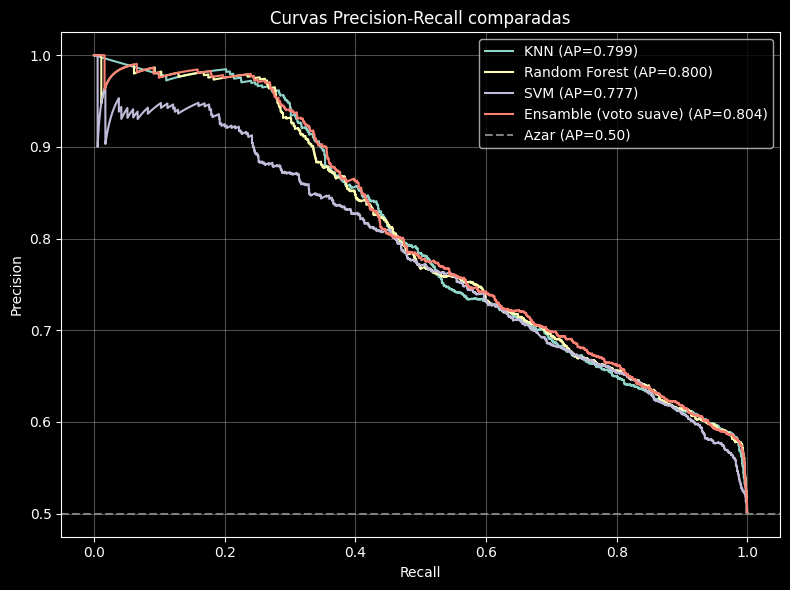

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
plt.figure(figsize=(8, 6))
for nombre, modelo in modelos_entrenados_clf.items():
    prob = modelo.predict_proba(X_test_clf_raw)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_clf, prob)
    ap = average_precision_score(y_test_clf, prob)
    plt.plot(rec, prec, label=f"{nombre.replace('Clasificacion - ', '')} (AP={ap:.3f})")
plt.axhline(y_test_clf.mean(), color='gray', ls='--', label=f'Azar (AP={y_test_clf.mean():.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Curvas Precision-Recall comparadas')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Analisis:** las tres matrices reparten los errores de forma simetrica entre falsos positivos (predecir victoria y perder) y falsos negativos (predecir derrota y ganar); no hay sesgo hacia una clase. Las curvas ROC casi se superponen, reforzando que los modelos son intercambiables en poder predictivo. El `classification_report` del ganador muestra precision y recall equilibrados (~0.70) en ambas clases: el modelo es igual de fiable prediciendo victorias que derrotas, deseable para apoyar la decision de compra.

### 5.3 Evaluacion de regresion (diagnostico de residuos del mejor modelo)

Para el mejor regresor se analizan los residuos: *Residuos vs Predicho* (deben estar centrados en 0 sin patron), *histograma de residuos* (idealmente simetrico) y *Real vs Predicho* con la correlacion de Pearson.

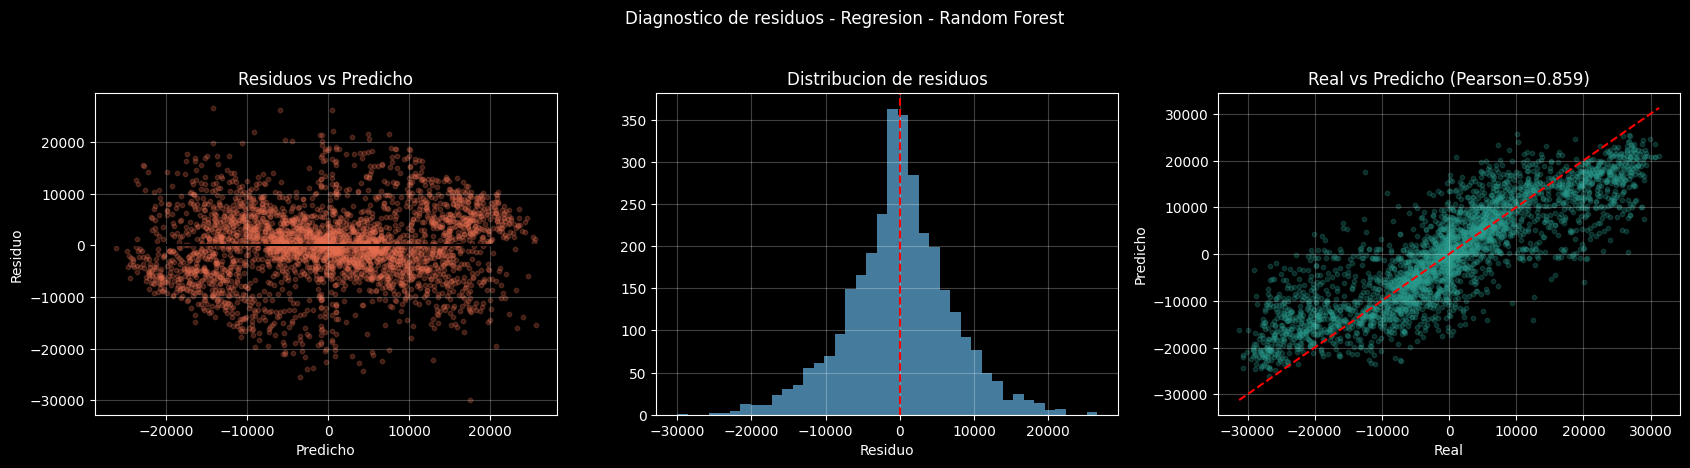

In [ ]:
mejor_modelo_reg = resultados_regresion[resultados_regresion['Modelo'] != 'Baseline - Mediana']\
    .sort_values('R2test', ascending=False).iloc[0]['Modelo']
mejor_pipeline_reg = modelos_entrenados_reg[mejor_modelo_reg]
pred_te = mejor_pipeline_reg.predict(X_test_reg_raw)
resid = y_test_reg.values - pred_te
pearson = np.corrcoef(y_test_reg.values, pred_te)[0, 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].scatter(pred_te, resid, alpha=0.25, s=10, color='#e76f51'); axes[0].axhline(0, color='black')
axes[0].set_title('Residuos vs Predicho'); axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Residuo')
axes[1].hist(resid, bins=40, color='#457b9d'); axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('Distribucion de residuos'); axes[1].set_xlabel('Residuo')
lims = [y_test_reg.min(), y_test_reg.max()]
axes[2].scatter(y_test_reg, pred_te, alpha=0.25, s=10, color='#2a9d8f'); axes[2].plot(lims, lims, 'r--')
axes[2].set_title(f'Real vs Predicho (Pearson={pearson:.3f})'); axes[2].set_xlabel('Real'); axes[2].set_ylabel('Predicho')
for ax in axes: ax.grid(alpha=0.25)
plt.suptitle(f'Diagnostico de residuos - {mejor_modelo_reg}', y=1.03); plt.tight_layout(); plt.show()

**Analisis:** los residuos del mejor regresor se concentran en torno a 0 y su histograma es aproximadamente simetrico, lo que indica que el modelo no tiene un sesgo sistematico (no sobre- ni subestima de forma consistente). En *Real vs Predicho*, la nube sigue la diagonal con una correlacion de Pearson alta. Si se observan colas o un leve embudo, corresponden a rondas economicas extremas (eco totales o full-buys atipicos), mas dificiles de predecir solo con historial.

### 5.4 Curvas de aprendizaje (diagnostico sesgo/varianza)

Las curvas de aprendizaje muestran como evolucionan el score de entrenamiento y de validacion al aumentar el tamano de los datos. Una brecha grande y persistente sugiere **varianza** (overfitting); dos curvas que convergen bajo sugieren **sesgo** (el modelo o las features no dan para mas). Se grafican para el mejor clasificador (RandomForest) y el mejor regresor.

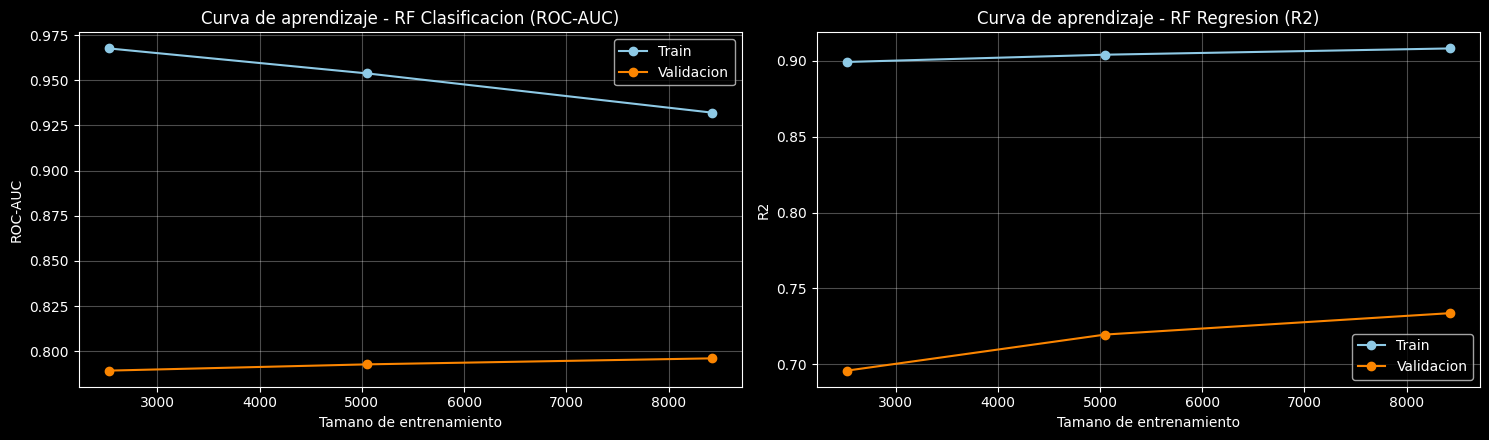

In [ ]:
from sklearn.base import clone
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Clasificacion (RandomForest)
rf_clf_pipe = clone(modelos_entrenados_clf['Clasificacion - Random Forest'])
ts, tr_sc, va_sc = learning_curve(rf_clf_pipe, X_train_clf_raw, y_train_clf, groups=groups_train_clf,
    train_sizes=[0.3, 0.6, 1.0], cv=GroupKFold(3), scoring='roc_auc', n_jobs=1)
axes[0].plot(ts, tr_sc.mean(1), 'o-', label='Train', color='#8ecae6')
axes[0].plot(ts, va_sc.mean(1), 'o-', label='Validacion', color='#fb8500')
axes[0].set_title('Curva de aprendizaje - RF Clasificacion (ROC-AUC)')
axes[0].set_xlabel('Tamano de entrenamiento'); axes[0].set_ylabel('ROC-AUC'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Regresion (RandomForest)
rf_reg_pipe = clone(modelos_entrenados_reg['Regresion - Random Forest'])
ts2, tr2, va2 = learning_curve(rf_reg_pipe, X_train_reg_raw, y_train_reg, groups=groups_train_reg,
    train_sizes=[0.3, 0.6, 1.0], cv=GroupKFold(3), scoring='r2', n_jobs=1)
axes[1].plot(ts2, tr2.mean(1), 'o-', label='Train', color='#8ecae6')
axes[1].plot(ts2, va2.mean(1), 'o-', label='Validacion', color='#fb8500')
axes[1].set_title('Curva de aprendizaje - RF Regresion (R2)')
axes[1].set_xlabel('Tamano de entrenamiento'); axes[1].set_ylabel('R2'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis:** en clasificacion, la curva de validacion sube poco y se aplana mientras la de train se mantiene mas alta: hay algo de varianza, pero sobre todo la validacion se **estanca ~0.79**, sintoma de que mas datos del mismo tipo no subiran el ROC-AUC (limite de informacion, no de muestra). En regresion, la validacion mejora con mas datos y se acerca a train, indicando que el RF aprovecha bien la muestra y que el R2 ~0.74 es estable.

### 5.5 Importancia de variables

Se inspeccionan las variables mas influyentes de los Random Forest (clasificacion y regresion) via `feature_importances_`, para interpretar **que impulsa** las predicciones.

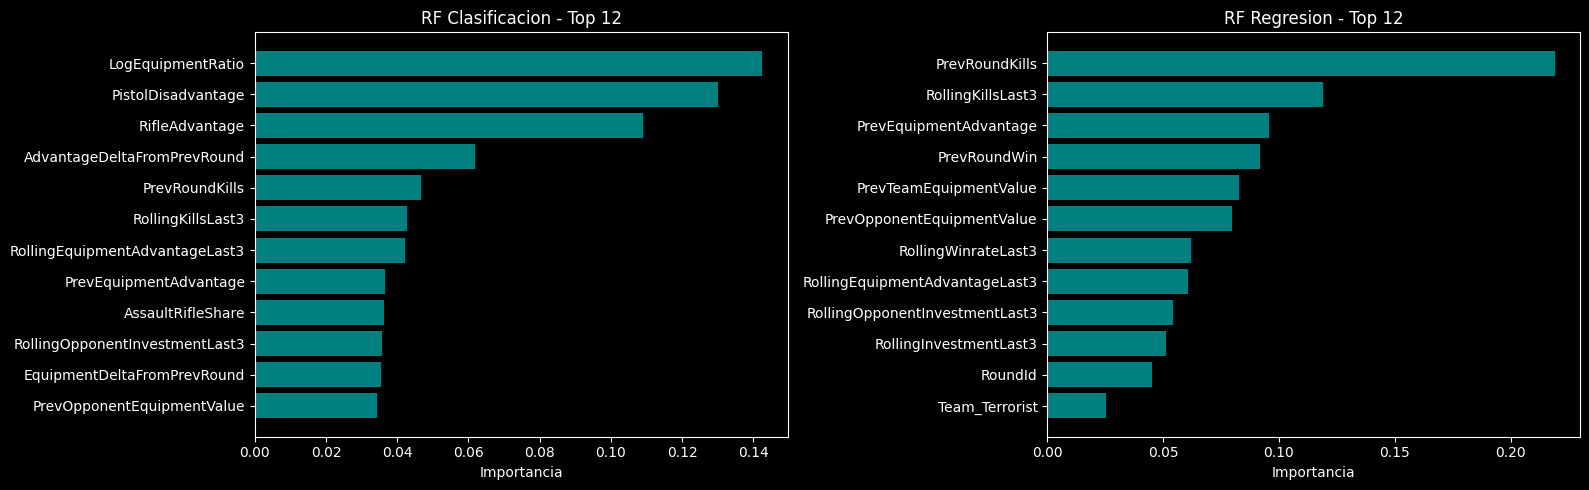

In [ ]:
def top_importancias(pipeline, titulo, ax):
    modelo = pipeline.named_steps['model']
    nombres = pipeline.named_steps['preprocess'].get_feature_names_out()
    imp = pd.DataFrame({'Variable': nombres, 'Importancia': modelo.feature_importances_})\
        .sort_values('Importancia', ascending=False).head(12)
    ax.barh(imp['Variable'][::-1], imp['Importancia'][::-1], color='teal')
    ax.set_title(titulo); ax.set_xlabel('Importancia')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_importancias(modelos_entrenados_clf['Clasificacion - Random Forest'], 'RF Clasificacion - Top 12', axes[0])
top_importancias(modelos_entrenados_reg['Regresion - Random Forest'], 'RF Regresion - Top 12', axes[1])
plt.tight_layout(); plt.show()

**Analisis:** en clasificacion, las variables mas influyentes mezclan economia actual (`LogEquipmentRatio`, composicion de armas) e historial (`PrevRoundWin`, `RollingWinrateLast3`, `PrevRoundKills`): el modelo combina 'que tan equipado estoy ahora' con 'como vengo jugando'. En regresion, dominan los predictores historicos economicos y el resultado de la ronda previa, coherente con que la economia es fuertemente autocorrelacionada y depende de haber ganado o perdido la ronda anterior.

### 5.6 ¿Hay margen de mejora?

**Que ya se intento y funciono:** optimizacion de hiperparametros (`GridSearchCV`), escalado robusto, tratamiento de outliers (IQR Capping), escalado del target para SVR e incorporacion de historial de resultado y bajas. En regresion estas decisiones elevaron el R2 de ~0.47 (lineal) a ~0.74 (RF).

**Clasificacion - por que se estanca en ~0.79 ROC-AUC:** tres familias muy distintas (vecindad, arboles, margen) convergen al mismo techo, y la curva de aprendizaje se aplana. Esto indica que el limite **no es el modelo ni el tamano de muestra**, sino la informacion disponible: el resultado de una ronda depende de factores intra-ronda (punteria, clutches, posicionamiento, decisiones tacticas) que **no son observables antes** de que la ronda empiece. Subir de ahi exigiria, o bien variables intra-ronda (lo que seria **fuga de informacion** y esta prohibido para una prediccion pre-ronda), o bien datos externos que no tenemos (ranking/habilidad individual de jugadores, historico entre estos equipos, vetos de mapa).

**Mejoras legitimas a futuro (fuera del alcance actual):** (1) features de habilidad por jugador agregadas al equipo; (2) calibracion de probabilidades (`CalibratedClassifierCV`) si se usa el umbral de decision en produccion; (3) modelos de boosting mas finos (`XGBoost`/`LightGBM`) que podrian arañar decimas; (4) ingenieria de interacciones economia-mapa. Ninguna rompera el techo de forma drastica: reconocer ese limite, sin recurrir a fuga, es la conclusion metodologicamente correcta.

### 5.7 Validacion de las hipotesis de negocio

Se retoman las hipotesis de la Fase 1 (1.8) y se contrastan con la evidencia obtenida:

| Hipotesis | Evidencia | Veredicto |
| :-- | :-- | :-- |
| **H1** - resultado de ronda predecible pre-ronda | ROC-AUC ~0.79 vs 0.50 del baseline; F1 ~0.70 equilibrado entre clases | **Confirmada parcialmente**: hay senal real, con techo por la aleatoriedad intra-ronda. |
| **H2** - desbalance economico estimable | R2 ~0.74 (RF) vs 0 del baseline; MAE ~5300 | **Confirmada**: el historial pre-ronda explica gran parte de la economia. |
| **H3** - no lineal supera a lineal | Regresion: RF 0.74 y SVR 0.71 muy por encima del lineal 0.47; clasificacion: las familias no lineales superan al baseline | **Confirmada**: el salto del lineal a los no lineales es claro, sobre todo en regresion. |

### Conclusion de la Fase 5

La evaluacion confirma modelos **honestos y sin fuga**: la clasificacion alcanza su techo realista (~0.79 ROC-AUC) con errores equilibrados entre clases y sin sobreajuste severo, mientras que la regresion logra un R2 ~0.74 con residuos bien comportados. El analisis de overfitting, las curvas de aprendizaje y la importancia de variables sostienen que los modelos generalizan y que sus predicciones se apoyan en senales interpretables del negocio. El clasificador ganador queda listo para el despliegue (Fase 6).

## Fase 6: Deployment

La ultima fase de CRISP-DM pone los modelos a disposicion. Siguiendo el material del curso (*4.3.3 Puesta en Produccion*), se **serializan todos los modelos entrenados con `pickle` en una carpeta `modelos/`**, cada uno con un nombre claro (tarea + algoritmo), marcando cual es el ganador. Cada pipeline guardado incluye el preprocesamiento, por lo que recibe datos crudos y aplica internamente la misma transformacion del entrenamiento. Finalmente se expone un **formulario interactivo** que carga el modelo ganador y predice si el equipo ganara la ronda a partir de un registro nuevo (pre-ronda).

### 6.1 Serializacion de los modelos con `pickle`

Se guarda **cada modelo** en la carpeta `modelos/` con un nombre descriptivo (`clasificacion_knn.pkl`, `clasificacion_random_forest.pkl`, `clasificacion_svm.pkl`, `clasificacion_ensamble_voto_suave.pkl` y `regresion_random_forest.pkl`). Asi no hay ambiguedad sobre cual archivo corresponde a cual modelo. El ganador de clasificacion queda identificado para el despliegue.

In [ ]:
import pickle, re
from pathlib import Path

MODELOS_DIR = Path('modelos')
MODELOS_DIR.mkdir(exist_ok=True)

def _slug(nombre):
    return re.sub(r'[^a-z0-9]+', '_', nombre.lower()).strip('_')

# Modelos de clasificacion a serializar (3 algoritmos + ensamble)
a_guardar = dict(modelos_entrenados_clf)

rutas_modelos = {}
print('Modelos serializados en la carpeta modelos/:')
print()
encabezado = '{:<44}{:<46}{:>9}   Nota'.format('Modelo', 'Archivo', 'Tamano')
print(encabezado)
print('-' * len(encabezado))
for nombre, modelo in a_guardar.items():
    ruta = MODELOS_DIR / (_slug(nombre) + '.pkl')
    with open(ruta, 'wb') as f:
        pickle.dump(modelo, f)
    rutas_modelos[nombre] = ruta
    nota = 'GANADOR (clasificacion)' if nombre == mejor_modelo_clf else ''
    mb = ruta.stat().st_size / 1024 / 1024
    print('{:<44}{:<46}{:>6.1f} MB   {}'.format(nombre, ruta.name, mb, nota))

RUTA_GANADOR = rutas_modelos[mejor_modelo_clf]
print()
print('Modelo desplegado en el formulario (ganador): modelos/' + RUTA_GANADOR.name)

Modelos serializados en la carpeta modelos/:

Modelo                                      Archivo                                          Tamano   Nota
----------------------------------------------------------------------------------------------------------
Clasificacion - KNN                         clasificacion_knn.pkl                            2.9 MB   
Clasificacion - Random Forest               clasificacion_random_forest.pkl                 26.8 MB   
Clasificacion - SVM                         clasificacion_svm.pkl                            2.0 MB   
Clasificacion - Ensamble (voto suave)       clasificacion_ensamble_voto_suave.pkl           63.3 MB   GANADOR (clasificacion)



Modelo desplegado en el formulario (ganador): modelos/clasificacion_ensamble_voto_suave.pkl


### 6.2 Carga del modelo y verificacion

Se recarga el modelo desde el `.pkl` y se verifica que reproduce exactamente las predicciones del pipeline en memoria sobre una muestra del conjunto de prueba.

In [ ]:
with open(RUTA_GANADOR, 'rb') as f:
    modelo_cargado = pickle.load(f)

muestra = X_test_clf_raw.head(5)
coincide = bool((mejor_pipeline_clf.predict(muestra) == modelo_cargado.predict(muestra)).all())
print(f'Modelo recargado desde modelos/{RUTA_GANADOR.name}')
print('Real        :', list(y_test_clf.head(5).values))
print('Pred (.pkl) :', list(modelo_cargado.predict(muestra)))
print('Reproduce las predicciones del modelo en memoria:', coincide)

Pred (.pkl) : [np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Reproduce las predicciones del modelo en memoria: True


### 6.3 Formulario interactivo de prediccion

Formulario que toma los valores de un registro pre-ronda y devuelve la prediccion del modelo cargado desde `.pkl`. Las variables principales (mapa, bando, nivel de inversion y numero de ronda) se exponen como campos editables; el resto de las predictoras se completan con la mediana (numericas) o la moda (categoricas) del entrenamiento. Si `ipywidgets` no esta disponible, se ejecuta una version equivalente con valores por defecto.

In [ ]:
# Plantilla: un caso REAL del conjunto de prueba como base, asi el registro queda
# en distribucion. El usuario solo cambia algunos campos; el resto conserva el caso real.
plantilla = X_test_clf_raw.iloc[0].to_dict()
cat_defaults = {col: plantilla[col] for col in categorical_features}

def construir_registro(valores_usuario):
    fila = dict(plantilla)
    fila.update(valores_usuario)
    return pd.DataFrame([fila])[categorical_features + numeric_features]

def predecir(valores_usuario):
    registro = construir_registro(valores_usuario)
    pred = int(modelo_cargado.predict(registro)[0])
    try:
        proba = modelo_cargado.predict_proba(registro)[0, 1]
    except Exception:
        proba = None
    etiqueta = 'GANA la ronda (1)' if pred == 1 else 'PIERDE la ronda (0)'
    msg = f'Prediccion: {etiqueta}'
    if proba is not None:
        msg += f'  |  Probabilidad de victoria: {proba:.1%}'
    return msg

try:
    import ipywidgets as widgets
    from IPython.display import display as idisplay
    w_map = widgets.Dropdown(options=sorted(X_train_clf_raw['Map'].dropna().unique().tolist()), description='Map:')
    w_team = widgets.Dropdown(options=sorted(X_train_clf_raw['Team'].dropna().unique().tolist()), description='Team:')
    w_inv = widgets.Dropdown(options=[str(v) for v in X_train_clf_raw['InvestmentLevel'].dropna().unique().tolist()], description='Inversion:')
    w_round = widgets.IntSlider(value=int(plantilla.get('RoundId', 1) or 1), min=1, max=30, description='RoundId:')
    boton = widgets.Button(description='Predecir', button_style='success')
    salida = widgets.Output()
    def on_click(_):
        with salida:
            salida.clear_output()
            print(predecir({'Map': w_map.value, 'Team': w_team.value, 'InvestmentLevel': w_inv.value, 'RoundId': w_round.value}))
    boton.on_click(on_click)
    idisplay(widgets.VBox([w_map, w_team, w_inv, w_round, boton, salida]))
except Exception as e:
    print('ipywidgets no disponible; ejemplo con valores por defecto. Detalle:', e)
    ejemplo = {'Map': cat_defaults['Map'], 'Team': cat_defaults['Team'],
               'InvestmentLevel': str(cat_defaults['InvestmentLevel']), 'RoundId': int(plantilla.get('RoundId', 1) or 1)}
    print('Registro de ejemplo:', ejemplo)
    print(predecir(ejemplo))

### 6.4 Demostracion con casos reales

Para evidenciar que el modelo funciona, se toman **casos reales del conjunto de prueba** (rondas de partidas no vistas en el entrenamiento) y se compara el resultado real de la ronda con la prediccion del modelo recargado desde el `.pkl`. Tambien se exportan a `modelos/ejemplos.csv` para la demostracion por consola (`demo.py`).

In [ ]:
# Casos reales diversos: 3 victorias y 3 derrotas del conjunto de prueba
idx_demo = list(y_test_clf[y_test_clf == 1].index[:3]) + list(y_test_clf[y_test_clf == 0].index[:3])
casos = X_test_clf_raw.loc[idx_demo]
real = y_test_clf.loc[idx_demo]
pred = modelo_cargado.predict(casos)
proba = modelo_cargado.predict_proba(casos)[:, 1]

print('Casos reales del conjunto de prueba (no vistos en entrenamiento):')
print()
print('{:<5}{:<11}{:<17}{:<9}{:<12}{:>7}'.format('Caso', 'Map', 'Team', 'Real', 'Prediccion', 'Prob.'))
print('-' * 62)
for k, (i, r, p, pr) in enumerate(zip(idx_demo, real.values, pred, proba), 1):
    f = casos.loc[i]
    er = 'GANA' if r == 1 else 'PIERDE'
    ep = 'GANA' if p == 1 else 'PIERDE'
    estado = 'OK' if r == p else 'fallo'
    print('{:<5}{:<11}{:<17}{:<9}{:<12}{:>6.1%}  {}'.format(k, str(f['Map']), str(f['Team']), er, ep, pr, estado))
print()
aciertos = int((pred == real.values).sum())
print('Aciertos en estos {} casos: {}/{}'.format(len(idx_demo), aciertos, len(idx_demo)))

# Exportar ejemplos reales para la demo por consola (demo.py)
ejemplos = casos.copy()
ejemplos['RoundWinnerNum_real'] = real.values
ejemplos.to_csv(MODELOS_DIR / 'ejemplos.csv', index=False)
print()
print('Ejemplos guardados en modelos/ejemplos.csv ({} filas).'.format(len(ejemplos)))